<!-- Contenedor -->
<div style="max-width:1100px; margin:0 auto;">

  <!-- Dos columnas: izquierda (imágenes), derecha (texto) -->
  <div style="display:flex; align-items:flex-start; gap:1.25rem; margin:1rem 0; flex-wrap:wrap;">
    <!-- Columna izquierda: dos imágenes, mismo ancho, pegadas -->
    <div style="width:20%; min-width:240px; line-height:0;">
      <!-- Imagen 1 -->
      <img
        src="https://cdn.prod.website-files.com/617960145ff34f911afe7243/66f59b40faae94506a4cc751_66f59b0f18152ddb1f3228ab_Automated%2520Trading.jpeg"
        alt="Imagen 1"
        style="width:100%; display:block; margin:0; border:0;" />
      <!-- Imagen 2 con fondo blanco (sin separación) -->
      <div style="background:#fff; margin:0;">
        <img
          src="https://www.ehu.eus/documents/51299803/52066233/Logo-UPV-EHU.png/ce57c7e3-c62b-3b9f-d1a6-395d384f6c2b?t=1710766509885"
          alt="Imagen 2"
          style="width:100%; display:block; margin:0; border:0;" />
      </div>
    </div> 
    <!-- Columna derecha: texto alineado en el mismo margen -->
    <div style="flex:1; min-width:300px; text-align:left;">
      <div style="margin:0; font-size:1.45rem; font-weight:700; line-height:1.15;">
        TRABAJO FINAL DE MÁSTER
      </div>
      <div style="margin:0.65rem 0 0 0; font-size:1.30rem; font-weight:600; line-height:1.2; opacity:0.95;">
        Máster en Finanzas y Dirección Financiera
      </div>
      <div style="margin:1.8rem 0 0 0; font-size:1.10rem; font-weight:600; line-height:1.35;">
        Bots de trading inteligentes: estrategias adaptativas impulsadas por <em>machine learning</em> para la optimización de carteras en renta variable, divisas y criptoactivos
      </div>
      <div style="margin-top:1.8rem; font-size:1rem;">
        <p style="margin:0.2rem 0;"><strong>Autor:</strong> Karen Fajardo</p>
        <p style="margin:0.2rem 0;"><strong>Tutor:</strong> PhD. Vicente Ruiz</p>
      </div>
    </div>

  </div>

  <hr style="margin:1.25rem 0;" />
</div>



### Tabla de contenidos
1. [Entorno y dependencias](#1-entorno-y-dependencias)  
2. [Perfil del inversor & IPS](#2-perfil-del-inversor--ips)  
3. [Universo de activos & datos](#3-universo-de-activos--datos)  
4. [Features & Scoring ML](#4-features--scoring-ml)  
5. [Construcción de cartera (medio plazo)](#5-construcción-de-cartera-medio-plazo)  
6. [Validación walk-forward & métricas](#6-validación-walk-forward--métricas)  
7. [Paper trading multi-activo](#7-paper-trading-multi-activo)  
8. [Selección para intradía](#8-selección-para-intradia)  
9. [Resultados, conclusiones y limitaciones](#9-resultados-conclusiones-y-limitaciones)  
10. [Reproducibilidad](#10-reproducibilidad)  


---

### 1. [Entorno y dependencias](#1-entorno-y-dependencias)
Para garantizar la **reproducibilidad** y un flujo de trabajo ordenado, se configuró un entorno virtual en **Python 3.11** con todas las librerías necesarias fijadas en un `requirements.txt`.

- **Entorno virtual (`.venv`)**: aísla las dependencias del proyecto y evita conflictos con otras instalaciones de Python.  
- **Archivo `.env`**: centraliza variables sensibles y de configuración (ej. semillas aleatorias, rutas de datos, claves API).  
- **Semillas globales**: aseguran resultados consistentes en pruebas y entrenamientos de modelos.  
- **Rutas (`settings.py`)**: se definen directorios estándar para `data/`, `models/`, `logs/` y `reports/`, evitando rutas “hardcodeadas”.  
- **Bootstrap**: función que inicializa el proyecto cargando el `.env`, aplicando zona horaria, fijando semillas y creando carpetas.  

Esto permite que cualquier usuario pueda **replicar el entorno** simplemente creando el entorno virtual e instalando dependencias desde `requirements.txt`.
Ademas, se implementó un flujo de trabajo basado en **Git** para gestionar cambios y mantener el historial del proyecto de forma estructurada y con un esquema que permite que cualquier colaborador pueda clonar el proyecto, instalar las dependencias y reproducir el entorno de forma consistente.

In [1]:
# Añadir la RAÍZ del proyecto al sys.path para que 'settings' sea importable
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "settings.py").exists() and (p / "config").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (settings.py + config/)")

PROJECT_ROOT = find_project_root(Path.cwd())

# 1) Raíz del repo (para importar 'settings')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 2) src/ (para importar 'tfm')
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# print("PROJECT_ROOT:", PROJECT_ROOT)
# print("SRC_DIR:", SRC_DIR)


In [4]:
import numpy as np
from tfm.bootstrap import bootstrap

seed_used = bootstrap()  
print(f"Entorno inicializado. Seed efectiva: {seed_used}")

# Comprobamos que settings se ve correctamente
import importlib, os
settings = importlib.import_module("settings")
print("TZ:", os.environ.get("TZ"))
#print("DATA_DIR:", getattr(settings, "DATA_DIR", None))
#print("MODELS_DIR:", getattr(settings, "MODELS_DIR", None))
#print("LOGS_DIR:", getattr(settings, "LOGS_DIR", None))



Entorno inicializado. Seed efectiva: 42
TZ: Europe/Madrid


### 2. [Perfil del inversor & IPS](#2-perfil-del-inversor--ips) 

In [3]:
import yaml, math
from pathlib import Path
import pandas as pd



def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "settings.py").exists() and (p / "config").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (settings.py + config/).")

try:
    PROJECT_ROOT  # ya definido
except NameError:
    PROJECT_ROOT = find_project_root(Path.cwd())

IPS_PATH = PROJECT_ROOT / "config" / "ips.yaml"
print("IPS_PATH:", IPS_PATH)

required = ["investor_profile","objectives","risk_metrics","restrictions","universes","rebalancing"]
raw = yaml.safe_load(IPS_PATH.read_text(encoding="utf-8"))
missing = [k for k in required if k not in raw]
assert not missing, f"Faltan claves en ips.yaml: {missing}"

r = raw["restrictions"]
assert 0 <= r["min_cash"] <= r["max_cash"] <= 1.0, "Rango de caja inválido."
vol = raw["risk_metrics"]
assert vol["target_volatility"] < vol["max_volatility"], "target_volatility debe ser < max_volatility."

# Resúmenes auditables
perfil = pd.Series(raw["investor_profile"], name="Perfil del inversor").to_frame()
objet  = pd.Series(raw["objectives"],       name="Objetivos").to_frame()
riesgo = pd.Series(raw["risk_metrics"],     name="Métricas de riesgo").to_frame()
techos = pd.Series(raw["restrictions"].get("max_asset_class_weight", {}), name="Techos por clase").to_frame()

display(perfil, objet, riesgo, techos)
raw


IPS_PATH: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\config\ips.yaml


,Perfil del inversor
type,dynamic
risk_tolerance,high
horizon,medium_term
currency,EUR


,Objetivos
target_return,0.12
sharpe_min,1.00


,Métricas de riesgo
target_volatility,0.12
max_volatility,0.18
max_drawdown,0.20


,Techos por clase
equities,0.60
forex,0.25
crypto,0.05


{'investor_profile': {'type': 'dynamic',
  'risk_tolerance': 'high',
  'horizon': 'medium_term',
  'currency': 'EUR'},
 'objectives': {'target_return': 0.12, 'sharpe_min': 1.0},
 'risk_metrics': {'target_volatility': 0.12,
  'max_volatility': 0.18,
  'max_drawdown': 0.2},
 'restrictions': {'max_asset_weight': 0.2,
  'leverage': False,
  'min_cash': 0.05,
  'max_cash': 0.1,
  'cap_mode': 'budgeted',
  'max_asset_class_weight': {'equities': 0.6, 'forex': 0.25, 'crypto': 0.05},
  'max_position_value_eur': 50000},
 'universes': {'equities': True, 'forex': True, 'crypto': True},
 'rebalancing': {'frequency': 'monthly'}}

In [4]:
#Establecemos una formula de validación que asegura que la configuración del perfil del inversor en el YAML sea factible y consistente con las 
#restricciones de presupuesto y liquidez antes de que la optimización de cartera arranque. Esto se conecta con la literatura de risk budgeting 
#y portfolio constraints: un paso fundamental en la gestión cuantitativa es detectar y corregir configuraciones imposibles o que violan 
#restricciones lógicas, ya que de otro modo la optimización se rompe o produce resultados irreales

#Verificar las restricciones de cash , pesos asignados a los activos y se establecen mensajes de errores. 


def validate_ips_budgeted_with_cash(ips: dict):
    errors = []
    r = ips.get("restrictions", {})
    rm = ips.get("risk_metrics", {})

    # --- Riesgo ---
    tv = rm.get("target_volatility")
    mv = rm.get("max_volatility")
    if tv is None or mv is None:
        errors.append("Define 'risk_metrics.target_volatility' y 'risk_metrics.max_volatility'.")
    else:
        if tv < 0 or mv < 0:
            errors.append("Volatilidades deben ser no negativas.")
        if tv > mv:
            errors.append(f"target_volatility ({tv:.2%}) no puede superar max_volatility ({mv:.2%}).")

    # --- Cash ---
    min_cash = r.get("min_cash", 0.0)
    max_cash = r.get("max_cash", 0.0)
    if not (0 <= min_cash <= 1 and 0 <= max_cash <= 1):
        errors.append("min_cash y max_cash deben estar entre 0 y 1.")
    if min_cash > max_cash:
        errors.append(f"min_cash ({min_cash:.0%}) no puede ser mayor que max_cash ({max_cash:.0%}).")

    # --- Peso por activo ---
    maw = r.get("max_asset_weight")
    if maw is None or not (0 < maw <= 1):
        errors.append("max_asset_weight debe estar en (0,1].")

    # --- Cuotas por clase (budgeted y máximos) ---
    cap_mode = r.get("cap_mode", "independent")
    macw = r.get("max_asset_class_weight", {})
    if cap_mode != "budgeted":
        errors.append("cap_mode debe ser 'budgeted' para cuotas presupuestadas y máximos.")
    if not macw:
        errors.append("Define 'restrictions.max_asset_class_weight' para 'budgeted'.")
    else:
        # cuotas en [0,1]
        if any((w is None) or (w < 0) or (w > 1) for w in macw.values()):
            errors.append("Cada cuota en 'max_asset_class_weight' debe estar en [0,1].")

        total_quota = sum(macw.values())

        # Factibilidad con bandas de cash:
        # Debe cumplirse: 1 - max_cash <= sum(quota) <= 1 - min_cash
        lower = 1 - max_cash
        upper = 1 - min_cash
        if total_quota + 1e-9 < lower:
            errors.append(
                f"Suma de cuotas ({total_quota:.2%}) < 1 - max_cash ({lower:.2%}). "
                "Aumenta cuotas o reduce max_cash."
            )
        if total_quota - 1e-9 > upper:
            errors.append(
                f"Suma de cuotas ({total_quota:.2%}) > 1 - min_cash ({upper:.2%}). "
                "Reduce cuotas o disminuye min_cash."
            )

    if errors:
        raise ValueError("Errores en IPS:\n- " + "\n- ".join(errors))

    # Avisos útiles (no bloquean)
    total_quota = sum(macw.values())
    if abs(total_quota - (1 - min_cash)) < 1e-6:
        print("[Aviso] Suma de cuotas ≈ 1 - min_cash: la cartera tenderá a mantener el mínimo de cash.")
    if abs(total_quota - (1 - max_cash)) < 1e-6:
        print("[Aviso] Suma de cuotas ≈ 1 - max_cash: la cartera podría forzar el cash máximo con facilidad.")



### 3. [Universo de activos & datos](#3-universo-de-activos--datos)  
Definimos y validamos el universo de activos financieros a considerar en la optimización de cartera. 
Esto incluye la carga de datos históricos, la verificación de la integridad y calidad de los datos, y la categorización de los activos en clases (acciones, bonos, materias primas, etc.). 
Un universo bien definido es crucial para asegurar que la optimización de cartera se base en información precisa y relevante, 
permitiendo una mejor diversificación y alineación con los objetivos del inversor. 

In [5]:
import yfinance as yf 
import datetime as dt
from pathlib import Path
import yaml
import pyarrow as pa
import warnings
import missingno as msno
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [6]:
print("Descargando datos actualizados desde Yahoo Finance (OHLCV)")

years_of_data = 4
# 1. Fechas
START_DATE = (dt.date.today() - dt.timedelta(days=365*years_of_data)).strftime("%Y-%m-%d")
END_DATE = dt.date.today().strftime("%Y-%m-%d")

# 2. Cargar universo de tickers
universe_path = PROJECT_ROOT / "config" / "universe" / "universe_equities.yaml"
universe = yaml.safe_load(universe_path.read_text(encoding="utf-8"))
symbols_yf = [x["symbol_yf"] for x in universe["tickers"]]

print(f"Tickers totales a descargar: {len(symbols_yf)}")

# 3. Descarga completa OHLCV
raw = yf.download(
    tickers=symbols_yf,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    group_by="ticker",
    progress=False
)

# 4. Construir estructura final con todas las columnas por ticker
full_data = {}

for ticker in symbols_yf:
    try:
        df_t = raw[ticker][["Open", "High", "Low", "Close", "Adj Close", "Volume"]]
        full_data[ticker] = df_t
    except:
        print(f"[WARN] {ticker}: no descargado")

# 5. Crear un MultiIndex DataFrame: niveles → Fecha × (Ticker, Campo)
prices_df = pd.concat(full_data, axis=1)

print("Descarga completada. Dimensiones:", prices_df.shape)

prices_df.head()


Descargando datos actualizados desde Yahoo Finance (OHLCV)
Tickers totales a descargar: 98
Descarga completada. Dimensiones: (1045, 588)


BMNR                                        TSLA              \
Price      Open High Low Close Adj Close Volume        Open        High   
Date                                                                      
2021-11-16  NaN  NaN NaN   NaN       NaN    NaN  334.436676  352.399994   
2021-11-17  NaN  NaN NaN   NaN       NaN    NaN  354.503326  373.213318   
2021-11-18  NaN  NaN NaN   NaN       NaN    NaN  368.850006  370.666656   
2021-11-19  NaN  NaN NaN   NaN       NaN    NaN  366.290009  379.573334   
2021-11-22  NaN  NaN NaN   NaN       NaN    NaN  387.443329  400.649994   

                                    ...         TD                        \
Price              Low       Close  ...        Low      Close  Adj Close   
Date                                ...                                    
2021-11-16  334.059998  351.576660  ...  74.180000  74.190002  62.445057   
2021-11-17  351.833344  363.003326  ...  73.080002  73.379997  61.763287   
2021-11-18  358.339996  365.459991  ...  73.070000  73.220001  61.628624   
2021-11-19  364.233337  379.019989  ...  72.309998  72.629997  61.132027   
2021-11-22  377.476654  385.623322  ...  73.199997  73.220001  61.628624   

                               RY                                      \
Price          Volume        Open        High         Low       Close   
Date                                                                    
2021-11-16   862500.0  105.809998  105.940002  105.139999  105.559998   
2021-11-17  1040100.0  105.550003  105.690002  104.519997  104.790001   
2021-11-18   786400.0  104.790001  104.790001  104.099998  104.629997   
2021-11-19  1465400.0  104.010002  104.529999  103.320000  104.339996   
2021-11-22  1550500.0  104.510002  104.639999  103.610001  103.650002   

                                  
Price       Adj Close     Volume  
Date                              
2021-11-16  91.382423  1123300.0  
2021-11-17  90.715843   616900.0  
2021-11-18  90.577324  1166000.0  
2021-11-19  90.326279  1339700.0  
2021-11-22  89.728951  1938000.0  

[5 rows x 588 columns]

In [7]:
#Df inciial para futura validación de los resultados 
print("Guardado de respaldo (snapshot) de precios OHLCV.")

snapshot_dir = PROJECT_ROOT / "data" / "snapshots"
snapshot_dir.mkdir(parents=True, exist_ok=True)

snapshot_name = f"prices_OHLCV_{dt.date.today().strftime('%Y%m%d')}.csv.gz"
snapshot_path = snapshot_dir / snapshot_name

prices_df.to_csv(snapshot_path, compression="gzip")
print("Snapshot creado correctamente en:", snapshot_path)


Guardado de respaldo (snapshot) de precios OHLCV.
Snapshot creado correctamente en: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data\snapshots\prices_OHLCV_20251115.csv.gz


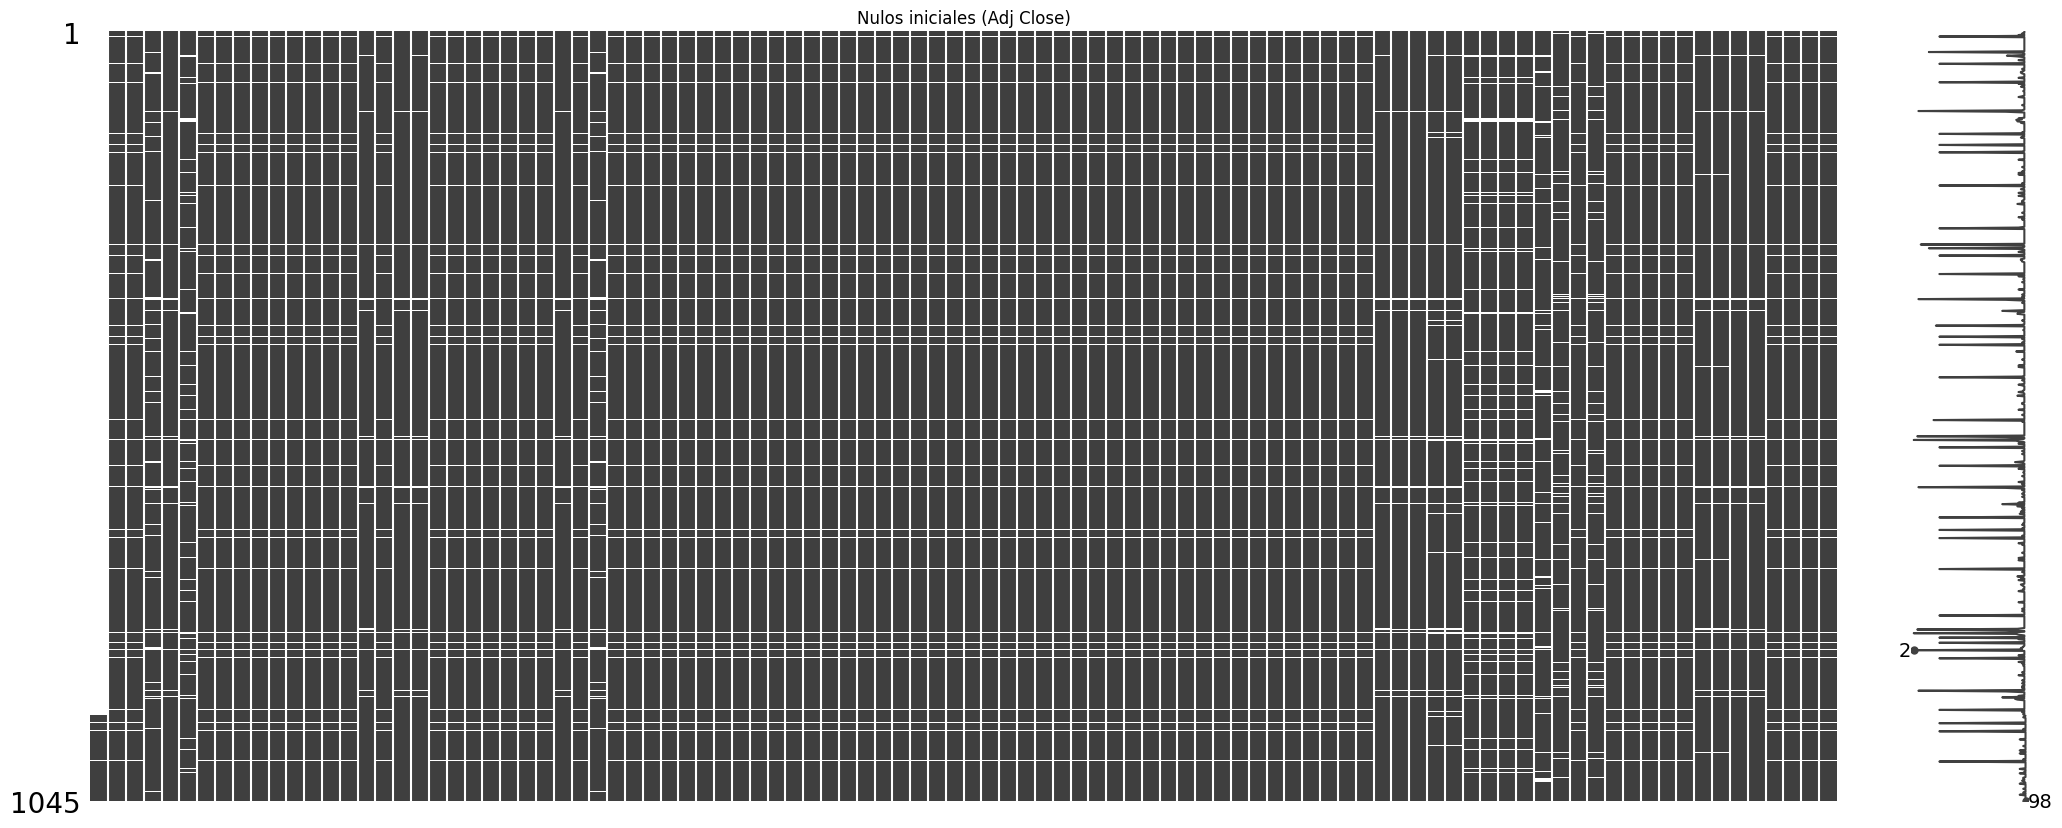

In [8]:
# Extraer OHLCV del MultiIndex
open_df   = prices_df.xs("Open", level=1, axis=1).copy()
high_df   = prices_df.xs("High", level=1, axis=1).copy()
low_df    = prices_df.xs("Low", level=1, axis=1).copy()
close_df  = prices_df.xs("Close", level=1, axis=1).copy()
adj_df    = prices_df.xs("Adj Close", level=1, axis=1).copy()
vol_df    = prices_df.xs("Volume", level=1, axis=1).copy()

# Podemos visualizar solo AdjClose (que resume bien los nulos)
msno.matrix(adj_df)
plt.title("Nulos iniciales (Adj Close)")
plt.show()

In [9]:
# Eliminar activos con >10% nulos en Adj Close 
porcentaje_nulos = adj_df.isna().mean()

tickers_ok = porcentaje_nulos[porcentaje_nulos < 0.10].index
tickers_bad = porcentaje_nulos[porcentaje_nulos >= 0.10].index

print("Activos eliminados (+10% nulos):")
print(list(tickers_bad))

# Filtrar en TODAS las tablas OHLCV
open_df   = open_df[tickers_ok]
high_df   = high_df[tickers_ok]
low_df    = low_df[tickers_ok]
close_df  = close_df[tickers_ok]
adj_df    = adj_df[tickers_ok]
vol_df    = vol_df[tickers_ok]


Activos eliminados (+10% nulos):
['BMNR']


In [10]:
# Unir todas las columnas para detectar días con NaN en cualquier activo o columna
full_matrix = pd.concat(
    [open_df, high_df, low_df, close_df, adj_df, vol_df],
    axis=1
)

# Fechas válidas (sin ningún NaN)
valid_rows = full_matrix.dropna(axis=0, how='any').index

# Aplicar el filtro
open_df   = open_df.loc[valid_rows]
high_df   = high_df.loc[valid_rows]
low_df    = low_df.loc[valid_rows]
close_df  = close_df.loc[valid_rows]
adj_df    = adj_df.loc[valid_rows]
vol_df    = vol_df.loc[valid_rows]

indices_p = adj_df.copy()
print("Después de limpieza total, dimensiones finales:", indices_p.shape)
  

Después de limpieza total, dimensiones finales: (811, 97)


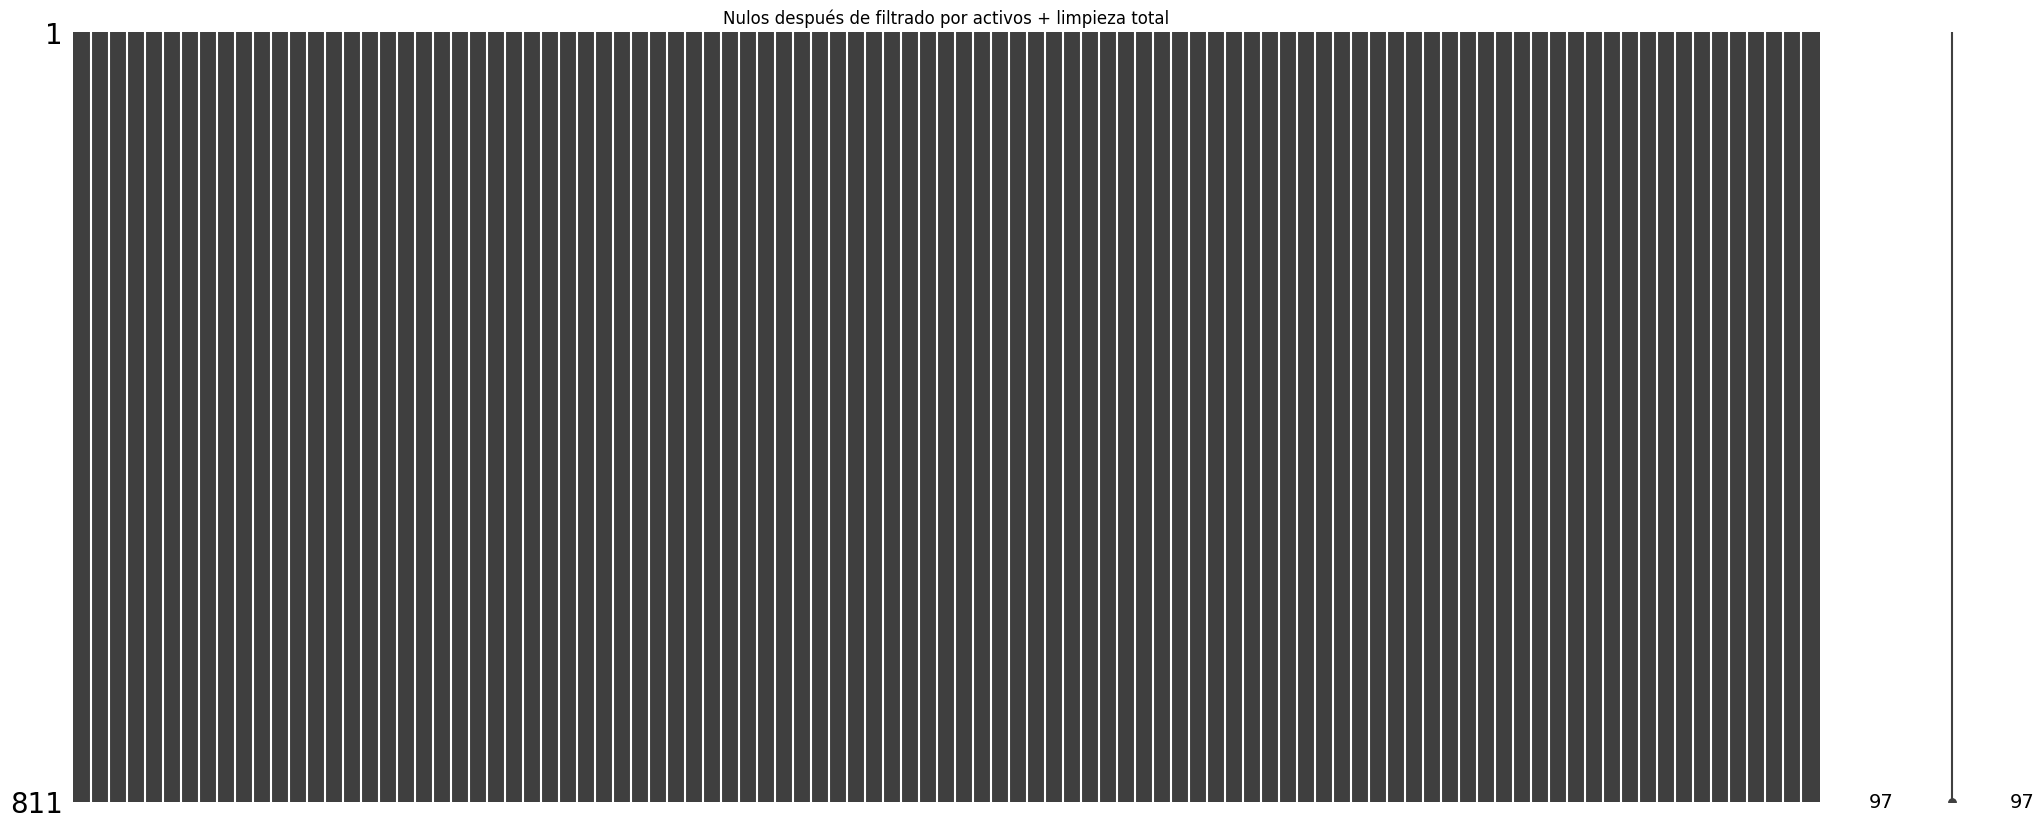

In [11]:
msno.matrix(adj_df)
plt.title("Nulos después de filtrado por activos + limpieza total")
plt.show()


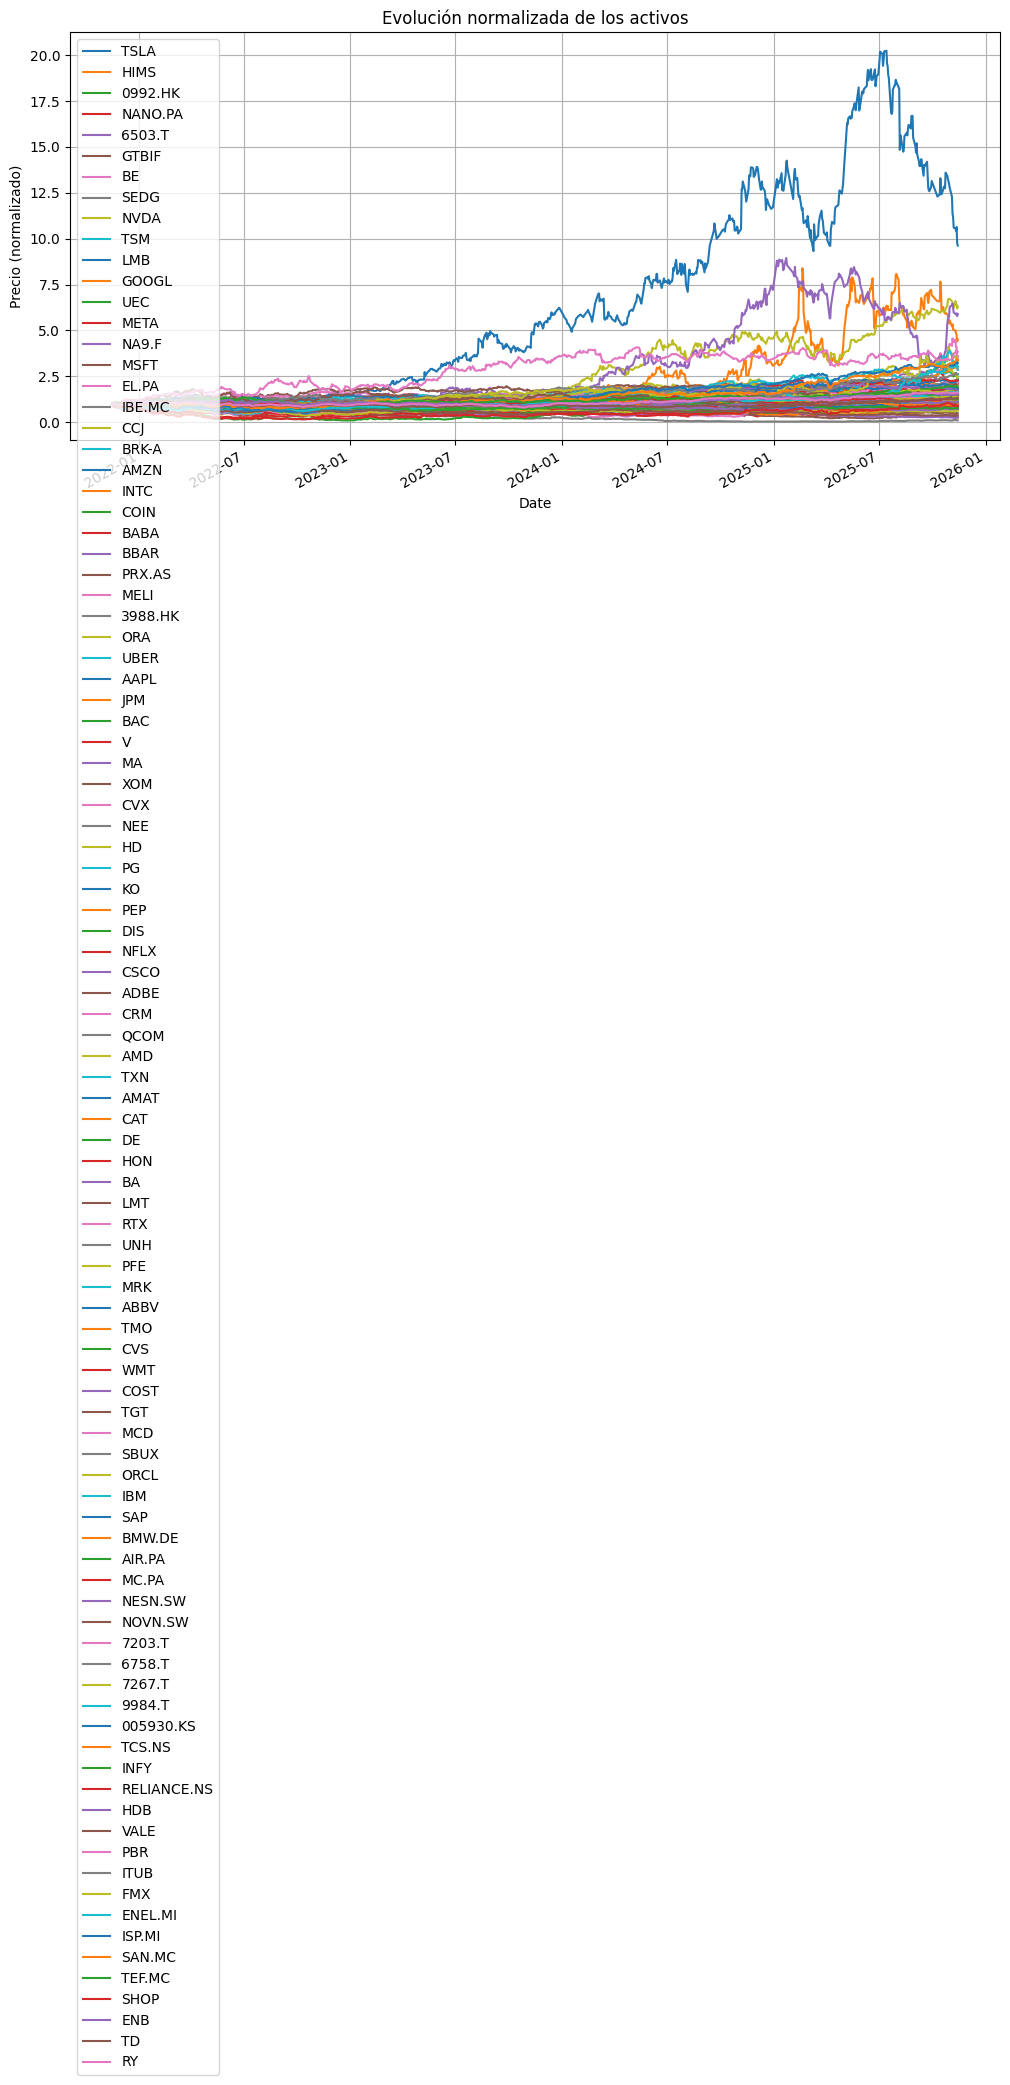

In [12]:
#Grafica de la evolución normalizada de los precios de los activos
indices_p = indices_p.dropna(axis=0, how='any')

activos_precios = indices_p / indices_p.iloc[0, :]

activos_precios.plot(figsize=(12, 6))
plt.title("Evolución normalizada de los activos")
plt.ylabel("Precio (normalizado)")
plt.grid(True)
plt.show()


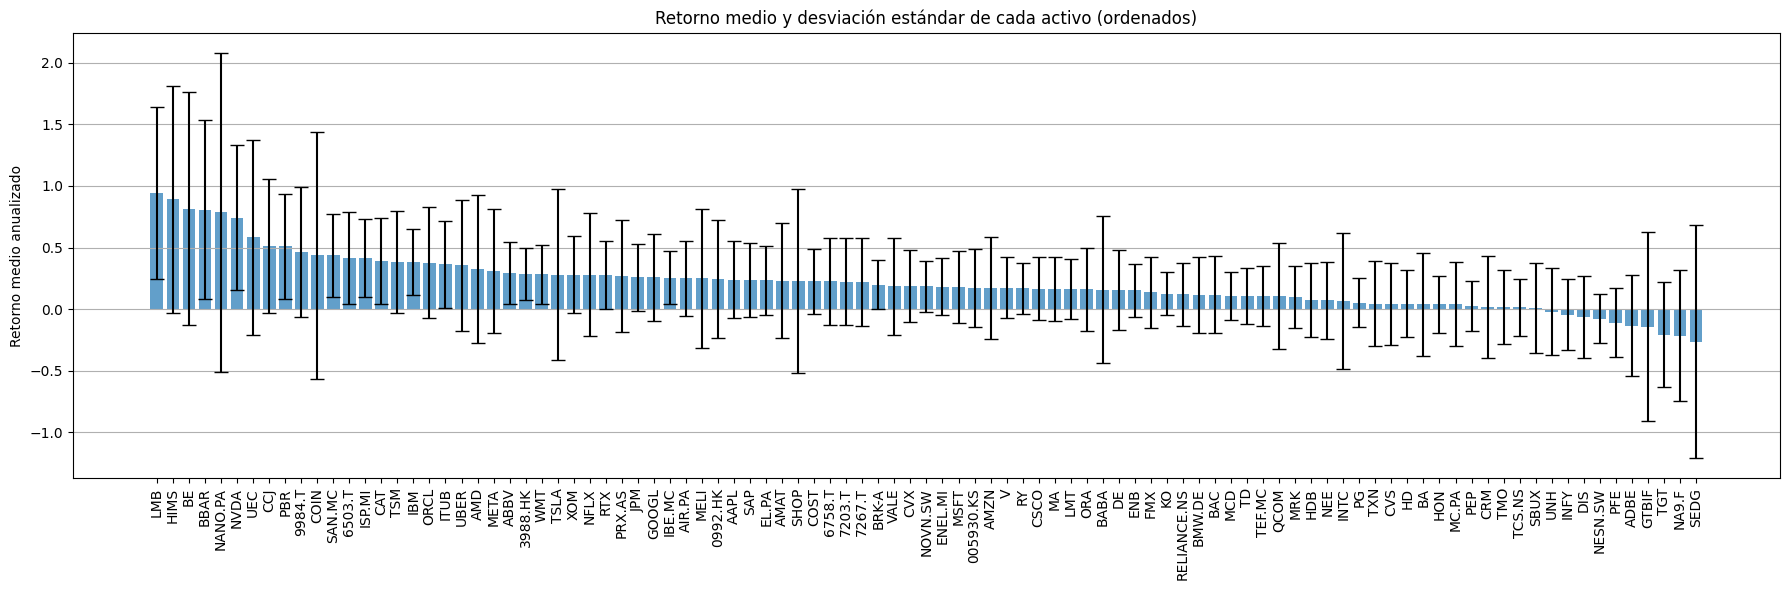

In [13]:
# Cálculo de retornos diarios, media anualizada y desviación estándar anualizada
retornos_activos = indices_p.pct_change().dropna()

# ==== Métricas anualizadas ====
media = retornos_activos.mean() * 252
desviacion = retornos_activos.std() * np.sqrt(252)

# ==== Sharpe simple (sin RF por ahora) ====
sharpe = media / desviacion

# ==== Ordenamiento por retorno ====
orden = media.sort_values(ascending=False).index
media_sorted = media[orden]
desviacion_sorted = desviacion[orden]

#Volumen medio diario
volumen = vol_df.mean()


plt.figure(figsize=(18, 6))
plt.bar(media_sorted.index, media_sorted.values, 
        yerr=desviacion_sorted.values, 
        capsize=5, alpha=0.7)

plt.xticks(rotation=90)
plt.ylabel('Retorno medio anualizado')
plt.title('Retorno medio y desviación estándar de cada activo (ordenados)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [14]:
# Cargar universo y clasificar por región, para visualizar mejor los resultados 
universe_path = PROJECT_ROOT / "config" / "universe" / "universe_equities.yaml"
universe = yaml.safe_load(universe_path.read_text(encoding="utf-8"))
df_universe = pd.DataFrame(universe["tickers"])

# Clasificación por región
def map_region(country):
    country = country.lower()

    if country in ["usa", "united states"]:
        return "usa"
    if country in ["china", "hong kong"]:
        return "china"
    if country in ["spain", "france", "germany", "italy", "netherlands", "switzerland"]:
        return "europe"
    if country in ["japan", "india", "south korea", "taiwan"]:
        return "asia"
    if country in ["brazil", "mexico", "argentina"]:
        return "latam"
    return "other"

df_universe["region"] = df_universe["country"].apply(map_region)

# Agrupar símbolos por región
regiones = (
    df_universe.groupby("region")["symbol_yf"]
    .apply(list)
    .to_dict()
)

color_map = {
    "usa": "#1f77b4",      # azul
    "china": "#ff7f0e",    # naranja
    "europe": "#2ca02c",   # verde
    "asia": "#9467bd",     # púrpura
    "latam": "#d62728",    # rojo
    "other": "#7f7f7f"     # gris
}


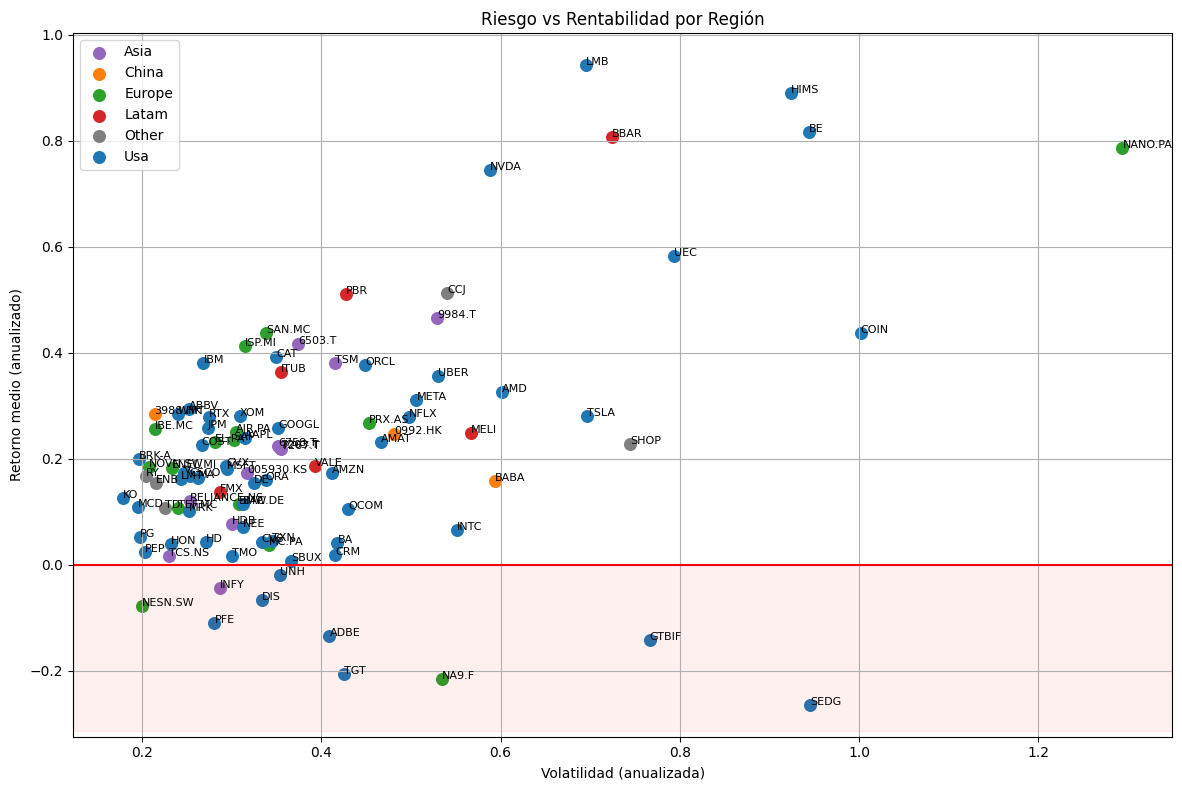

In [15]:
# Gráfico Riesgo vs Rentabilidad por región
plt.figure(figsize=(12, 8))

for region, tickers in regiones.items():

    tickers_validos = [t for t in tickers if t in media.index]

    plt.scatter(
        desviacion[tickers_validos],
        media[tickers_validos],
        color=color_map[region],
        label=region.capitalize(),
        s=70
    )

# Línea roja en y=0
plt.axhline(0, color='red', linewidth=1.5)

# Sombreado rojo bajo cero
plt.axhspan(min(media)-0.05, 0, color='red', alpha=0.06)

# Etiquetas
for t in media.index:
    plt.text(desviacion[t], media[t], t, fontsize=8)

plt.xlabel("Volatilidad (anualizada)")
plt.ylabel("Retorno medio (anualizado)")
plt.title("Riesgo vs Rentabilidad por Región")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Preparación de features para clustering “cartera eficiente”
features_port = pd.DataFrame({
    "mean": media,
    "vol": desviacion,
    "volume": volumen,
    "sharpe": sharpe
}).dropna()

scaler_port = StandardScaler()
X_port = scaler_port.fit_transform(features_port)

kmeans_port = KMeans(n_clusters=4, random_state=42)
features_port["cluster_port"] = kmeans_port.fit_predict(X_port)

Arquitectura que implementaremos desde ese punto:
Fase 1 — Preparación única train/test

(Sin duplicaciones; rolling windows correctos; panel limpio)

Fase 2 — ML supervisado a todo el universo

RandomForestRegressor y GradientBoostingRegressor
(predicción individual por activo)

Fase 3 — Ranking de activos

Función ponderada: predicción + sharpe + momentum

Fase 4 — Selección diversificada

(máx 2 activos por sector, región, etc.)

Fase 5 — HRP

Optimización final con el universo seleccionado

Fase 6 — Backtest mensual

comparación con equal-weight, benchmark, drawdown y sharpe



In [17]:
#PREPARACION DE TRAIN Y TEST SETS PARA ML MODELS
horizon = 21    # horizonte de predicción (días hacia adelante, ~1 mes)
test_days = 21  # número de fechas para el conjunto de test

# 1.1. Panel (Date, Asset) con retornos diarios de TODO el universo
panel = retornos_activos.stack().to_frame("ret")
panel.index.names = ["Date", "Asset"]

g = panel.groupby("Asset")["ret"]

# 1.2. Features rolling (momentum y volatilidad)
panel["ret_1m"] = g.rolling(horizon).sum().reset_index(level=0, drop=True)
panel["ret_3m"] = g.rolling(3 * horizon).sum().reset_index(level=0, drop=True)
panel["ret_6m"] = g.rolling(6 * horizon).sum().reset_index(level=0, drop=True)

panel["vol_1m"] = g.rolling(horizon).std().reset_index(level=0, drop=True)
panel["vol_3m"] = g.rolling(3 * horizon).std().reset_index(level=0, drop=True)
panel["vol_6m"] = g.rolling(6 * horizon).std().reset_index(level=0, drop=True)


#Feature	Significado
#ret_1m	Retorno acumulado 21 días (momentum corto)
#ret_3m	Retorno acumulado 63 días (momentum medio)
#ret_6m	Retorno acumulado 126 días (momentum largo)
#vol_1m	Volatilidad 21 días
#vol_3m	Volatilidad 63 días
#vol_6m	Volatilidad 126 día


# 1.3. Target: retorno acumulado de los próximos 21 días
panel["target_21d"] = (
    g.rolling(horizon).sum()
     .shift(-horizon)
     .reset_index(level=0, drop=True)
)

# 1.4. Eliminar filas con nulos (por ventanas y target)
panel = panel.dropna()

# 1.5. Split único train/test:
#      - tomamos las ÚLTIMAS 25 fechas del panel como test
all_dates = panel.index.get_level_values("Date").unique()
test_dates = all_dates[-test_days:]

date_index = panel.index.get_level_values("Date")
train_mask = ~date_index.isin(test_dates)
test_mask  = date_index.isin(test_dates)

train = panel.loc[train_mask]
test  = panel.loc[test_mask]
test = test.copy()  # evitar SettingWithCopyWarning

print("Fechas de test:", test_dates.min(), "→", test_dates.max())
print("Observaciones train:", len(train))
print("Observaciones test:", len(test))

# 1.6. Matrices X e y
features_ml = ["ret_1m", "ret_3m", "ret_6m", "vol_1m", "vol_3m", "vol_6m"]

X_train = train[features_ml]
y_train = train["target_21d"]

X_test = test[features_ml]
y_test = test["target_21d"]

Fechas de test: 2025-08-29 00:00:00 → 2025-11-14 00:00:00
Observaciones train: 62468
Observaciones test: 2036


In [18]:
#MODELOS DE ML PARA PREDICCIÓN DE RETORNOS A 21 DÍAS

#=======================================
# PIPELINE DE MODELOS DE ML PARA PREDECIR RETORNOS A 21 DÍAS (ML UNIVERSAL)
# Incluye: RandomForest, GradientBoosting, ExtraTrees, XGBoost*, LightGBM*
#=======================================

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


# 1. Escalado único del dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# 2. Diccionario de modelos
models_and_params = {

    "RandomForest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 300],
            "max_depth": [4, 6, 8]
        }
    ),

    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3, 4]
        }
    ),

    "ExtraTrees": (
        ExtraTreesRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 300],
            "max_depth": [4, 6, None]
        }
    )
}

# Intentar cargar XGBoost
try:
    from xgboost import XGBRegressor
    models_and_params["XGBoost"] = (
        XGBRegressor(objective="reg:squarederror", random_state=42),
        {
            "n_estimators": [200, 300],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5, 7]
        }
    )
except:
    print("XGBoost no instalado, se omite.")

# Intentar cargar LightGBM
try:
    from lightgbm import LGBMRegressor
    models_and_params["LightGBM"] = (
        LGBMRegressor(objective="regression", random_state=42),
        {
            "n_estimators": [200, 400],
            "learning_rate": [0.05, 0.1]
        }
    )
except:
    print("LightGBM no instalado, se omite.")





In [19]:
# 3. Evaluación de modelos
tscv = TimeSeriesSplit(n_splits=4)

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0,1]
    da   = np.mean((np.sign(y_true) == np.sign(y_pred)).astype(int))

    print(f"\n=== {name} ===")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.4f}")
    print(f"Correlación pred vs real: {corr:.3f}")
    print(f"Directional Accuracy: {da:.2%}")

    return mae, rmse, r2, corr, da

best_models = []
results_table = []

for name, (model, params) in models_and_params.items():

    print(f"\n##### OPTIMIZANDO: {name} #####")

    gs = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1
    )
    gs.fit(X_train_scaled, y_train)

    best_model = gs.best_estimator_
    pred_test  = best_model.predict(X_test_scaled)

    mae, rmse, r2, corr, da = evaluate_model(name, y_test, pred_test)

    best_models.append({
        "name": name,
        "model": best_model,
        "pred": pred_test,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "corr": corr,
        "da": da
    })

    results_table.append({
        "model": name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "corr": corr,
        "da": da,
        "params": gs.best_params_
    })

results_df = pd.DataFrame(results_table)
print("\n===== RESUMEN DE MODELOS =====")
display(results_df)


# 4. Selección del mejor modelo
# criterio: mínimo MAE + máxima Directional Accuracy
results_df["rank_mae"] = results_df["mae"].rank()
results_df["rank_da"]  = (-results_df["da"]).rank()

results_df["score_final"] = results_df["rank_mae"] + results_df["rank_da"]

best_row = results_df.sort_values("score_final").iloc[0]
chosen_model_name = best_row["model"]

print("\n### MODELO SELECCIONADO:", chosen_model_name, "###")

# obtener las predicciones del modelo ganador
for m in best_models:
    if m["name"] == chosen_model_name:
        chosen_pred_test = m["pred"]
        chosen_model      = m["model"]
        break


# 5. Guardar predicciones en test
test.loc[:, "pred"] = chosen_pred_test
print("Predicciones guardadas en test['pred']")

#MAE: Mean Absolute Error, mae mas bajo = modelo mas preciso
#RMSE: Root Mean Squared Error, rmse mas bajo = modelo mas preciso (penaliza errores grandes)
#R2: Coeficiente de determinación, >0 indica buen ajuste, 1 es perfecto, =0 es media, <0 mal ajuste
#Correlación pred vs real: Correlación entre predicciones y valores reales, más cerca de 1 es mejor
#Directional Accuracy: Porcentaje de predicciones con el signo correcto, más alto es mejor


##### OPTIMIZANDO: RandomForest #####

=== RandomForest ===
MAE:  0.103955
RMSE: 0.168189
R2:   -0.0423
Correlación pred vs real: 0.147
Directional Accuracy: 65.03%

##### OPTIMIZANDO: GradientBoosting #####

=== GradientBoosting ===
MAE:  0.104059
RMSE: 0.169016
R2:   -0.0526
Correlación pred vs real: 0.099
Directional Accuracy: 65.57%

##### OPTIMIZANDO: ExtraTrees #####

=== ExtraTrees ===
MAE:  0.102650
RMSE: 0.166654
R2:   -0.0234
Correlación pred vs real: 0.250
Directional Accuracy: 65.62%

##### OPTIMIZANDO: XGBoost #####

=== XGBoost ===
MAE:  0.103080
RMSE: 0.162846
R2:   0.0228
Correlación pred vs real: 0.287
Directional Accuracy: 63.90%

##### OPTIMIZANDO: LightGBM #####
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 62468, number of used features: 6
[LightGBM] [Info] St

,model,mae,rmse,r2,corr,da,params
0,RandomForest,0.103955,0.168189,-0.042344,0.146930,0.650295,"{'max_depth': 4, 'n_estimators': 200}"
1,GradientBoosting,0.104059,0.169016,-0.052615,0.098594,0.655697,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
2,ExtraTrees,0.102650,0.166654,-0.023405,0.249720,0.656189,"{'max_depth': 4, 'n_estimators': 300}"
3,XGBoost,0.103080,0.162846,0.022832,0.287011,0.638998,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
4,LightGBM,0.104711,0.165896,-0.014105,0.232298,0.644401,"{'learning_rate': 0.05, 'n_estimators': 200}"



### MODELO SELECCIONADO: ExtraTrees ###
Predicciones guardadas en test['pred']


In [327]:
# 
#Guardar el modelo entrenado y el scaler
import joblib

model_dir = PROJECT_ROOT / "models" / "ml_models"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"{chosen_model_name}_model.pkl"
joblib.dump({
    "model": chosen_model,
    "scaler": scaler
}, model_path)

print("Modelo guardado en:", model_path)


Modelo guardado en: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\models\ml_models\ExtraTrees_model.pkl


In [28]:
##EXTRAEMOS LOS ACTIVOS CON MEJOR PREDICCIÓN DE RETORNO A 21 DÍAS
# 1. Reconstrucción del universo ML a partir de predicciones
test = test.copy()
test["pred"] = chosen_pred_test

df_test_full = test.reset_index().copy()
df_filtered = df_test_full[df_test_full["pred"] > 0].copy()
df_ranked = df_filtered.sort_values("pred", ascending=False)

selected_assets_ml = df_ranked["Asset"].unique().tolist()

# 2. Filtrado del universo ML para quedarnos solo con activos USA
selected_us = [t for t in selected_assets_ml if "." not in t and "-" not in t]
print("Activos USA:", selected_us)



Activos USA: ['HIMS', 'BBAR', 'COIN', 'GTBIF', 'ORCL', 'LMB', 'UEC', 'SEDG', 'AMD', 'INTC', 'BE', 'CCJ', 'TSLA', 'SHOP', 'META', 'AMAT', 'TXN', 'BABA', 'TGT', 'UNH', 'MELI', 'BA', 'SBUX', 'CRM', 'SAP', 'FMX', 'ADBE', 'PBR', 'NFLX', 'DIS', 'QCOM', 'DE', 'NVDA', 'AMZN', 'UBER', 'CAT', 'IBM', 'TMO', 'TSM', 'INFY', 'NEE', 'AAPL', 'ITUB', 'HON', 'MRK', 'GOOGL', 'HDB', 'PFE', 'HD', 'CVS', 'CVX', 'VALE', 'RTX', 'ORA', 'KO', 'LMT', 'COST', 'XOM', 'V', 'BAC', 'PG', 'PEP', 'WMT', 'MA', 'MSFT', 'CSCO', 'MCD', 'ABBV', 'JPM', 'ENB', 'RY', 'TD']


In [ ]:
# 3. Mapeo de activos USA a tickers compatibles con Alpaca mediante YAML

# Cargar mapeo desde universe_equities.yaml
universe_path = PROJECT_ROOT / "config" / "universe" / "universe_equities.yaml"
universe = yaml.safe_load(universe_path.read_text(encoding="utf-8"))

# Construir diccionario {symbol_yf → symbol_alpaca}
map_yf_to_alpaca = {
    item["symbol_yf"]: item["symbol_alpaca"]
    for item in universe["tickers"]
    if item.get("symbol_alpaca", None) is not None
}

# Traducir selected_us (tickers del modelo ML) a tickers Alpaca
selected_alpaca = []

for t in selected_us:
    if t in map_yf_to_alpaca:
        selected_alpaca.append(map_yf_to_alpaca[t])

print("Activos finales para Alpaca:", selected_alpaca)
print("Total activos seleccionados:", len(selected_alpaca))


Activos finales para Alpaca: ['HIMS', 'COIN', 'GTBIF', 'ORCL', 'LMB', 'UEC', 'SEDG', 'AMD', 'INTC', 'BE', 'TSLA', 'META', 'AMAT', 'TXN', 'TGT', 'UNH', 'BA', 'SBUX', 'CRM', 'ADBE', 'NFLX', 'DIS', 'QCOM', 'DE', 'NVDA', 'AMZN', 'UBER', 'CAT', 'IBM', 'TMO', 'NEE', 'AAPL', 'HON', 'MRK', 'GOOGL', 'PFE', 'HD', 'CVS', 'CVX', 'RTX', 'ORA', 'KO', 'LMT', 'COST', 'XOM', 'V', 'BAC', 'PG', 'PEP', 'WMT', 'MA', 'MSFT', 'CSCO', 'MCD', 'ABBV', 'JPM']
Total activos seleccionados: 56


In [328]:
# 4. Validación de activos en Alpaca

# Carga de credenciales Alpaca desde .env (seguro y profesional)
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY     = os.getenv("ALPACA_API_KEY")
SECRET_KEY  = os.getenv("ALPACA_API_SECRET")
BASE_URL    = "https://paper-api.alpaca.markets"
print("Credenciales cargadas correctamente.")

print( API_KEY )

Credenciales cargadas correctamente.
PKXMHRQVB5IIK3ISLW6JJYSLIT


In [329]:
import alpaca_trade_api as tradeapi

dotenv_path = PROJECT_ROOT / ".env"

load_dotenv(dotenv_path=dotenv_path, override=True)

API_KEY = os.getenv("ALPACA_API_KEY")
SECRET_KEY = os.getenv("ALPACA_API_SECRET")
BASE_URL = "https://paper-api.alpaca.markets"

api = tradeapi.REST(
    API_KEY,
    SECRET_KEY,
    base_url=BASE_URL
)

account = api.get_account()
print(account.status)


ACTIVE


In [ ]:
# Validación de activos en Alpaca (existencia, traceability, atributos)
# Este módulo descarga datos intradía directamente desde Alpaca:
# - timeframe configurable (1Min, 5Min, 15Min)
# - descarga robusta con manejo de errores
# - consolida en un DataFrame unificado
# Esto prepara la base para el Board InfraVIA: análisis intradía, indicadores y señales.

#posiblemente util para paper trading o live trading


def validate_assets_in_alpaca(symbols):
    records = []

    for s in symbols:
        try:
            asset = api.get_asset(s)

            records.append({
                "symbol": s,
                "exists": True,
                "tradable": asset.tradable,
                "marginable": asset.marginable,
                "shortable": asset.shortable,
                "easy_to_borrow": asset.easy_to_borrow,
                "status": asset.status
            })
        except Exception as e:
            records.append({
                "symbol": s,
                "exists": False,
                "tradable": False,
                "marginable": False,
                "shortable": False,
                "easy_to_borrow": False,
                "status": "NOT_FOUND"
            })

    return pd.DataFrame(records)


# Validación sobre tu universo mapeado (selected_alpaca)
df_validation = validate_assets_in_alpaca(selected_alpaca)

valid_assets = df_validation[
    (df_validation["exists"] == True) &
    (df_validation["tradable"] == True)
]["symbol"].tolist()

invalid_assets = df_validation[
    (df_validation["exists"] == False) |
    (df_validation["tradable"] == False)
]["symbol"].tolist()


#VALID_ASSETS DEJAMOS LOS PRIMEROS 20 ACTIVOS PARA ANALISIS INTRADIA
#Con mejor retorno predicho a 21 días y que sean tradeables en Alpaca
valid_assets = valid_assets[:20]
print("Activos finales seleccionados para análisis intradía:", valid_assets)

#ACTIVOS ADICIONALES QUE SE ESPERAN DE ALTA LIQUIDEZ--- PRUEBA 
extra_assets = ["AAPL", "MSFT", "AMZN", "NVDA", "SPY"]
for ea in extra_assets:
    if ea not in valid_assets:
        valid_assets.append(ea)

print("Activos totales para análisis intradía (incluyendo extras):", len(valid_assets))

Activos finales seleccionados para análisis intradía: ['HIMS', 'COIN', 'ORCL', 'LMB', 'UEC', 'SEDG', 'AMD', 'INTC', 'BE', 'TSLA', 'META', 'AMAT', 'TXN', 'TGT', 'UNH', 'BA', 'SBUX', 'CRM', 'ADBE', 'NFLX']
Activos totales para análisis intradía (incluyendo extras): 25


In [240]:
#EXTRACCION DE DATA POR MEDIO DE MASSIVE API KEY
from dotenv import load_dotenv
from massive import RESTClient

load_dotenv()

MASSIVE_KEY = os.getenv("MASSIVE_API_SECRET")
client = RESTClient(MASSIVE_KEY)


In [241]:
# FUNCION DESCARGA INTRADIA MULTI-ACTIVO (1MIN)

def get_massive_intraday(symbol, multiplier=1, timespan="minute",
                         start="2023-01-01", end="2023-01-05"):

    bars = []
    for a in client_massive.list_aggs(
        ticker=symbol,
        multiplier=multiplier,
        timespan=timespan,
        from_=start,
        to=end,
        adjusted=True,
        sort="asc",
        limit=50000
    ):
        bars.append(a)

    if len(bars) == 0:
        print(f"{symbol}: no hay datos en ese rango → devuelve vacío")
        return pd.DataFrame()

    # Convertimos los objetos Agg a diccionario
    df = pd.DataFrame([{
        "timestamp": pd.to_datetime(b.timestamp, unit="ms"),
        "open": b.open,
        "high": b.high,
        "low": b.low,
        "close": b.close,
        "volume": b.volume,
        "vwap": b.vwap,
        "transactions": b.transactions,
        "symbol": symbol
    } for b in bars])

    return df


In [11]:
#para guardar los datos intradia descargados
from datetime import datetime, timedelta
import pandas as pd

# Carpeta destino: data/prices_raw/YYYY-MM-DD/
yesterday = datetime.today() - timedelta(days=1)
today_str = yesterday.strftime("%Y-%m-%d")

save_path = PROJECT_ROOT / "data" / "prices_raw" / today_str
save_path.mkdir(parents=True, exist_ok=True)

output_file = save_path / "intraday_1min.parquet"

print("Guardando dataset 1min en:", output_file)


NameError: name 'PROJECT_ROOT' is not defined

In [9]:
#Definir rango de fechas (2 años)
end_date = yesterday
start_date = end_date - timedelta(days=365*2)

start_str = start_date.strftime("%Y-%m-%d")
end_str = end_date.strftime("%Y-%m-%d")

print(f"Rango 1min: {start_str} → {end_str}\n")


Rango 1min: 2023-11-16 → 2025-11-15



In [244]:
#Descarga de historico de datos intradia 1min para los activos validados

all_data = []

for symbol in valid_assets:

    # Mostrar "Descargando XYZ..." en la misma línea
    print(f"\rDescargando {symbol}...", end="", flush=True)

    try:
        df = get_massive_intraday(
            symbol=symbol,
            multiplier=1,
            timespan="minute",
            start=start_str,
            end=end_str
        )

        if df.empty:
            print(f"\r{symbol}: SIN DATOS     ")
            continue

        all_data.append(df)
        print(f"\r{symbol}: OK           ")

    except Exception as e:
        print(f"\r{symbol}: ERROR → {str(e)}      ")
        continue


HIMS: OK           
COIN: OK           
ORCL: OK           
LMB: OK           
UEC: OK           
SEDG: OK           
AMD: OK           
INTC: OK           
BE: OK           
TSLA: OK           
META: OK           
AMAT: OK           
TXN: OK           
TGT: OK           
UNH: OK           
BA: OK           
SBUX: OK           
CRM: OK           
ADBE: OK           
NFLX: OK           
AAPL: OK           
MSFT: OK           
AMZN: OK           
NVDA: OK           
SPY: OK           


In [ ]:
#Guardado final de dataset intradía 1min
if len(all_data) == 0:
    print("\n No se descargó ningún asset. Revisar universo o fechas.")
else:
    df_final = pd.concat(all_data, ignore_index=True)
    df_final = df_final.sort_values(["timestamp", "symbol"])

    df_final.to_parquet(output_file)
    print("\n Dataset 1min guardado en:", output_file)
    print("Tamaño final:", df_final.shape)



✅ Dataset 1min guardado en: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data\prices_raw\2025-11-15\intraday_1min.parquet
Tamaño final: (7207068, 9)


In [2]:
#RANGO DE FECHAS (5 AÑOS)                                                           **

end_date = datetime.today() - timedelta(days=1)
start_date_5m = end_date - timedelta(days=365*5)

start_5m_str = start_date_5m.strftime("%Y-%m-%d")
end_5m_str = end_date.strftime("%Y-%m-%d")

print(f"Rango 5min: {start_5m_str} → {end_5m_str}\n")

NameError: name 'datetime' is not defined

In [248]:
#DESCARGA DE HISTORICO DE DATOS INTRADIA 5MIN PARA LOS ACTIVOS VALIDADOS 5Y

all_data_5m = []

for symbol in valid_assets:

    print(f"\rDescargando {symbol} (5min)...", end="", flush=True)

    try:
        df = get_massive_intraday(
            symbol=symbol,
            multiplier=5,
            timespan="minute",
            start=start_5m_str,
            end=end_5m_str
        )

        if df.empty:
            print(f"\r{symbol} (5min): SIN DATOS     ")
            continue

        all_data_5m.append(df)
        print(f"\r{symbol} (5min): OK           ")

    except Exception as e:
        print(f"\r{symbol} (5min): ERROR → {str(e)}      ")
        continue


HIMS (5min): OK           
COIN (5min): OK           
ORCL (5min): OK           
LMB (5min): OK           
UEC (5min): OK           
SEDG (5min): OK           
AMD (5min): OK           
INTC (5min): OK           
BE (5min): OK           
TSLA (5min): OK           
META (5min): OK           
AMAT (5min): OK           
TXN (5min): OK           
TGT (5min): OK           
UNH (5min): OK           
BA (5min): OK           
SBUX (5min): OK           
CRM (5min): OK           
ADBE (5min): OK           
NFLX (5min): OK           
AAPL (5min): OK           
MSFT (5min): OK           
AMZN (5min): OK           
NVDA (5min): OK           
SPY (5min): OK           


In [ ]:
#Guardar selección final 

output_file_5m = save_path / "intraday_5min.parquet"

if len(all_data_5m) == 0:
    print("\n No se descargó ningún activo en 5min.")
else:
    df_5m = pd.concat(all_data_5m, ignore_index=True)
    df_5m = df_5m.sort_values(["timestamp", "symbol"])
    df_5m.to_parquet(output_file_5m)
    
    print("\n Dataset 5min guardado en:", output_file_5m)
    print("Tamaño final:", df_5m.shape)




✅ Dataset 5min guardado en: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data\prices_raw\2025-11-15\intraday_5min.parquet
Tamaño final: (4145035, 9)


#### MÓDULO DE VALIDACIÓN TOTAL INTRADÍA

In [5]:
#importar todas las librerias que estamos usando 
import pandas as pd
import numpy as np
from pathlib import Path
import yaml
from IPython.display import display
import matplotlib.pyplot as plt
import warnings
import datetime as dt
from datetime import datetime, timedelta
import os


yesterday = datetime.today() - timedelta(days=1)
today_str = yesterday.strftime("%Y-%m-%d")
warnings.filterwarnings("ignore")
save_path = PROJECT_ROOT / "data" / "prices_raw" / today_str
output_file = save_path / "intraday_1min.parquet"
output_file_5m = save_path / "intraday_5min.parquet"
end_date = datetime.today() - timedelta(days=1)
start_date_5m = end_date - timedelta(days=365*5)

start_date_5m = end_date - timedelta(days=365*5)

start_5m_str = start_date_5m.strftime("%Y-%m-%d")
end_5m_str = end_date.strftime("%Y-%m-%d")


In [6]:
#Tomamos en cuenta el calendario oficial NYSE para filtrar días festivos y fines de semana

import pandas_market_calendars as mcal

nyse = mcal.get_calendar('NYSE')
schedule = nyse.valid_days(start_date=start_5m_str, end_date=end_5m_str)
market_days = set(schedule.date)


In [8]:
# Cargar datasets recién descargados
#df_1m = pd.read_parquet(output_file)          # intraday_1min.parquet
#df_5m = pd.read_parquet(output_file_5m)       # intraday_5min.parquet

df_1m = pd.read_parquet('C:\\Users\\karen\\Documents\\MASTER_FINANZAS\\TFM\\TFM-ML-Trading\\data\\prices_raw\\2025-11-15\\intraday_1min.parquet')          # intraday_1min.parquet
df_5m = pd.read_parquet('C:\\Users\\karen\\Documents\\MASTER_FINANZAS\\TFM\\TFM-ML-Trading\\data\\prices_raw\\2025-11-15\\intraday_5min.parquet')       # intraday_5min.parquet

print("1min:", df_1m.shape)
print("5min:", df_5m.shape)

1min: (7207068, 9)
5min: (4145035, 9)


In [9]:
#Que horarios estamos teniendo en los datasets
hours_1m = df_1m["timestamp"].dt.hour.unique()
hours_5m = df_5m["timestamp"].dt.hour.unique()

print("Horas únicas 1m:", sorted(hours_1m))
print("Horas únicas 5m:", sorted(hours_5m))

Horas únicas 1m: [0, 1, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Horas únicas 5m: [0, 1, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


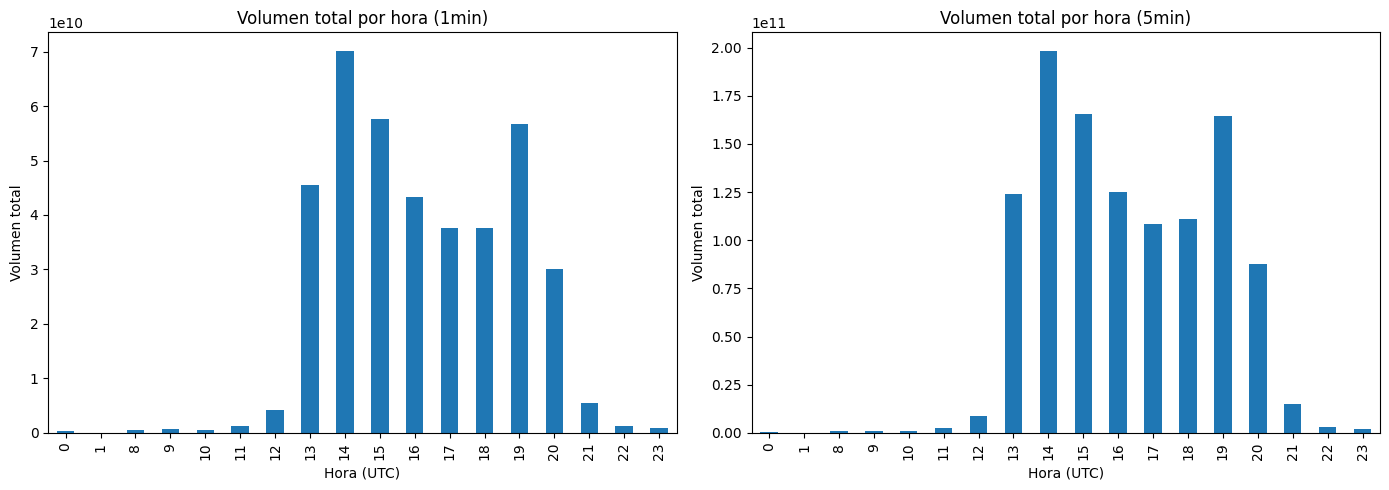

In [10]:
#grafico de barras por volumen por hora (2 graficos en 1 fila)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
df_1m.groupby(df_1m["timestamp"].dt.hour)["volume"].sum().plot(
    kind="bar", title="Volumen total por hora (1min)"
)
plt.ylabel("Volumen total")
plt.xlabel("Hora (UTC)")

plt.subplot(1, 2, 2)
df_5m.groupby(df_5m["timestamp"].dt.hour)["volume"].sum().plot(
    kind="bar", title="Volumen total por hora (5min)"
)
plt.ylabel("Volumen total")
plt.xlabel("Hora (UTC)")

plt.tight_layout()
plt.show()

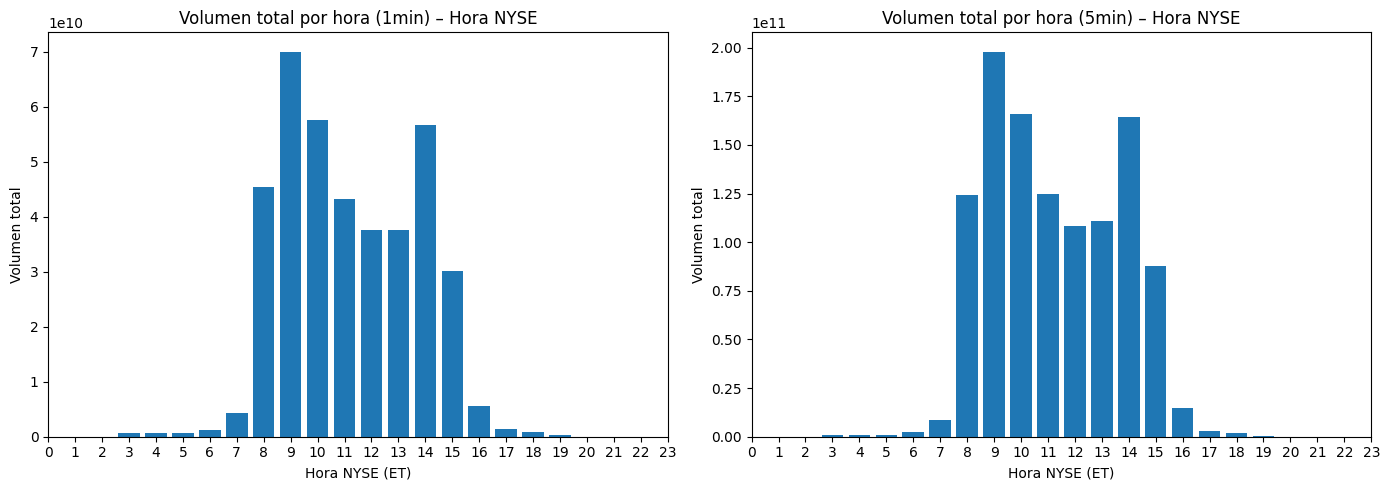

In [11]:
#Visualizamos esto en horiario Madrid 
# 1. Calcular volúmenes por hora
vol_1m = df_1m.groupby(df_1m["timestamp"].dt.hour)["volume"].sum()
vol_5m = df_5m.groupby(df_5m["timestamp"].dt.hour)["volume"].sum()

# 2. Crear etiquetas para NYSE 
nyse_labels_1m = [(h - 5) % 24 for h in vol_1m.index]
nyse_labels_5m = [(h - 5) % 24 for h in vol_5m.index]

# 3. Graficar usando las mismas barras PERO con etiquetas NYSE
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(nyse_labels_1m, vol_1m.values)
plt.title("Volumen total por hora (1min) – Hora NYSE")
plt.xlabel("Hora NYSE (ET)")
plt.ylabel("Volumen total")
plt.xticks(range(0, 24))

plt.subplot(1, 2, 2)
plt.bar(nyse_labels_5m, vol_5m.values)
plt.title("Volumen total por hora (5min) – Hora NYSE")
plt.xlabel("Hora NYSE (ET)")
plt.ylabel("Volumen total")
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()


In [12]:
#filtramos las fechas que solo aplican a dias de bolsa activa
df_1m = df_1m[df_1m["timestamp"].dt.date.isin(market_days)]
df_5m = df_5m[df_5m["timestamp"].dt.date.isin(market_days)]

#FILTRAMOS DFs POR HORARIOS DE MERCADO UTC 13:00 a 21:00 - tiempo premarket incluido 
df_1m = df_1m[(df_1m["timestamp"].dt.hour >= 13) & (df_1m["timestamp"].dt.hour <= 21)]
df_5m = df_5m[(df_5m["timestamp"].dt.hour >= 13) & (df_5m["timestamp"].dt.hour <= 21)]

print("Después de filtrar por días de mercado:")
print("1min:", df_1m.shape) 
print("5min:", df_5m.shape)

Después de filtrar por días de mercado:
1min: (5591353, 9)
5min: (2957934, 9)


In [13]:
# Asegurar que ambos datasets tienen los mismos activos

assets_1m = set(df_1m["symbol"].unique())
assets_5m = set(df_5m["symbol"].unique())

print("Activos en 1min:", len(assets_1m))
print("Activos en 5min:", len(assets_5m))

missing_in_5m = assets_1m - assets_5m
missing_in_1m = assets_5m - assets_1m

print("Activos presentes solo en 1min:", missing_in_5m)
print("Activos presentes solo en 5min:", missing_in_1m)

common_assets = assets_1m & assets_5m
df_1m = df_1m[df_1m["symbol"].isin(common_assets)]
df_5m = df_5m[df_5m["symbol"].isin(common_assets)]

print("Activos finales comunes:", len(common_assets))


Activos en 1min: 25
Activos en 5min: 25
Activos presentes solo en 1min: set()
Activos presentes solo en 5min: set()
Activos finales comunes: 25


In [14]:
#Duplicados intradia
dups_1m = df_1m.duplicated(subset=["timestamp", "symbol"]).sum()
dups_5m = df_5m.duplicated(subset=["timestamp", "symbol"]).sum()

print("Duplicados 1min:", dups_1m)
print("Duplicados 5min:", dups_5m)

df_1m = df_1m.drop_duplicates(subset=["timestamp", "symbol"])
df_5m = df_5m.drop_duplicates(subset=["timestamp", "symbol"])


Duplicados 1min: 0
Duplicados 5min: 0


In [15]:
#Nulos por activo
nulls_by_symbol_1m = df_1m.groupby("symbol").apply(lambda x: x.isna().sum(), include_groups=False)
nulls_by_symbol_5m = df_5m.groupby("symbol").apply(lambda x: x.isna().sum(), include_groups=False)

print("Nulos por símbolo en 1min:")
print(nulls_by_symbol_1m[(nulls_by_symbol_1m.sum(axis=1) > 0)])

print("Nulos por símbolo en 5min:")
print(nulls_by_symbol_5m[(nulls_by_symbol_5m.sum(axis=1) > 0)])


Nulos por símbolo en 1min:
Empty DataFrame
Columns: [timestamp, open, high, low, close, volume, vwap, transactions]
Index: []
Nulos por símbolo en 5min:
Empty DataFrame
Columns: [timestamp, open, high, low, close, volume, vwap, transactions]
Index: []


In [16]:
# Construcción de fechas y días de mercado (1m y 5m)

end_date = yesterday

# Fechas base
end_date = (datetime.today() - timedelta(days=1)).date()
start_date_1m = end_date - timedelta(days=365*2)
start_date_5m = end_date - timedelta(days=365*5)

# Calendario NYSE
nyse = mcal.get_calendar("NYSE")

market_days_1m = nyse.valid_days(start_date=start_date_1m, end_date=end_date).date
market_days_5m = nyse.valid_days(start_date=start_date_5m, end_date=end_date).date


In [17]:
def build_daily_clock(start="13:00", end="21:00"):
    """
    Devuelve la ventana horaria diaria permitida (horario UTC).
    """
    t = lambda x: datetime.strptime(x, "%H:%M").time()
    return [(t(start), t(end))]


def filter_by_time_window(df, start="13:00", end="21:00"):
    """
    Filtra un DataFrame sin crear copias completas (eficiente para datasets grandes).
    Mantiene columnas originales sin duplicar el DataFrame.
    """
    start_t = datetime.strptime(start, "%H:%M").time()
    end_t   = datetime.strptime(end, "%H:%M").time()

    # Solo generamos la columna temporal (NO copiamos el DF entero)
    times = df["timestamp"].dt.time

    mask = (times >= start_t) & (times <= end_t)

    return df.loc[mask]


In [18]:
#  Definimos ventana horaria
start_t = datetime.strptime("13:00", "%H:%M").time()
end_t   = datetime.strptime("21:00", "%H:%M").time()


# Filas fuera del rango (ANTES de filtrar)
out_of_window_1m = (~df_1m["timestamp"].dt.time.between(start_t, end_t)).sum()
out_of_window_5m = (~df_5m["timestamp"].dt.time.between(start_t, end_t)).sum()

# Guardamos tamaños antes de filtrar para cálculo correcto
before_1m = df_1m.shape[0]
before_5m = df_5m.shape[0]


# Filtramos 
df_1m = df_1m[df_1m["timestamp"].dt.time.between(start_t, end_t)]
df_5m = df_5m[df_5m["timestamp"].dt.time.between(start_t, end_t)]

#  Resumen
print("Filas fuera 1m:", out_of_window_1m, 
      "→", round(out_of_window_1m / before_1m * 100, 2), "%")
print("Filas fuera 5m:", out_of_window_5m, 
      "→", round(out_of_window_5m / before_5m * 100, 2), "%")

print("Después de filtrar:")
print("1m:", df_1m.shape)
print("5m:", df_5m.shape)

Filas fuera 1m: 277640 → 4.97 %
Filas fuera 5m: 184573 → 6.24 %
Después de filtrar:
1m: (5313713, 9)
5m: (2773361, 9)


In [19]:
#Función general para construir un master clock por timeframe
def build_master_clock(market_days, freq="1min"):
    """
    Construye un master clock naïve (sin timezone), 
    usando la ventana fija 13:00–21:00.
    """
    t = lambda x: datetime.strptime(x, "%H:%M").time()
    start_t, end_t = t("13:00"), t("21:00")

    master = {}

    for d in market_days:
        start_dt = datetime.combine(d, start_t)
        end_dt   = datetime.combine(d, end_t)

        rng = pd.date_range(start=start_dt, end=end_dt, freq=freq)
        master[d] = rng.to_pydatetime().tolist()

    return master



In [20]:
from tqdm import tqdm

def reconstruct_with_master_clock(df, master_clock):
    """
    Reconstruye el dataset para que:
      - Cada símbolo tenga todas las marcas de tiempo del master_clock.
      - Los precios (O/H/L/C/VWAP) se ffill a través de TODO el histórico.
      - Volume y transactions se rellenan con 0 donde falten.
      - Se eliminan las filas iniciales por símbolo que no tengan todavía precios válidos.
    """
    # Aseguramos orden global primero
    df = df.sort_values(["symbol", "timestamp"]).copy()
    symbols = df["symbol"].unique()

    # Preparamos índices esperados (master clock) como una sola lista de timestamps ordenada
    all_ts = []
    for day, ts_list in master_clock.items():
        all_ts.extend(ts_list)
    expected_index = pd.DatetimeIndex(sorted(set(all_ts)), name="timestamp")

    result_parts = []

    for sym in tqdm(symbols, desc="Reconstruyendo activos"):
        df_sym = df[df["symbol"] == sym].copy()

        # Usamos timestamp como índice para poder reindexar
        df_sym = df_sym.set_index("timestamp").sort_index()

        # Quitamos 'symbol' de aquí para no duplicarla al hacer join
        df_sym = df_sym.drop(columns=["symbol"], errors="ignore")

        # Base con todas las marcas de tiempo esperadas
        full = pd.DataFrame(index=expected_index)
        full["symbol"] = sym

        # Join de datos reales sobre las marcas del master clock
        full = full.join(df_sym, how="left")

        # Forward-fill de precios a través de TODO el histórico
        price_cols = ["open", "high", "low", "close", "vwap"]
        full[price_cols] = full[price_cols].ffill()

        # Volumen y transacciones: 0 donde falten
        if "volume" in full.columns:
            full["volume"] = full["volume"].fillna(0)
        else:
            full["volume"] = 0

        if "transactions" in full.columns:
            full["transactions"] = full["transactions"].fillna(0)
        else:
            full["transactions"] = 0

        # Eliminar filas iniciales sin precio (por símbolo)
        first_valid_idx = full["close"].first_valid_index()
        if first_valid_idx is not None:
            full = full.loc[first_valid_idx:]

        # Volvemos a columna normal
        full = full.reset_index()

        result_parts.append(full)

    # Concatenamos todos los símbolos y dejamos ordenado
    final_df = pd.concat(result_parts, ignore_index=True)
    final_df = final_df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

    return final_df



In [21]:
# construir master clocks 1m y 5m
master_clock_1m = build_master_clock(market_days_1m, freq="1min")
master_clock_5m = build_master_clock(market_days_5m, freq="5min")

# reconstrucción
df_1m_filled = reconstruct_with_master_clock(df_1m, master_clock_1m)
df_5m_filled = reconstruct_with_master_clock(df_5m, master_clock_5m)

print("1m reconstruido:", df_1m_filled.shape)
print("5m reconstruido:", df_5m_filled.shape)


Reconstruyendo activos: 100%|██████████| 25/25 [00:11<00:00,  2.22it/s]


1m reconstruido: (6036346, 9)
5m reconstruido: (3015345, 9)


In [22]:
print("\n Dimensiones ORIGINALES... ")
print("1min original:", df_1m.shape)
print("5min original:", df_5m.shape)


print("\n Dimensiones DESPUÉS DEL RELLENO... ")
print("1min rellenado:", df_1m_filled.shape)
print("5min rellenado:", df_5m_filled.shape)



 Dimensiones ORIGINALES... 
1min original: (5313713, 9)
5min original: (2773361, 9)

 Dimensiones DESPUÉS DEL RELLENO... 
1min rellenado: (6036346, 9)
5min rellenado: (3015345, 9)


In [23]:
# Guardado de datasets limpios y reconstruidos
today = datetime.now().strftime("%Y-%m-%d")
save_dir = PROJECT_ROOT / "data" / "prices_clean" / today
os.makedirs(save_dir, exist_ok=True)

path_1m = save_dir / f"intraday_1m_clean_{today}.parquet"
path_5m = save_dir / f"intraday_5m_clean_{today}.parquet"

df_1m_filled.to_parquet(path_1m, index=False)
df_5m_filled.to_parquet(path_5m, index=False)

print("✔ Guardado 1m →", path_1m)
print("✔ Guardado 5m →", path_5m)


✔ Guardado 1m → c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data\prices_clean\2025-11-20\intraday_1m_clean_2025-11-20.parquet
✔ Guardado 5m → c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data\prices_clean\2025-11-20\intraday_5m_clean_2025-11-20.parquet


In [24]:
#LEER DATASETS LIMPIOS, LA FECHA MAS RECIENTE 
#EMPREZAR DESDE AQUI PARA AGILIZAR CARGAR DATA SET

latest_date = max((PROJECT_ROOT / "data" / "prices_clean").iterdir(), key=os.path.getmtime).name
path_1m = PROJECT_ROOT / "data" / "prices_clean" / latest_date / f"intraday_1m_clean_{latest_date}.parquet"
path_5m = PROJECT_ROOT / "data" / "prices_clean" / latest_date / f"intraday_5m_clean_{latest_date}.parquet"

df_1m_clean = pd.read_parquet(path_1m)
df_5m_clean = pd.read_parquet(path_5m)
print("Cargado dataset 1m limpio:", df_1m_clean.shape)
print("Cargado dataset 5m limpio:", df_5m_clean.shape)

Cargado dataset 1m limpio: (6036346, 9)
Cargado dataset 5m limpio: (3015345, 9)


In [25]:
def check_missing_days_per_symbol(df, market_days):
    """
    Verifica que cada símbolo tenga datos en todos los días del calendario de mercado.
    """
    df["date"] = df["timestamp"].dt.date
    symbols = df["symbol"].unique()
    
    missing_report = {}

    for sym in symbols:
        df_days = set(df[df["symbol"] == sym]["date"])
        missing = set(market_days) - df_days
        if missing:
            missing_report[sym] = sorted(list(missing))
    
    print("✔ Días faltantes por símbolo (si vacío, todo perfecto):")
    return missing_report


In [26]:
#para 1m deberías tener 480 filas por día (8 horas * 60).
#Para 5m deberías tener 96 filas por día (8 horas * 12).


def check_rows_per_day(df, expected_rows):
    """
    Verifica el número de filas por día y por símbolo.
    Detecta días incompletos o sobrantes.
    """
    df["date"] = df["timestamp"].dt.date
    symbols = df["symbol"].unique()

    bad_days = {}

    for sym in symbols:
        sym_df = df[df["symbol"] == sym]
        counts = sym_df.groupby("date").size()

        wrong = counts[counts != expected_rows]
        if not wrong.empty:
            bad_days[sym] = wrong.to_dict()

    print("✔ Días con número incorrecto de filas por símbolo (si vacío → perfecto):")
    return bad_days


In [27]:
def check_time_window_correct(df, start="13:00", end="21:00"):
    start_t = datetime.strptime(start, "%H:%M").time()
    end_t   = datetime.strptime(end, "%H:%M").time()

    bad = df[
        ~df["timestamp"].dt.time.between(start_t, end_t)
    ]

    print("✔ Filas fuera de la ventana horaria:", bad.shape[0])
    return bad


In [28]:
def check_time_window_correct(df, start="13:00", end="21:00"):
    start_t = datetime.strptime(start, "%H:%M").time()
    end_t   = datetime.strptime(end, "%H:%M").time()

    bad = df[
        ~df["timestamp"].dt.time.between(start_t, end_t)
    ]

    print("✔ Filas fuera de la ventana horaria:", bad.shape[0])
    return bad


In [29]:
def check_nans(df):
    nans = df.isna().sum()
    print("✔ NaNs por columna:")
    print(nans[nans > 0])
    return nans
def check_duplicates(df):
    dups = df[df.duplicated(subset=["symbol", "timestamp"], keep=False)]
    print("✔ Duplicados encontrados:", dups.shape[0])
    return dups


In [30]:
def check_sort_order(df):
    bad = df[
        (df["timestamp"].shift(1) > df["timestamp"]) &
        (df["symbol"] == df["symbol"].shift(1))
    ]
    print("✔ Filas fuera de orden temporal:", bad.shape[0])
    return bad


In [31]:
def run_full_quality_check(df, market_days, expected_rows):
    print("\n===== VALIDACIÓN DE CALIDAD DEL DATASET =====\n")
    
    res1 = check_missing_days_per_symbol(df, market_days)
    res2 = check_rows_per_day(df, expected_rows)
    res3 = check_time_window_correct(df)
    res4 = check_duplicates(df)
    res5 = check_nans(df)
    res6 = check_sort_order(df)

    print("\n===== VALIDACIÓN COMPLETA TERMINADA =====\n")

    return {
        "missing_days": res1,
        "bad_row_counts": res2,
        "outside_window": res3,
        "duplicates": res4,
        "nans": res5,
        "order_issues": res6
    }


In [32]:
#mostrar tail(50) de filas con nans en volume'].isna de df 1m y 5m
print("Filas con NaNs en 1min:")
print(df_1m_clean[df_1m_clean['volume'].isna()].tail(50)) 
print("\nFilas con NaNs en 5min:")
print(df_5m_clean[df_5m_clean['volume'].isna()].
tail(50))   

Filas con NaNs en 1min:
Empty DataFrame
Columns: [timestamp, symbol, open, high, low, close, volume, vwap, transactions]
Index: []

Filas con NaNs en 5min:
Empty DataFrame
Columns: [timestamp, symbol, open, high, low, close, volume, vwap, transactions]
Index: []


In [33]:
report_1m = run_full_quality_check(
    df_1m_clean,
    market_days_1m,
    expected_rows=480
)



===== VALIDACIÓN DE CALIDAD DEL DATASET =====

✔ Días faltantes por símbolo (si vacío, todo perfecto):
✔ Días con número incorrecto de filas por símbolo (si vacío → perfecto):
✔ Filas fuera de la ventana horaria: 0
✔ Duplicados encontrados: 0
✔ NaNs por columna:
Series([], dtype: int64)
✔ Filas fuera de orden temporal: 0

===== VALIDACIÓN COMPLETA TERMINADA =====



In [34]:
report_5m = run_full_quality_check(
    df_5m_clean ,
    market_days_5m,
    expected_rows=96
)



===== VALIDACIÓN DE CALIDAD DEL DATASET =====

✔ Días faltantes por símbolo (si vacío, todo perfecto):
✔ Días con número incorrecto de filas por símbolo (si vacío → perfecto):
✔ Filas fuera de la ventana horaria: 0
✔ Duplicados encontrados: 0
✔ NaNs por columna:
Series([], dtype: int64)
✔ Filas fuera de orden temporal: 0

===== VALIDACIÓN COMPLETA TERMINADA =====



#### Selección de acivos intradia

In [35]:
#Agregamos formato UTC a los df

df_1m = df_1m_clean.copy()
df_5m = df_5m_clean.copy()

df_1m["timestamp"] = pd.to_datetime(df_1m["timestamp"], utc=True)
df_5m["timestamp"] = pd.to_datetime(df_5m["timestamp"], utc=True)

In [36]:

# Extraer fecha, hora y minuto (nos sirve para los patrones intradía)
df_1m["date"] = df_1m["timestamp"].dt.date
df_1m["hour"] = df_1m["timestamp"].dt.hour
df_1m["minute"] = df_1m["timestamp"].dt.minute

# Orden por símbolo y tiempo
df_1m = df_1m.sort_values(["symbol", "timestamp"])

# Parámetros
WINDOW_DAYS = 20   # días para calcular el volumen medio por minuto
MIN_PERIODS = 5    # mínimo de observaciones para que la media sea válida

In [37]:
# Para que rolling() funcione bien, necesitamos que dentro de cada grupo (symbol, hour, minute)
# los registros estén en orden temporal (ya lo están por el sort anterior).

df_1m["mean_vol_1m"] = (
    df_1m.groupby(["symbol", "hour", "minute"])["volume"]
         .transform(lambda x: x.rolling(WINDOW_DAYS, min_periods=MIN_PERIODS).mean())
)

df_1m["rvol_1m"] = df_1m["volume"] / df_1m["mean_vol_1m"].replace(0, np.nan)

#Comparativa de 5 min
df_5m["date"] = df_5m["timestamp"].dt.date
df_5m["hour"] = df_5m["timestamp"].dt.hour
df_5m["minute"] = df_5m["timestamp"].dt.minute

df_5m = df_5m.sort_values(["symbol", "timestamp"])

df_5m["mean_vol_5m"] = (
    df_5m.groupby(["symbol", "hour", "minute"])["volume"]
         .transform(lambda x: x.rolling(WINDOW_DAYS, min_periods=MIN_PERIODS).mean())
)

df_5m["rvol_5m"] = df_5m["volume"] / df_5m["mean_vol_5m"].replace(0, np.nan)


#CREAMOS UN OHLCV DE 14 MIN
# Resample 15 minutos por símbolo
df_15m = (
    df_1m.set_index("timestamp")
         .groupby("symbol")
         .resample("15T")
         .agg({"volume":"sum"})
         .reset_index()
)

df_15m["date"] = df_15m["timestamp"].dt.date
df_15m["hour"] = df_15m["timestamp"].dt.hour
df_15m["minute"] = df_15m["timestamp"].dt.minute

df_15m = df_15m.sort_values(["symbol", "timestamp"])

df_15m["mean_vol_15m"] = (
    df_15m.groupby(["symbol", "hour"])["volume"]
          .transform(lambda x: x.rolling(WINDOW_DAYS, min_periods=MIN_PERIODS).mean())
)

df_15m["rvol_15m"] = df_15m["volume"] / df_15m["mean_vol_15m"].replace(0, np.nan)


#VOLUMEN DIA
# Volumen diario por símbolo
daily_vol = (
    df_1m.groupby(["symbol", "date"])["volume"]
          .sum()
          .reset_index()
          .sort_values(["symbol", "date"])
)

daily_vol["mean_vol_daily"] = (
    daily_vol.groupby("symbol")["volume"]
             .transform(lambda x: x.rolling(WINDOW_DAYS, min_periods=MIN_PERIODS).mean())
)

daily_vol["rvol_daily"] = daily_vol["volume"] / daily_vol["mean_vol_daily"].replace(0, np.nan)


#Ranking final por RVOL multiescala
eval_days = 60
cutoff = df_1m["timestamp"].max() - pd.Timedelta(days=eval_days)

df_eval = df_1m[df_1m["timestamp"] >= cutoff]

ranking_rvol = (
    df_eval.groupby("symbol")["rvol_1m"]
           .mean()
           .sort_values(ascending=False)
           .to_frame("RVOL_1m_mean")
)

ranking_rvol



,RVOL_1m_mean
symbol,
META,1.209093
SBUX,1.105170
NFLX,1.100609
AMD,1.082465
BA,1.081501
BE,1.080157
AMZN,1.069701
MSFT,1.061769
SEDG,1.052697


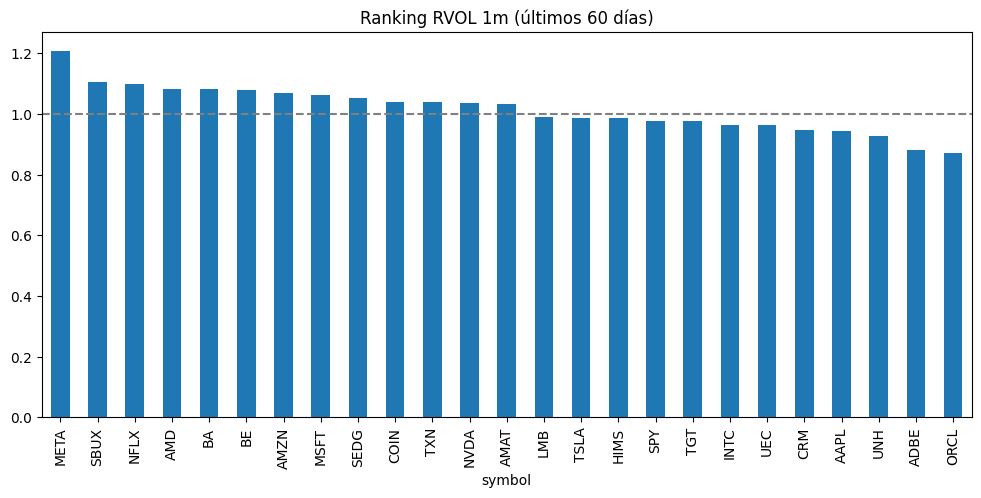

In [38]:
# Gráfico de barras del RVOL medio por símbolo
ranking_rvol["RVOL_1m_mean"].plot(kind="bar", figsize=(12,5))
plt.axhline(1, linestyle="--", color="gray")
plt.title("Ranking RVOL 1m (últimos 60 días)")
plt.show()



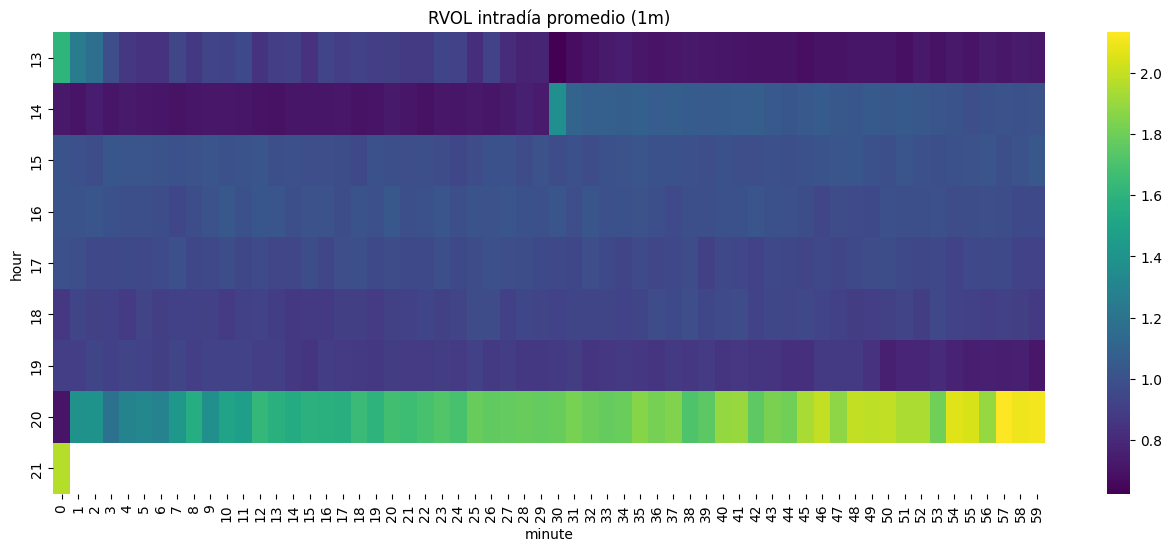

In [40]:
import seaborn as sns

#Heatmap de RVOL medio por hora y minuto
pivot_rvol = df_eval.pivot_table(
    index="hour",
    columns="minute",
    values="rvol_1m",
    aggfunc="mean"
)

plt.figure(figsize=(16,6))
sns.heatmap(pivot_rvol, cmap="viridis")
plt.title("RVOL intradía promedio (1m)")
plt.show()



In [41]:
# EJEMPLO de score combinado
ranking_rvol["score"] = (
    ranking_rvol["RVOL_1m_mean"] * 0.4 +
    df_5m.groupby("symbol")["rvol_5m"].mean() * 0.3 +
    df_15m.groupby("symbol")["rvol_15m"].mean() * 0.2 +
    daily_vol.groupby("symbol")["rvol_daily"].mean() * 0.1
)

ranking_rvol.sort_values("score", ascending=False)
ranking_rvol.head(10)


,RVOL_1m_mean,score
symbol,,
META,1.209093,1.130881
SBUX,1.105170,1.077430
NFLX,1.100609,1.073249
AMD,1.082465,1.064048
BA,1.081501,1.060591
BE,1.080157,1.070862
AMZN,1.069701,1.051953
MSFT,1.061769,1.049437
SEDG,1.052697,1.062673


In [42]:
#METRICA DE VOLATIVIDAD 
# Ventanas en número de velas
WINDOW_VOL_1M  = 20    # 20 minutos
WINDOW_VOL_5M  = 12    # 12*5m = 1 hora
WINDOW_VOL_15M = 8     # 8*15m = 2 horas
WINDOW_VOL_DAY = 390   # para 1m equivale a 390 velas ≈ 1 día completo

# Retornos porcentuales por minuto
df_1m["ret_1m"] = df_1m.groupby("symbol")["close"].pct_change()

# Volatilidad rolling en 1m
df_1m["vol_1m"] = (
    df_1m.groupby("symbol")["ret_1m"]
         .transform(lambda x: x.rolling(WINDOW_VOL_1M, min_periods=5).std())
)

# Retornos en 5m
df_5m["ret_5m"] = df_5m.groupby("symbol")["close"].pct_change()

df_5m["vol_5m"] = (
    df_5m.groupby("symbol")["ret_5m"]
         .transform(lambda x: x.rolling(WINDOW_VOL_5M, min_periods=3).std())
)


# Resample de df_1m a 15 minutos
df_15m = (
    df_1m.set_index("timestamp")
         .groupby("symbol")
         .resample("15T")
         .agg({"close":"last"})
         .reset_index()
         .sort_values(["symbol", "timestamp"])
)

df_15m["ret_15m"] = df_15m.groupby("symbol")["close"].pct_change()

df_15m["vol_15m"] = (
    df_15m.groupby("symbol")["ret_15m"]
          .transform(lambda x: x.rolling(WINDOW_VOL_15M, min_periods=3).std())
)

# Retornos diarios desde df_1m
daily_returns = (
    df_1m.groupby(["symbol", "date"])["close"]
         .last()
         .groupby("symbol")
         .pct_change()
         .reset_index(name="ret_daily")
)

# Volatilidad diaria rolling (20 días)
daily_returns["vol_daily"] = (
    daily_returns.groupby("symbol")["ret_daily"]
                 .transform(lambda x: x.rolling(20, min_periods=5).std())
)


# Merge daily_vol into 1m data
df_1m = df_1m.merge(
    daily_returns[["symbol", "date", "vol_daily"]],
    on=["symbol", "date"],
    how="left"
)


In [43]:
eval_days = 60
cutoff = df_1m["timestamp"].max() - pd.Timedelta(days=eval_days)

df_eval_vol = df_1m[df_1m["timestamp"] >= cutoff].copy()

vol_ranking = (
    df_eval_vol.groupby("symbol")["vol_1m"]
               .mean()
               .sort_values(ascending=False)
               .to_frame("vol_1m_mean")
)

vol_ranking.head()


,vol_1m_mean
symbol,
BE,0.002800
UEC,0.002251
SEDG,0.002218
HIMS,0.001823
LMB,0.001525


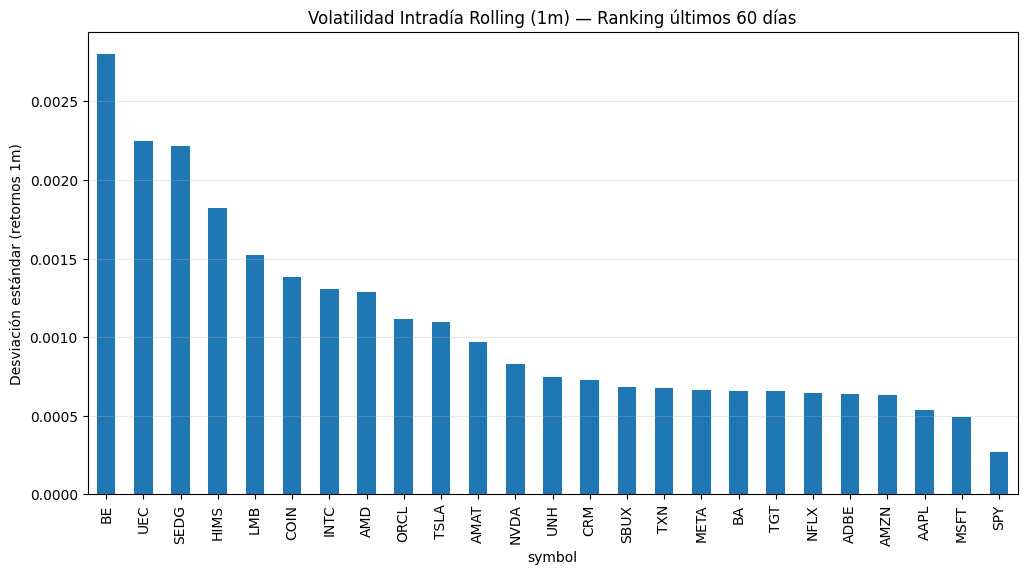

In [44]:
plt.figure(figsize=(12,6))
vol_ranking["vol_1m_mean"].plot(kind="bar")
plt.title("Volatilidad Intradía Rolling (1m) — Ranking últimos 60 días")
plt.ylabel("Desviación estándar (retornos 1m)")
plt.grid(axis="y", alpha=0.3)
plt.show()


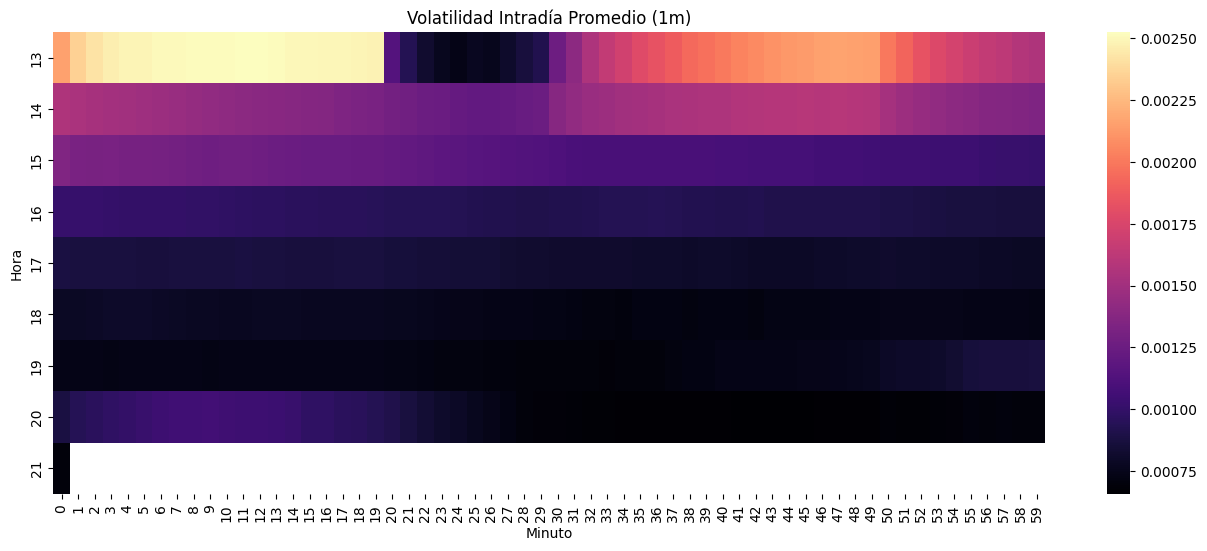

In [45]:
pivot_vol = df_eval_vol.pivot_table(
    index="hour",
    columns="minute",
    values="vol_1m",
    aggfunc="mean"
)

plt.figure(figsize=(16,6))
sns.heatmap(pivot_vol, cmap="magma")
plt.title("Volatilidad Intradía Promedio (1m)")
plt.xlabel("Minuto")
plt.ylabel("Hora")
plt.show()


Un spike es una vela que rompe la dinámica previa del precio o del volumen.

El bot necesita detectar:

✔ Spikes de retorno (momentum explosivo)
✔ Spikes de volatilidad (velas inusualmente grandes)
✔ Spikes de volumen (entrada de flujo institucional)

Estas señales anticipan rupturas, reversals o microtendencias.

Vamos a implementar:
 Spike Types
Spike de retorno​
Spike de volumen:
Spike combinado

Default recomendado:
k = 2.5 (umbral moderado–agresivo usado en ML intradía

In [46]:
#METRICA: 3 SPIKES POR HORA 

#Retornos intradia
df_1m["ret_1m"] = df_1m.groupby("symbol")["close"].pct_change()


#PARAMETROS SPIKES
K_SPIKE = 2.5
WINDOW_SPIKE = 60         # 60 velas = 1 hora
MIN_PERIODS_SPIKE = 20

#SPIKE DE RETORNOS 1M
df_1m["ret_mean"] = (
    df_1m.groupby("symbol")["ret_1m"]
         .transform(lambda x: x.rolling(WINDOW_SPIKE,
                                        min_periods=MIN_PERIODS_SPIKE).mean())
)

df_1m["ret_std"] = (
    df_1m.groupby("symbol")["ret_1m"]
         .transform(lambda x: x.rolling(WINDOW_SPIKE,
                                        min_periods=MIN_PERIODS_SPIKE).std())
)

df_1m["spike_ret"] = (
    (df_1m["ret_1m"] - df_1m["ret_mean"]).abs() > (K_SPIKE * df_1m["ret_std"])
).astype(int)


#SPIKES DE VOLUMEN
df_1m["vol_mean"] = (
    df_1m.groupby("symbol")["volume"]
         .transform(lambda x: x.rolling(WINDOW_SPIKE,
                                        min_periods=MIN_PERIODS_SPIKE).mean())
)

df_1m["vol_std"] = (
    df_1m.groupby("symbol")["volume"]
         .transform(lambda x: x.rolling(WINDOW_SPIKE,
                                        min_periods=MIN_PERIODS_SPIKE).std())
)

df_1m["spike_vol"] = (
    (df_1m["volume"] - df_1m["vol_mean"]) > (K_SPIKE * df_1m["vol_std"])
).astype(int)


#SPIKE COMBINADO
df_1m["spike_combo"] = (
    (df_1m["spike_ret"] == 1) & (df_1m["spike_vol"] == 1)
).astype(int)


#RANKING DE LOS ULTIMOS 60 DÍAS
cutoff = df_1m["timestamp"].max() - pd.Timedelta(days=60)

df_eval = df_1m[df_1m["timestamp"] >= cutoff]

spike_ranking = (
    df_eval.groupby("symbol")["spike_combo"]
           .sum()
           .sort_values(ascending=False)
           .to_frame("total_spikes")
)
spike_ranking.head()


,total_spikes
symbol,
LMB,245
TSLA,173
SBUX,165
HIMS,164
SEDG,146


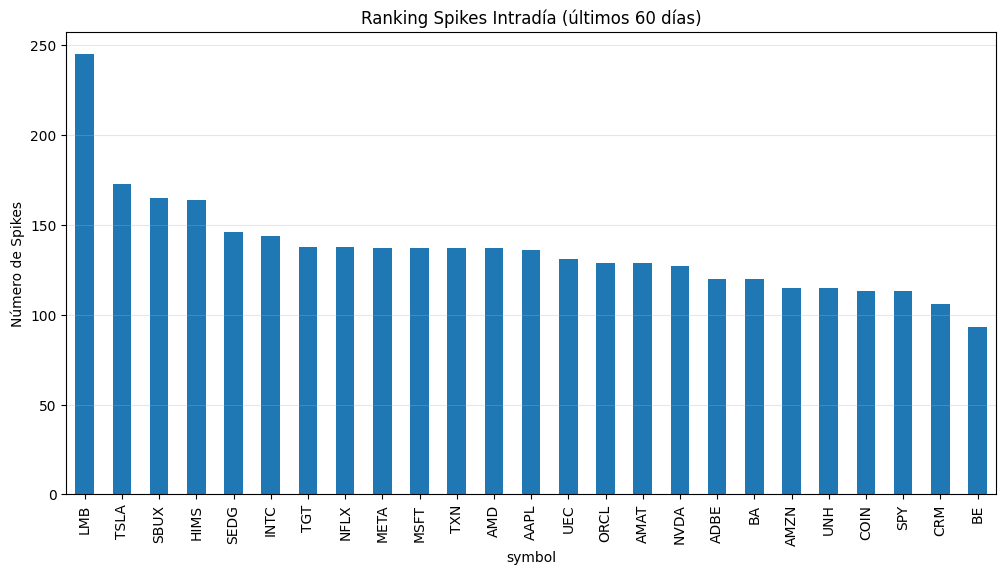

In [47]:
spike_ranking["total_spikes"].plot(kind="bar", figsize=(12,6))
plt.title("Ranking Spikes Intradía (últimos 60 días)")
plt.ylabel("Número de Spikes")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [48]:
#RETORNO INTRADIA PROMEDIO
if "ret_1m" not in df_1m.columns:
    df_1m["ret_1m"] = df_1m.groupby("symbol")["close"].pct_change()


#Retorno promedio por minuto 
ret_minute_pattern = (
    df_1m.groupby(["symbol", "hour", "minute"])["ret_1m"]
         .mean()
         .reset_index()
         .rename(columns={"ret_1m": "ret_mean_1m"})
)

#Retorno promedio por hora
ret_hour_pattern = (
    df_1m.groupby(["symbol", "hour"])["ret_1m"]
         .mean()
         .reset_index()
         .rename(columns={"ret_1m": "ret_mean_hour"})
)

# Retorno intradia total promedio por activo 
intraday_return = (
    df_1m.groupby(["symbol", "date"])["close"]
         .agg(["first", "last"])
)

intraday_return["ret_intraday"] = (
    (intraday_return["last"] / intraday_return["first"]) - 1
)

ret_daily_mean = (
    intraday_return.groupby("symbol")["ret_intraday"]
                   .mean()
                   .reset_index()
                   .rename(columns={"ret_intraday": "ret_mean_intraday"})
)


In [49]:
#ESTABILIDAD DEL PATRÓN
#Esto mide si el patrón horario de un activo se repite día tras día.
#Creamos tablas hora/minuto → retorno del día
#Comparamos cada día con los días anteriores vía correlación

pivot_daily_patterns = df_1m.pivot_table(
    index=["symbol", "date"],
    columns=["hour", "minute"],
    values="ret_1m"
)

#Calcular estabilidad del patron (correlacion diaria promedio)
stability_scores = []

for symbol, group in pivot_daily_patterns.groupby(level=0):
    g = group.droplevel(0)
    corr = g.T.corr().mean().mean()
    stability_scores.append([symbol, corr])

stability_scores = pd.DataFrame(stability_scores, columns=["symbol", "pattern_stability"])



In [50]:
#Ranking final por retorno intradia 
ret_ranking = (
    ret_daily_mean
    .merge(stability_scores, on="symbol", how="left")
    .sort_values("ret_mean_intraday", ascending=False)
)

ret_ranking



,symbol,ret_mean_intraday,pattern_stability
6,BE,4.838479e-03,0.003016
9,HIMS,3.244980e-03,0.003118
11,LMB,1.694848e-03,0.003016
14,NFLX,1.346355e-03,0.003162
0,AAPL,8.564074e-04,0.004578
18,SEDG,8.525053e-04,0.002745
2,AMAT,7.009031e-04,0.003164
16,ORCL,5.904121e-04,0.004689
15,NVDA,3.508864e-04,0.015514
19,SPY,3.091015e-04,0.011176


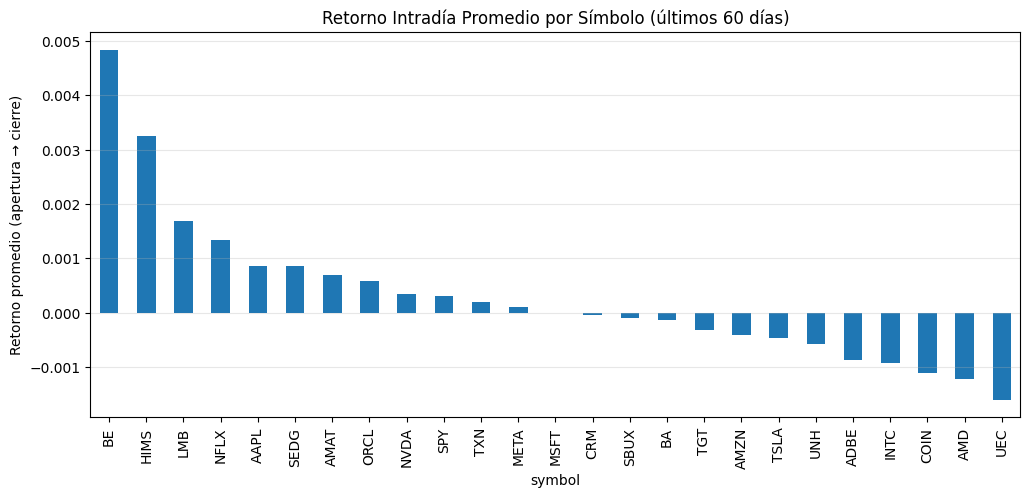

In [51]:
plt.figure(figsize=(12,5))
ret_ranking.set_index("symbol")["ret_mean_intraday"].plot(kind="bar")
plt.title("Retorno Intradía Promedio por Símbolo (últimos 60 días)")
plt.ylabel("Retorno promedio (apertura → cierre)")
plt.grid(axis="y", alpha=0.3)
plt.show()


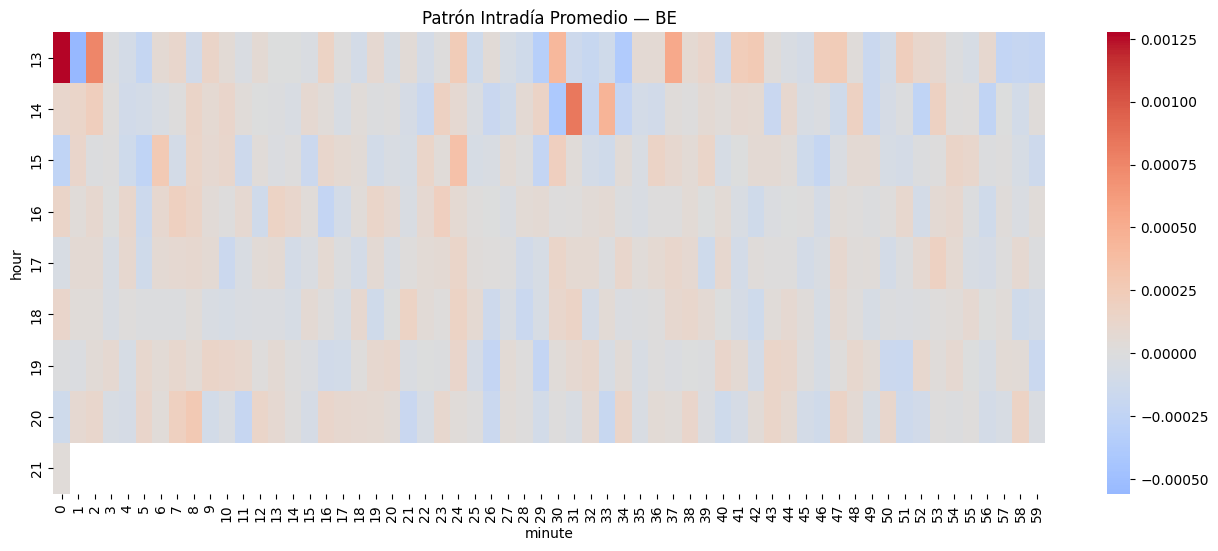

In [52]:
#Heatmap del patrón horario promedio (para visualizar consistencia)

example_symbol = ret_ranking["symbol"].iloc[0]   # top 1 del ranking

df_symbol = df_1m[df_1m["symbol"] == example_symbol]

pivot_hourly = df_symbol.pivot_table(
    index="hour",
    columns="minute",
    values="ret_1m",
    aggfunc="mean"
)

plt.figure(figsize=(16,6))
sns.heatmap(pivot_hourly, cmap="coolwarm", center=0)
plt.title(f"Patrón Intradía Promedio — {example_symbol}")
plt.show()


In [53]:
#CONTINUAMOS CON ESTABILIDAD DEL PATRON HORARIO 

#Creamos matriz intradia por dia 
pattern_matrix = df_1m.pivot_table(
    index=["symbol", "date"],
    columns=["hour", "minute"],
    values="ret_1m",
    aggfunc="mean"
)

"""Cálculo del índice de ESTABILIDAD
Para cada símbolo:
tomamos todos los días del symbol
calculamos la correlación día-día
hacemos la media de la matriz de correlación
evitamos correlaciones consigo mismo
damos un score entre -1 y 1 (deberia de ser > 0 para activos buenos)

Valor	Interpretación
> 0.50	Muy estable, excelente para ML intradía
0.30 – 0.50	Moderadamente estable, usable
0.10 – 0.30	Inestable, ruidoso
< 0.10	Patrón casi aleatorio → mal para intradía """



stability_list = []

for symbol, group in pattern_matrix.groupby(level=0):
    g = group.droplevel(0)   # elimina "symbol" del índice
    
    # matriz de correlaciones entre días
    corr_matrix = g.T.corr()
    
    # eliminar diagonal (autocorrelación)
    corr_no_diag = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    
    # promedio de la matriz sin diagonal
    stability_score = corr_no_diag.stack().mean()
    
    stability_list.append([symbol, stability_score])

pattern_stability = pd.DataFrame(stability_list,
                                 columns=["symbol", "pattern_stability"])

stability_rank = (
    pattern_stability
    .sort_values("pattern_stability", ascending=False)
    .reset_index(drop=True)
)

stability_rank


,symbol,pattern_stability
0,NVDA,0.013537
1,AMZN,0.010877
2,AMD,0.009751
3,SPY,0.009191
4,COIN,0.006283
5,TSLA,0.005901
6,UEC,0.005266
7,MSFT,0.004210
8,META,0.003062
9,ORCL,0.002691


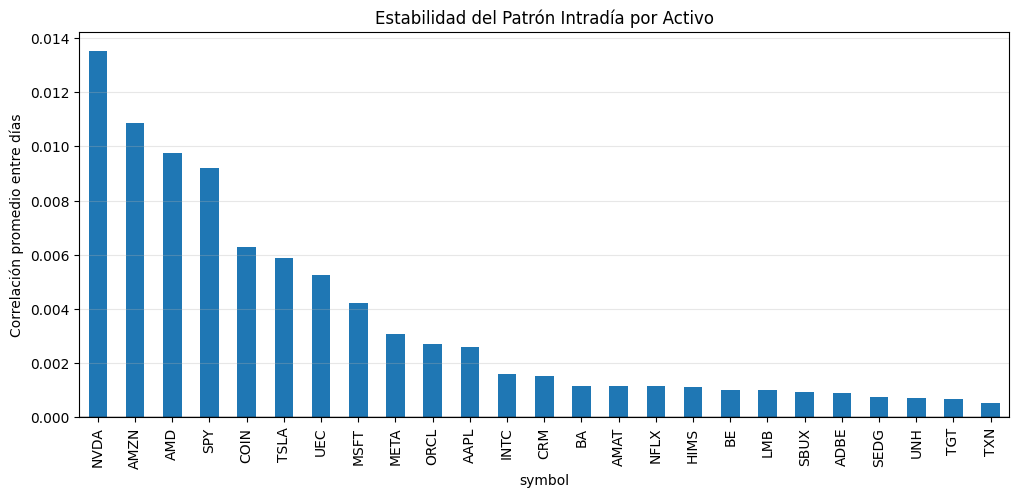

In [54]:
plt.figure(figsize=(12,5))
stability_rank.set_index("symbol")["pattern_stability"].plot(kind="bar")
plt.axhline(0, color="k", linewidth=1)
plt.title("Estabilidad del Patrón Intradía por Activo")
plt.ylabel("Correlación promedio entre días")
plt.grid(axis="y", alpha=0.3)
plt.show()


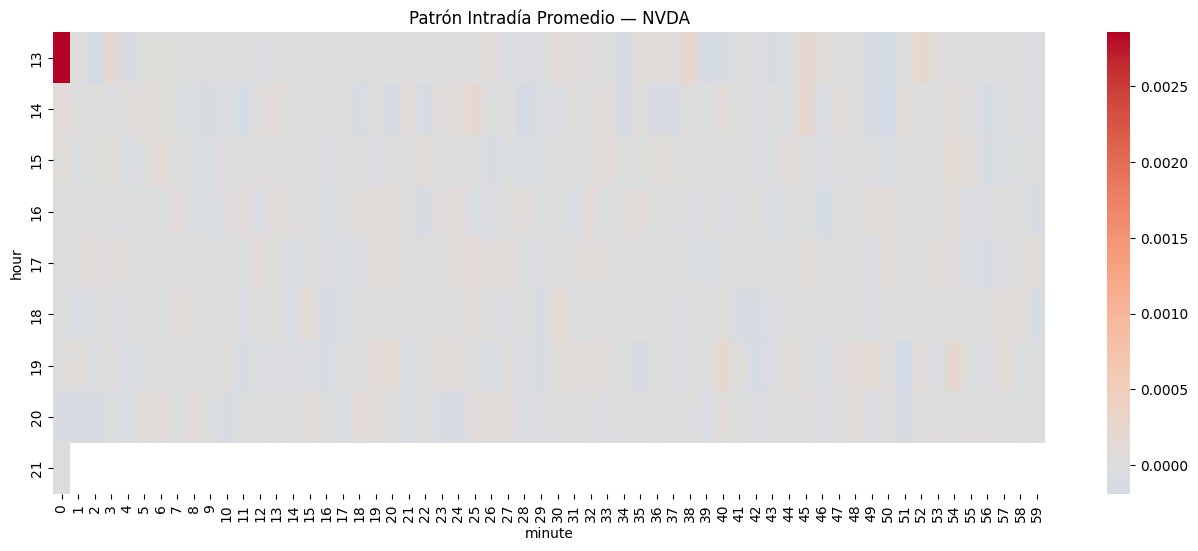

In [55]:
#PATRON INTRDIA PROMEDIO 
symbol_top = stability_rank.iloc[0]["symbol"]

df_sym = df_1m[df_1m["symbol"] == symbol_top]

pivot_heatmap = df_sym.pivot_table(
    index="hour",
    columns="minute",
    values="ret_1m",
    aggfunc="mean"
)

plt.figure(figsize=(16,6))
sns.heatmap(pivot_heatmap, cmap="coolwarm", center=0)
plt.title(f"Patrón Intradía Promedio — {symbol_top}")
plt.show()


In [56]:
#LIQUIDEZ REAL
# Ventana en número de velas / días
WINDOW_LIQ_1M   = 60    # 60 velas de 1m ≈ 1 hora
WINDOW_LIQ_5M   = 24    # 24 velas de 5m ≈ 2 horas
WINDOW_LIQ_DAY  = 20    # 20 días para liquidez diaria media
MIN_PERIODS_LIQ = 10    # mínimo de observaciones para considerar el valor

#Volumen de dolares por minuto 
df_1m["dollar_vol_1m"] = df_1m["close"] * df_1m["volume"]


#Media de USD/min en la ultima hr desde df1m
df_1m["liq_1m"] = (
    df_1m
    .groupby("symbol")["dollar_vol_1m"]
    .transform(lambda x: x.rolling(WINDOW_LIQ_1M,
                                   min_periods=MIN_PERIODS_LIQ).mean())
)

#Volumen de dolares df 5m
df_5m["dollar_vol_5m"] = df_5m["close"] * df_5m["volume"]

df_5m["liq_5m"] = (
    df_5m
    .groupby("symbol")["dollar_vol_5m"]
    .transform(lambda x: x.rolling(WINDOW_LIQ_5M,
                                   min_periods=MIN_PERIODS_LIQ).mean())
)

#Liquidez diaria (USD/día) y su media rolling
daily_dollar_vol = (
    df_1m.groupby(["symbol", "date"])["dollar_vol_1m"]
         .sum()
         .reset_index()
         .sort_values(["symbol", "date"])
)

daily_dollar_vol["liq_daily"] = daily_dollar_vol["dollar_vol_1m"]

daily_dollar_vol["liq_daily_mean"] = (
    daily_dollar_vol
    .groupby("symbol")["liq_daily"]
    .transform(lambda x: x.rolling(WINDOW_LIQ_DAY,
                                   min_periods=5).mean())
)


In [57]:
#Ranking de liquidez real promedio en los últimos 60 días
eval_days = 60
cutoff_liq = df_1m["timestamp"].max() - pd.Timedelta(days=eval_days)

df_eval_liq = df_1m[df_1m["timestamp"] >= cutoff_liq].copy()

liq_ranking = (
    df_eval_liq.groupby("symbol")["liq_1m"]
               .mean()
               .dropna()
               .sort_values(ascending=False)
               .to_frame("liq_1m_mean")
)

liq_ranking.sort_values("liq_1m_mean", ascending=False).head(10)


,liq_1m_mean
symbol,
SPY,9.456460e+07
TSLA,6.922200e+07
NVDA,5.911575e+07
AMD,2.567772e+07
META,2.046374e+07
AAPL,1.945190e+07
AMZN,1.880008e+07
MSFT,1.584754e+07
ORCL,1.104839e+07


In [58]:
#pensar di dejar este -----------------------------------    <----------------------------
# umbral en percentil 30-- para filtrar activos muy ilíquidos
threshold = liq_ranking["liq_1m_mean"].quantile(0.3)

liq_ranking["tradable_by_liquidity"] = liq_ranking["liq_1m_mean"] > threshold

liq_ranking

#podria usar para filtar tradable_symbols = liq_ranking[liq_ranking["tradable_by_liquidity"]].index.tolist()


,liq_1m_mean,tradable_by_liquidity
symbol,,
SPY,9.456460e+07,True
TSLA,6.922200e+07,True
NVDA,5.911575e+07,True
AMD,2.567772e+07,True
META,2.046374e+07,True
AAPL,1.945190e+07,True
AMZN,1.880008e+07,True
MSFT,1.584754e+07,True
ORCL,1.104839e+07,True


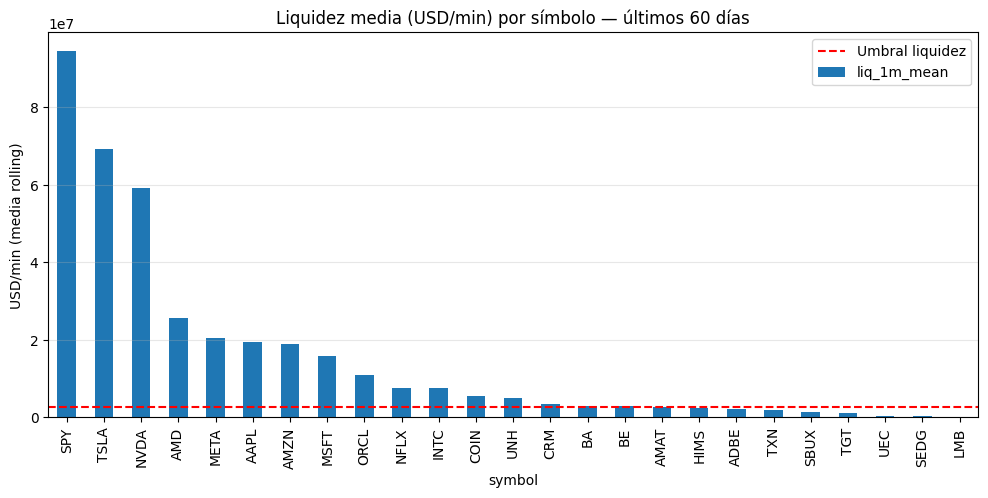

In [59]:
plt.figure(figsize=(12,5))
liq_ranking["liq_1m_mean"].plot(kind="bar")
plt.axhline(threshold, color="red", linestyle="--", label="Umbral liquidez")
plt.title("Liquidez media (USD/min) por símbolo — últimos 60 días")
plt.ylabel("USD/min (media rolling)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


In [60]:
#METRICAS COMPLEMENTARIAS 
#volatidad 5m
df_5m["ret_5m"] = df_5m.groupby("symbol")["close"].pct_change()

df_5m["vol_5m"] = (
    df_5m.groupby("symbol")["ret_5m"]
         .transform(lambda x: x.rolling(12, min_periods=5).std())
)

df_15m = (
    df_1m.set_index("timestamp")
         .groupby("symbol")
         .resample("15T")
         .agg({
             "open": "first",
             "high": "max",
             "low":  "min",
             "close": "last",
             "volume": "sum"
         })
         .dropna()
         .reset_index()
)



#Volatilidad 15m
df_15m["close"] = df_15m.groupby("symbol")["volume"].transform(lambda x: x) 
df_15m["ret_15m"] = df_15m.groupby("symbol")["close"].pct_change()

df_15m["vol_15m"] = (
    df_15m.groupby("symbol")["ret_15m"]
          .transform(lambda x: x.rolling(8, min_periods=3).std())
)

#Liquides real 5m 
df_5m["dollar_vol_5m"] = df_5m["close"] * df_5m["volume"]

df_5m["liq_5m"] = (
    df_5m.groupby("symbol")["dollar_vol_5m"]
         .transform(lambda x: x.rolling(24, min_periods=10).mean())
)


# Cálculo de volumen medio 15m por hora del día
df_15m["hour"] = df_15m["timestamp"].dt.hour

WINDOW_DAYS = 20
MIN_PERIODS = 5

df_15m = df_15m.sort_values(["symbol", "timestamp"])

df_15m["mean_vol_15m"] = (
    df_15m.groupby(["symbol", "hour"])["volume"]
          .transform(lambda x: x.rolling(WINDOW_DAYS, min_periods=MIN_PERIODS).mean())
)

df_15m["rvol_15m"] = df_15m["volume"] / df_15m["mean_vol_15m"].replace(0, np.nan)

#Liquidez diaria 
daily_dollar_vol = (
    df_1m.groupby(["symbol", "date"])["dollar_vol_1m"]
          .sum()
          .reset_index()
          .sort_values(["symbol", "date"])
)

daily_dollar_vol["liq_daily_mean"] = (
    daily_dollar_vol.groupby("symbol")["dollar_vol_1m"]
                    .transform(lambda x: x.rolling(20, min_periods=5).mean())
)


#optimizada
pattern_matrix = df_1m.pivot_table(
    index=["symbol", "date"],
    columns=["hour", "minute"],
    values="ret_1m",
    aggfunc="mean"
)

stability_list = []

for symbol, g in pattern_matrix.groupby(level=0):
    g2 = g.droplevel(0)
    corr_matrix = g2.T.corr()
    corr_no_diag = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    stability_score = corr_no_diag.stack().mean()
    stability_list.append([symbol, stability_score])

pattern_stability = pd.DataFrame(stability_list, columns=["symbol", "pattern_stability"])
pattern_stability = pattern_stability.rename(columns={"pattern_stability": "STAB"})



#atr
df_1m["range"] = df_1m["high"] - df_1m["low"]

df_1m = df_1m.sort_values(["symbol", "timestamp"])   # opcional
EVAL_DAYS = 60
cutoff_eval = df_1m["timestamp"].max() - pd.Timedelta(days=EVAL_DAYS)

df_eval = df_1m[df_1m["timestamp"] >= cutoff_eval].copy()


atr_by_symbol = df_eval.groupby("symbol")["range"].mean().reset_index()
atr_by_symbol = atr_by_symbol.rename(columns={"range": "ATR_1m"})


In [61]:
#MATRIZ DE EVALUACION FINAL

#AGREGAR TODAS LAS MÉTRICAS EN df_1m (últimos 60 días)
# Ventana de evaluación final

EVAL_DAYS = 60
cutoff_eval = df_1m["timestamp"].max() - pd.Timedelta(days=EVAL_DAYS)

df_eval = df_1m[df_1m["timestamp"] >= cutoff_eval].copy()

# AGREGACIÓN POR SÍMBOLO
metrics_by_symbol = df_eval.groupby("symbol").agg({

    #  RVOL 
    "rvol_1m": "mean",   # desde df_1m

    #  Volatilidad 
    "vol_1m": "mean",

    #  Spikes 
    "spike_ret": "sum",
    "spike_vol": "sum",
    "spike_combo": "sum",

    #  Retorno intradía medio 
    "ret_1m": "mean",

    #  Liquidez real 1min 
    "liq_1m": "mean",

}).reset_index()

#AGREGAR RVOL_5m, VOL_5m, LIQ_5m (df_5m)
df_5m_eval = df_5m[df_5m["timestamp"] >= cutoff_eval]

metrics_5m = df_5m_eval.groupby("symbol").agg({
    "rvol_5m": "mean",
    "vol_5m": "mean",
    "liq_5m": "mean",
}).reset_index()

metrics_by_symbol = metrics_by_symbol.merge(metrics_5m, on="symbol", how="left")


#AGREGAR RVOL_15m, VOL_15m (df_15m)
df_15m_eval = df_15m[df_15m["timestamp"] >= cutoff_eval]

metrics_15m = df_15m_eval.groupby("symbol").agg({
    "rvol_15m": "mean",
    "vol_15m": "mean",
}).reset_index()

metrics_by_symbol = metrics_by_symbol.merge(metrics_15m, on="symbol", how="left")


#AGREGAR LIQ DAILY
metrics_by_symbol = metrics_by_symbol.merge(
    daily_dollar_vol.groupby("symbol")["liq_daily_mean"].mean().reset_index(),
    on="symbol", how="left"
)
metrics_by_symbol = metrics_by_symbol.rename(columns={"liq_daily_mean": "LIQ_daily"})


#AGREGAR ESTABILIDAD DEL PATRÓN (pattern_stability)
metrics_by_symbol = metrics_by_symbol.merge(
    pattern_stability, on="symbol", how="left"
)

#AGREGAR ATR INTRADÍA                     ojo
df_1m["range"] = df_1m["high"] - df_1m["low"]

atr_by_symbol = df_eval.groupby("symbol")["range"].mean().reset_index()
atr_by_symbol = atr_by_symbol.rename(columns={"range": "ATR_1m"})

metrics_by_symbol = metrics_by_symbol.merge(atr_by_symbol, on="symbol", how="left")


#Renombrar columnas para mayor claridad
metrics_by_symbol = metrics_by_symbol.rename(columns={
    "rvol_1m": "RVOL_1m",
    "rvol_5m": "RVOL_5m",
    #"rvol_15m": "RVOL_15m",

    "vol_1m": "VOL_1m",
    "vol_5m": "VOL_5m",
    "vol_15m": "VOL_15m",

    "spike_ret": "SPIKE_ret",
    "spike_vol": "SPIKE_vol",
    "spike_combo": "SPIKE_combo",

    "ret_1m": "RET_1m",

    "liq_1m": "LIQ_1m",
    "liq_5m": "LIQ_5m",

    # daily already mapped
})




In [62]:
df_15m.head()

,symbol,timestamp,open,high,low,close,volume,ret_15m,vol_15m,hour,mean_vol_15m,rvol_15m
0,AAPL,2023-11-20 13:00:00+00:00,189.68,189.97,189.13,70807.0,70807.0,NaN,NaN,13,NaN,NaN
1,AAPL,2023-11-20 13:15:00+00:00,189.92,190.10,189.86,41258.0,41258.0,-0.417317,NaN,13,NaN,NaN
2,AAPL,2023-11-20 13:30:00+00:00,189.99,190.23,189.99,75500.0,75500.0,0.829948,NaN,13,NaN,NaN
3,AAPL,2023-11-20 13:45:00+00:00,190.23,190.25,190.01,30520.0,30520.0,-0.595762,0.776763,13,NaN,NaN
4,AAPL,2023-11-20 14:00:00+00:00,190.13,190.30,190.12,39873.0,39873.0,0.306455,0.660306,14,NaN,NaN


In [63]:
#Normalización de métricas para scoring final
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_normalize = [
    "RVOL_1m","RVOL_5m","rvol_15m",
    "VOL_1m","VOL_5m","VOL_15m",
    "SPIKE_ret","SPIKE_vol","SPIKE_combo",
    "RET_1m",
    "STAB",
    "LIQ_1m","LIQ_5m","LIQ_daily",
    "ATR_1m"
]

metrics_scaled = metrics_by_symbol.copy()
metrics_scaled[cols_to_normalize] = scaler.fit_transform(
    metrics_by_symbol[cols_to_normalize]
)


In [64]:
#PONDERACION FINAL DE LOS ACTIVOS 
metrics_scaled["SCORE"] = (
    0.10*metrics_scaled["RVOL_1m"]
  + 0.05*metrics_scaled["RVOL_5m"]
  + 0.05*metrics_scaled["RVVOL_15m"] if "RVOL_15m" in metrics_scaled.columns else 0
  + 0.10*metrics_scaled["VOL_1m"]
  + 0.05*metrics_scaled["VOL_5m"]
  + 0.05*metrics_scaled["VOL_15m"]
  + 0.20*metrics_scaled["SPIKE_combo"]
  + 0.10*metrics_scaled["RET_1m"]
  + 0.15*metrics_scaled["STAB"]
  + 0.05*metrics_scaled["LIQ_1m"]
  + 0.05*metrics_scaled["LIQ_5m"]
  + 0.05*metrics_scaled["LIQ_daily"]
  + 0.05*metrics_scaled["ATR_1m"]
)

#RANKING FINAL
ranking_final = metrics_scaled.sort_values(
    "SCORE", ascending=False
).reset_index(drop=True)

ranking_final



,symbol,RVOL_1m,VOL_1m,SPIKE_ret,SPIKE_vol,SPIKE_combo,RET_1m,LIQ_1m,RVOL_5m,VOL_5m,LIQ_5m,rvol_15m,VOL_15m,LIQ_daily,STAB,ATR_1m,SCORE
0,NVDA,0.487959,0.220460,0.000000,0.073864,0.223684,0.522181,0.625040,0.482490,0.230915,0.622916,0.563647,0.332835,0.922776,1.000000,0.213694,0.416410
1,TSLA,0.342569,0.326877,0.088095,0.443182,0.526316,0.393829,0.731939,0.345982,0.312449,0.728820,0.413510,0.186193,0.766831,0.412183,0.731750,0.412060
2,AMD,0.624380,0.402910,0.128571,0.000000,0.289474,1.000000,0.271349,0.612309,0.437265,0.270081,0.628746,0.416488,0.222976,0.708510,0.390814,0.404911
3,SPY,0.316506,0.000000,0.021429,0.767045,0.131579,0.440690,1.000000,0.320675,0.000000,1.000000,0.222250,0.238736,1.000000,0.665410,0.250483,0.344657
4,BE,0.617535,1.000000,0.228571,0.289773,0.000000,0.902101,0.030047,0.581958,1.000000,0.029928,0.733274,1.000000,0.006382,0.035982,0.426113,0.320231
5,LMB,0.350143,0.496152,1.000000,0.579545,1.000000,0.052341,0.000000,0.434397,0.499247,0.000000,0.507083,0.000000,0.000000,0.035944,0.047593,0.287583
6,UEC,0.268682,0.783052,0.228571,0.835227,0.250000,0.452172,0.004014,0.274655,0.783464,0.004002,0.268206,0.170052,0.001786,0.363250,0.000000,0.276176
7,AMZN,0.586516,0.144321,0.176190,0.284091,0.144737,0.451134,0.198601,0.581386,0.150647,0.198391,0.460220,0.297568,0.208249,0.795249,0.175804,0.269243
8,SEDG,0.536077,0.769813,0.369048,0.875000,0.348684,0.558105,0.002768,0.537776,0.734947,0.002758,0.311503,0.228903,0.003129,0.015046,0.058411,0.256331
9,INTC,0.269798,0.410585,0.116667,0.454545,0.335526,0.656637,0.079062,0.274825,0.410055,0.078851,0.011806,0.541267,0.054218,0.080413,0.033686,0.245746


In [65]:
#SELECCIÓN DE ACTIVOS ÓPTIMOS (TOP 3–5)
selected_assets = ranking_final["symbol"].head(3).tolist()
#selected_assets = ranking_final["symbol"].head(5).tolist()

selected_assets


['NVDA', 'TSLA', 'AMD']

In [66]:
ranking_final.to_csv("universe_intraday_final.csv", index=False)


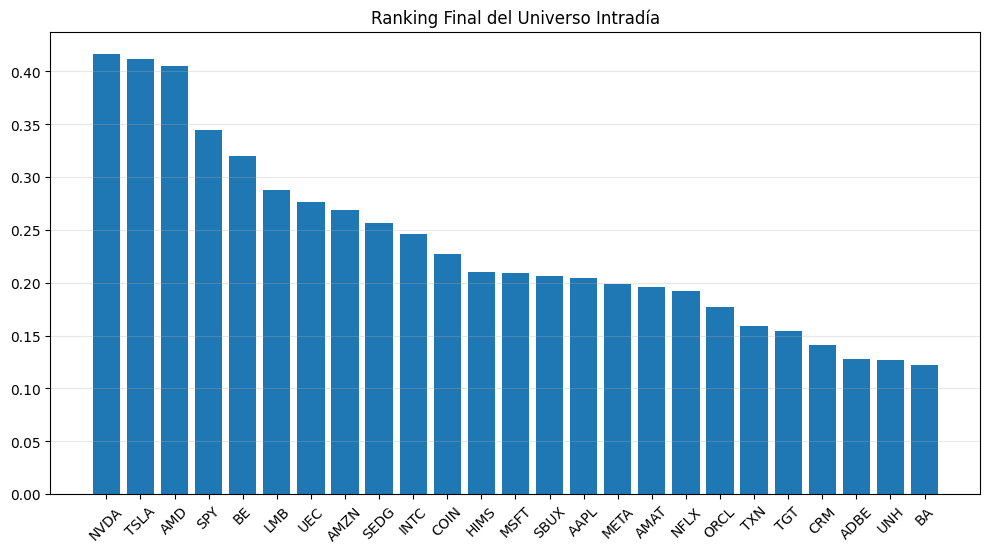

In [67]:
#Ranking 
plt.figure(figsize=(12,6))
plt.bar(ranking_final["symbol"], ranking_final["SCORE"])
plt.title("Ranking Final del Universo Intradía")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


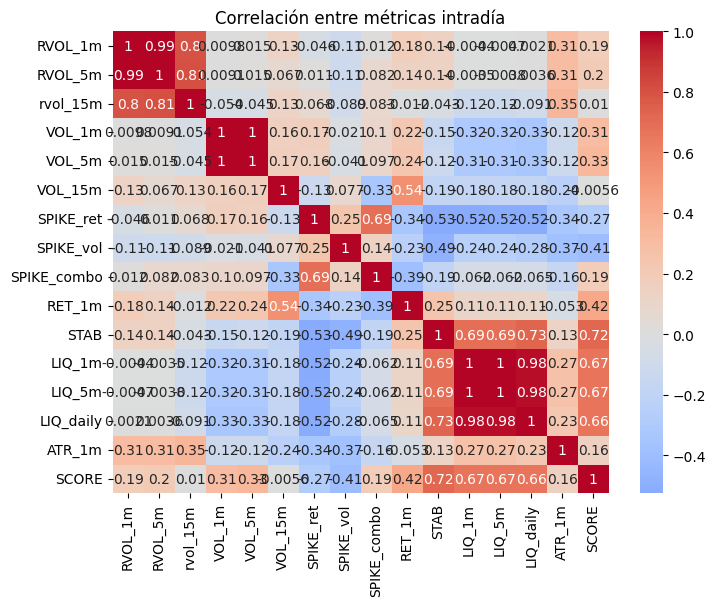

In [68]:
#Heatmap de correlación de métricas
plt.figure(figsize=(8,6))
sns.heatmap(
    ranking_final[cols_to_normalize + ["SCORE"]].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlación entre métricas intradía")
plt.show()


In [69]:
#hay variables que podrían eliminarse por alta correlación- por ejemplo, RVOL_1m y VOL_1m parecen estar muy correlacionadas
#podría considerar eliminar VOL_1m para simplificar el modelo sin perder mucha información, como las de liquidez real LIQ_1m y LIQ_5m también están altamente correlacionadas.
#SCORE tiene liquidez y estabilidad del patrón como las métricas menos correlacionadas con las demás, lo que sugiere que aportan información única al ranking final.

In [70]:
# calcular retornos 5m
df_5m["ret_5m"] = df_5m.groupby("symbol")["close"].pct_change()

# medias y std rolling
df_5m["ret_mean_5m"] = (
    df_5m.groupby("symbol")["ret_5m"]
         .transform(lambda x: x.rolling(200, min_periods=20).mean())
)

df_5m["ret_std_5m"] = (
    df_5m.groupby("symbol")["ret_5m"]
         .transform(lambda x: x.rolling(200, min_periods=20).std())
)

# SPIKE 5m
df_5m["spike_5m"] = (
    (df_5m["ret_5m"] > df_5m["ret_mean_5m"] + 2 * df_5m["ret_std_5m"])
    .astype(int)
)


### Labeling

In [71]:
df_1m = df_1m.sort_values(["symbol", "timestamp"])
df_5m = df_5m.sort_values(["symbol", "timestamp"])


In [72]:
selected_assets = ["TSLA", "NVDA", "AMD"]
df_1m = df_1m[df_1m["symbol"].isin(selected_assets)]
df_5m = df_5m[df_5m["symbol"].isin(selected_assets)]


In [73]:
#LABEL 1M
# RETORNO FUTURO 1M
df_1m["future_return_1m"] = (
    df_1m.groupby("symbol")["close"].shift(-1) / df_1m["close"] - 1
)

# DIRECCIÓN FUTURA (1 = sube, 0 = baja)
df_1m["label_up_1m"] = (df_1m["future_return_1m"] > 0).astype(int)

# SPIKE FUTURO 1M (usando spike_combo actual)
df_1m["future_spike_1m"] = (
    df_1m.groupby("symbol")["spike_combo"].shift(-1).fillna(0).astype(int)
)

# Eliminamos filas sin futuro
df_1m.dropna(subset=["future_return_1m"], inplace=True)

In [74]:
#LABELS 5M
df_5m["ret_mean_5m"] = (
    df_5m.groupby("symbol")["ret_5m"].transform(lambda x: x.rolling(200, min_periods=20).mean())
)

df_5m["ret_std_5m"] = (
    df_5m.groupby("symbol")["ret_5m"].transform(lambda x: x.rolling(200, min_periods=20).std())
)

df_5m["spike_5m"] = (
    (df_5m["ret_5m"] > df_5m["ret_mean_5m"] + 2 * df_5m["ret_std_5m"])
    .astype(int)
)

# Ordenar
df_5m = df_5m.sort_values(["symbol", "timestamp"]).copy()



In [75]:
#===== SPIKES 5 MINUTOS =====

# Confirmar retornos 5m
df_5m["ret_5m"] = df_5m.groupby("symbol")["close"].pct_change()

# Ventana para spikes 5m (200 velas = aprox 3 días de datos)
WINDOW_SPIKES_5M = 200

# Media rolling
df_5m["ret_mean_5m"] = (
    df_5m.groupby("symbol")["ret_5m"]
         .transform(lambda x: x.rolling(WINDOW_SPIKES_5M, min_periods=20).mean())
)

# Std rolling
df_5m["ret_std_5m"] = (
    df_5m.groupby("symbol")["ret_5m"]
         .transform(lambda x: x.rolling(WINDOW_SPIKES_5M, min_periods=20).std())
)

# Spike 5m (retorno extraordinario)
df_5m["spike_5m"] = (
    (df_5m["ret_5m"] > df_5m["ret_mean_5m"] + 2 * df_5m["ret_std_5m"])
    .astype(int)
)

### Feature Engineering completo (variables que alimentan ML)

In [76]:
import numpy as np
import pandas as pd

def add_price_features(df, window_returns=5):
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
    df["ret_1"] = df["close"].pct_change()
    df["ret_3"] = df["close"].pct_change(3)
    df["ret_5"] = df["close"].pct_change(5)
    
    df["momentum_5"] = df["close"] / df["close"].shift(5) - 1
    df["momentum_10"] = df["close"] / df["close"].shift(10) - 1
    
    df["range"] = df["high"] - df["low"]
    df["range_norm"] = df["range"] / df["close"]
    
    return df


def add_volatility_features(df):
    df["vol_rolling_5"] = df.groupby("symbol")["ret_1"].transform(lambda x: x.rolling(5).std())
    df["vol_rolling_15"] = df.groupby("symbol")["ret_1"].transform(lambda x: x.rolling(15).std())
    df["vol_rolling_30"] = df.groupby("symbol")["ret_1"].transform(lambda x: x.rolling(30).std())
    return df


def add_volume_features(df):
    df["vol_change_1"] = df["volume"].pct_change()
    df["vol_change_5"] = df["volume"].pct_change(5)
    df["vol_norm"] = df["volume"] / df["volume"].rolling(20).mean()
    return df


def add_liquidity_features(df):
    df["dollar_vol"] = df["close"] * df["volume"]
    df["liq_norm"] = df["dollar_vol"] / df["dollar_vol"].rolling(20).mean()
    df["liq_zscore"] = (df["dollar_vol"] - df["dollar_vol"].rolling(20).mean()) / df["dollar_vol"].rolling(20).std()
    return df


def add_spike_features(df, spike_col):
    df["spike_lag_1"] = df[spike_col].shift(1)
    df["spike_lag_3"] = df[spike_col].shift(3)

    df["spike_density_10"] = (
        df.groupby("symbol")[spike_col]
          .transform(lambda x: x.rolling(10).sum())
    )

    df["spike_density_30"] = (
        df.groupby("symbol")[spike_col]
          .transform(lambda x: x.rolling(30).sum())
    )
    
    return df




In [77]:
# ========= FEATURES 1M =========

df_1m_feat = df_1m.copy()
df_1m_feat = df_1m_feat.sort_values(["symbol", "timestamp"])

# Precio
df_1m_feat = df_1m_feat.groupby("symbol", group_keys=False).apply(add_price_features)

# Volatilidad
df_1m_feat = df_1m_feat.groupby("symbol", group_keys=False).apply(add_volatility_features)

# Volumen
df_1m_feat = df_1m_feat.groupby("symbol", group_keys=False).apply(add_volume_features)

# Liquidez
df_1m_feat = df_1m_feat.groupby("symbol", group_keys=False).apply(add_liquidity_features)

# Spikes 1m (usa spike_combo)
df_1m_feat = df_1m_feat.groupby("symbol", group_keys=False).apply(
    lambda x: add_spike_features(x, "spike_combo")
)


In [78]:
# ========= FEATURES 5M =========

df_5m_feat = df_5m.copy()
df_5m_feat = df_5m_feat.sort_values(["symbol", "timestamp"])

# Precio
df_5m_feat = df_5m_feat.groupby("symbol", group_keys=False).apply(add_price_features)

# Volatilidad
df_5m_feat = df_5m_feat.groupby("symbol", group_keys=False).apply(add_volatility_features)

# Volumen
df_5m_feat = df_5m_feat.groupby("symbol", group_keys=False).apply(add_volume_features)

# Liquidez
df_5m_feat = df_5m_feat.groupby("symbol", group_keys=False).apply(add_liquidity_features)

# Spikes 5m (usa spike_5m)
df_5m_feat = df_5m_feat.groupby("symbol", group_keys=False).apply(
    lambda x: add_spike_features(x, "spike_5m")
)


In [79]:
#Cuantos nulos tenemos por df , y porcentuales 

print(df_1m_feat.shape)
print(df_5m_feat.shape)

print (df_5m_feat["mean_vol_5m"].isna().mean())
print(df_5m_feat["rvol_5m"].isna().mean())



(724383, 50)
(365205, 42)
0.0031872509960159364
0.0031872509960159364


In [80]:
#Eliminamos nulos
df_1m_feat = df_1m_feat.dropna()
df_5m_feat = df_5m_feat.dropna()

In [88]:
#ANÁLISIS DE CORRELACIONES Y REDUCCIÓN DE FEATURES

corr_with_label_1m = df_1m_feat.corr(numeric_only=True)["label_up_1m"].sort_values(ascending=False)
corr_with_label_1m

label_up_1m         1.000000
future_return_1m    0.519098
liq_1m              0.013706
dollar_vol_1m       0.013235
dollar_vol          0.013235
transactions        0.013170
range_norm          0.012852
volume              0.011520
mean_vol_1m         0.011257
range               0.010518
vol_mean            0.010376
rvol_1m             0.008118
vol_rolling_5       0.007782
vol_rolling_15      0.005904
vol_1m              0.005539
high                0.004990
open                0.004978
vwap                0.004977
low                 0.004955
close               0.004941
spike_ret           0.004318
ret_std             0.004120
vol_rolling_30      0.004065
vol_std             0.003761
vol_norm            0.003336
liq_norm            0.003313
spike_combo         0.002739
spike_density_10    0.002075
liq_zscore          0.001862
spike_lag_3         0.001487
spike_density_30    0.001036
spike_lag_1         0.000853
vol_daily           0.000812
vol_change_5        0.000744
spike_vol     

In [87]:
df_1m_feat.head()

,timestamp,symbol,open,high,low,close,volume,vwap,transactions,date,...,vol_change_1,vol_change_5,vol_norm,dollar_vol,liq_norm,liq_zscore,spike_lag_1,spike_lag_3,spike_density_10,spike_density_30
726785,2023-11-28 13:00:00+00:00,AMD,122.49,122.7491,122.3401,122.40,7839.0,122.5252,107.0,2023-11-28,...,-0.896085,-0.957819,0.055093,959493.60,0.054902,-1.430495,0.0,0.0,0.0,2.0
726786,2023-11-28 13:01:00+00:00,AMD,122.21,122.6000,122.1100,122.11,5629.0,122.3330,111.0,2023-11-28,...,-0.281924,-0.966953,0.040107,687357.19,0.039875,-1.396316,0.0,0.0,0.0,2.0
726787,2023-11-28 13:02:00+00:00,AMD,122.50,122.6500,122.0800,122.57,3633.0,122.4366,65.0,2023-11-28,...,-0.354592,-0.984326,0.026529,445296.81,0.026476,-1.330632,0.0,0.0,0.0,2.0
726788,2023-11-28 13:03:00+00:00,AMD,122.39,122.3900,122.3900,122.39,562.0,122.4025,6.0,2023-11-28,...,-0.845307,-0.998641,0.004196,68783.18,0.004181,-1.289418,0.0,0.0,0.0,2.0
726789,2023-11-28 13:04:00+00:00,AMD,122.39,122.4000,122.3900,122.40,2074.0,122.4010,17.0,2023-11-28,...,2.690391,-0.972507,0.015965,253857.60,0.015912,-1.193964,0.0,0.0,0.0,2.0


In [90]:
corr_with_label_5m = df_5m_feat.corr(numeric_only=True)["spike_5m"].sort_values(ascending=False)
corr_with_label_5m


spike_5m            1.000000
ret_1               0.444474
ret_5m              0.444474
log_ret             0.443085
spike_density_10    0.360192
range_norm          0.300771
ret_3               0.249605
liq_norm            0.228227
vol_norm            0.226454
vol_rolling_5       0.215388
range               0.201385
spike_density_30    0.193104
ret_5               0.192740
momentum_5          0.192740
liq_zscore          0.166001
vol_5m              0.154478
vol_change_5        0.148698
dollar_vol          0.147930
dollar_vol_5m       0.147930
transactions        0.136666
vol_rolling_15      0.135588
momentum_10         0.131504
volume              0.123416
rvol_5m             0.101083
vol_change_1        0.089069
vol_rolling_30      0.081595
mean_vol_5m         0.077783
spike_lag_1         0.055812
spike_lag_3         0.037724
ret_mean_5m         0.003380
close              -0.000965
high               -0.001062
vwap               -0.001679
low                -0.002586
open          

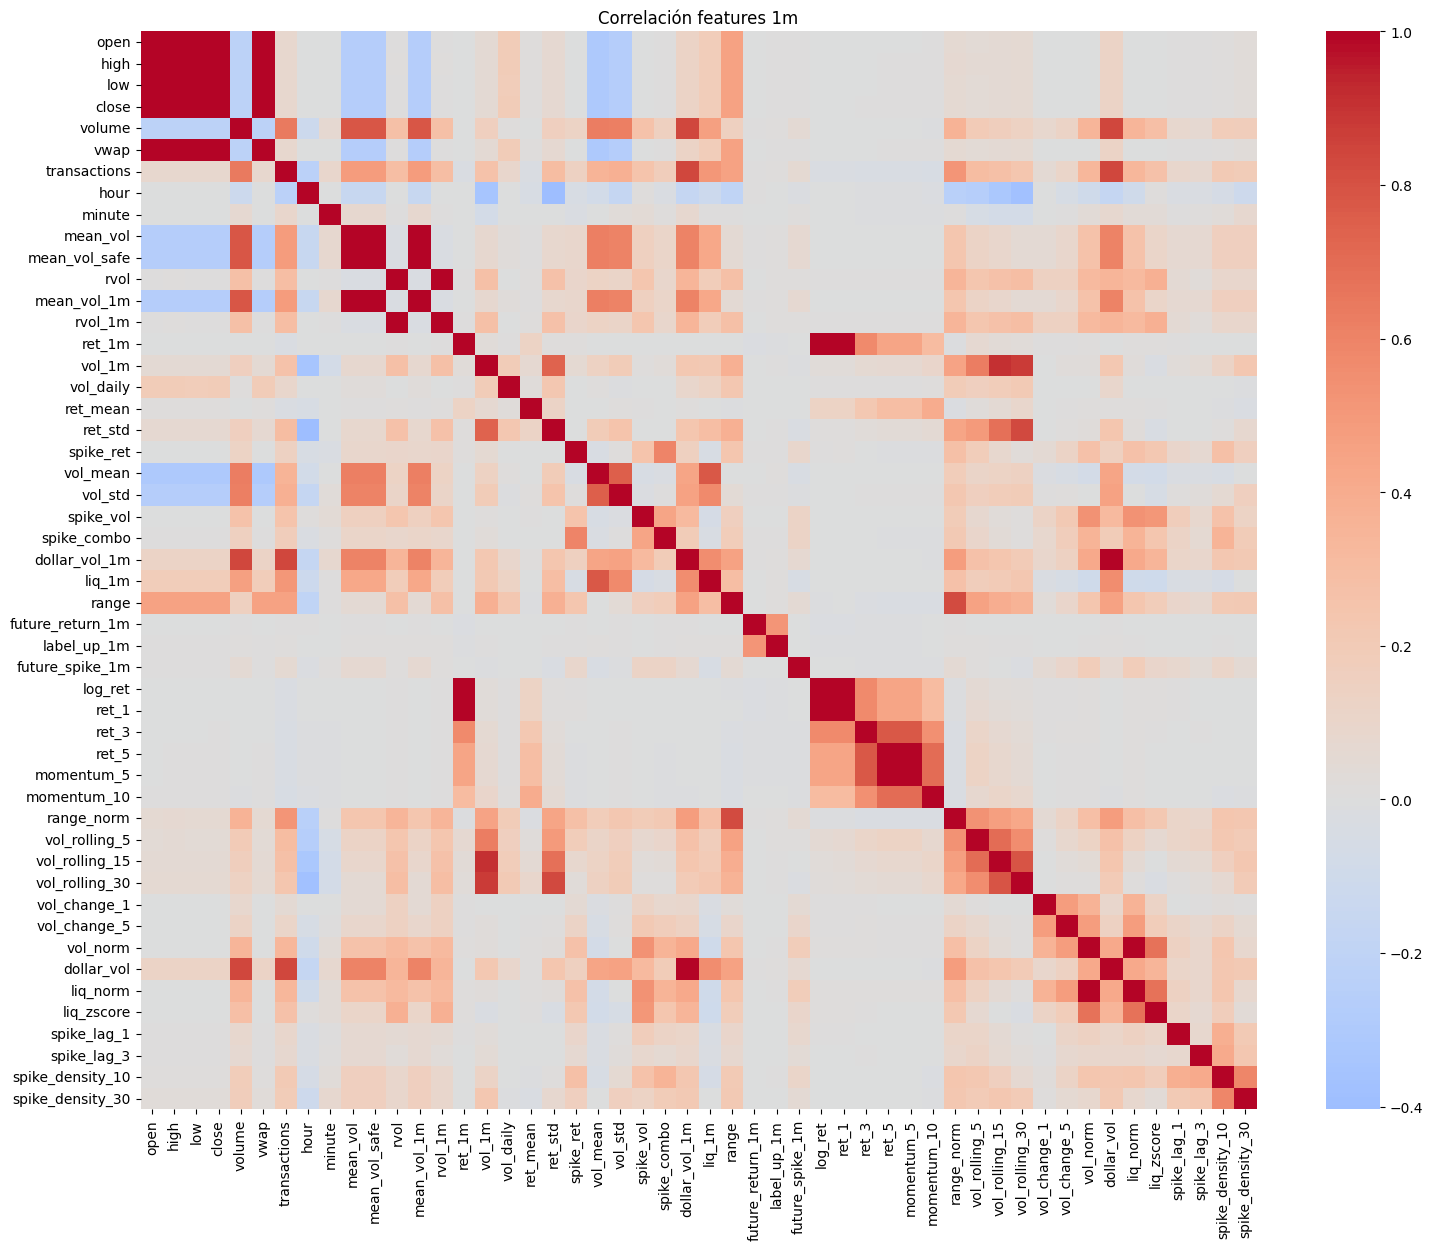

In [ ]:
#Heatmap correlación features 1m
plt.figure(figsize=(18,14))
sns.heatmap(df_1m_feat.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlación features 1m")
plt.show()


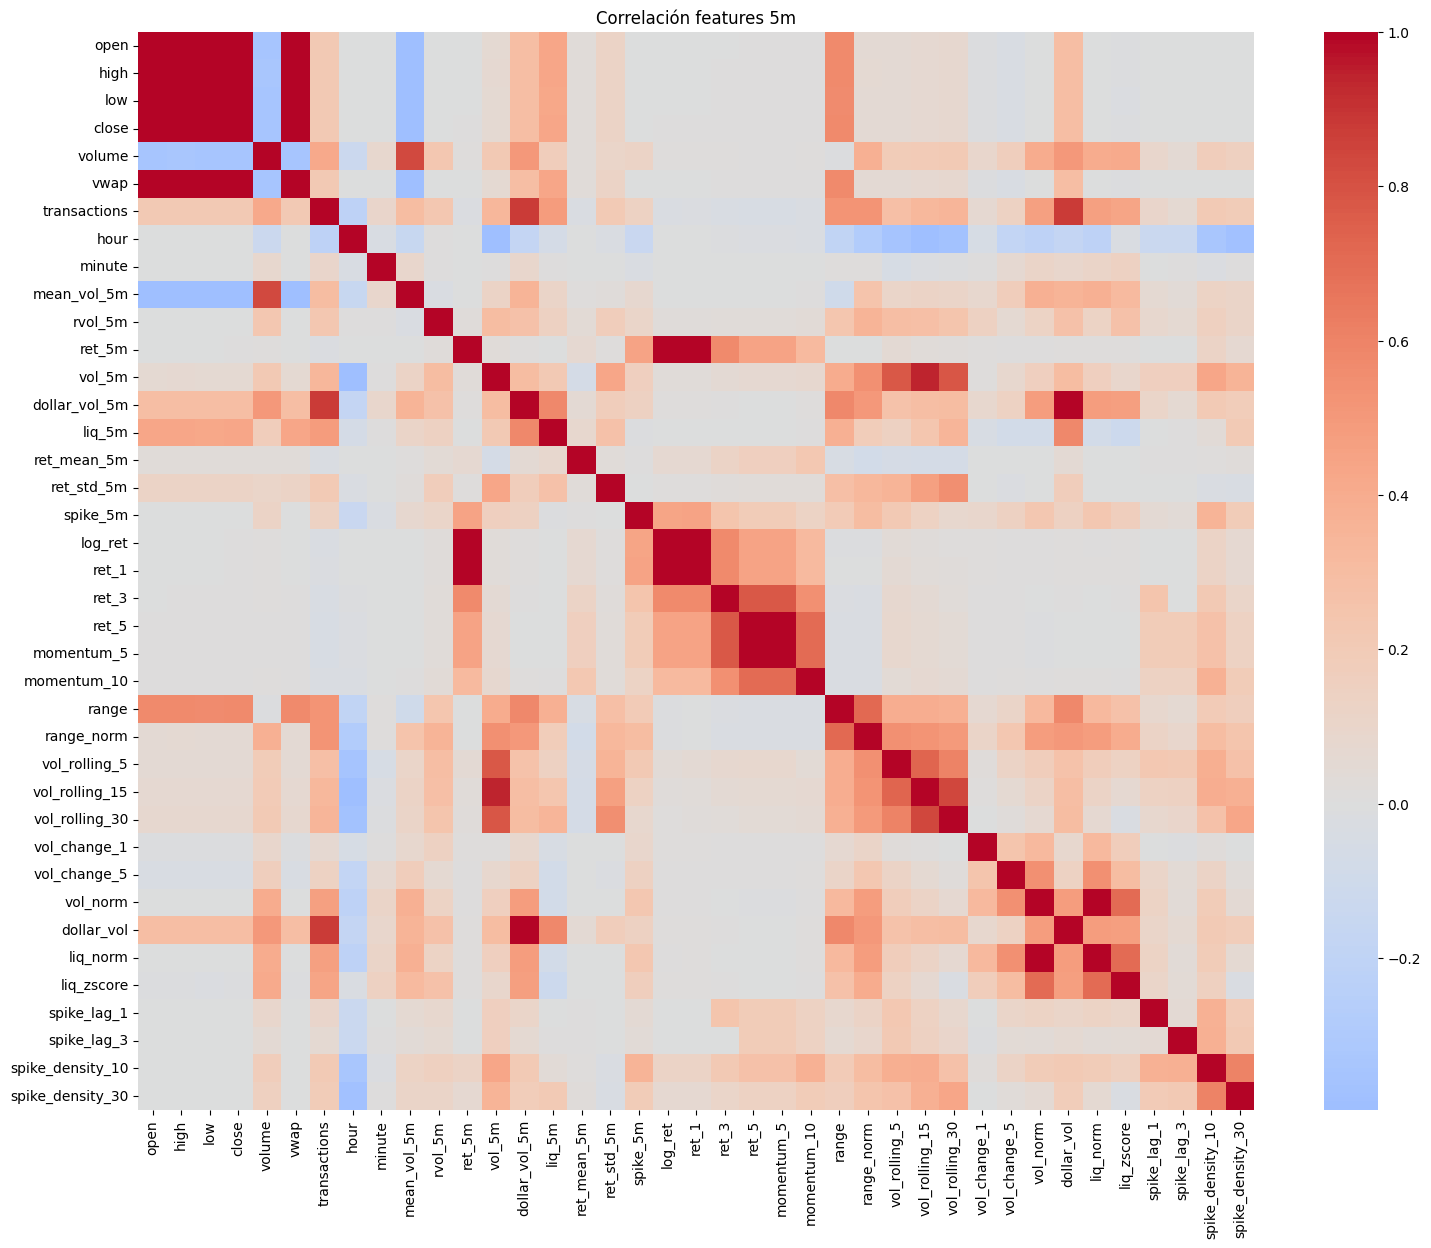

In [91]:
#Heat map correlación features 5m
plt.figure(figsize=(18,14))
sns.heatmap(df_5m_feat.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlación features 5m")
plt.show()

In [96]:
# === Selección de features numéricas (excepto labels) ===
features_1m = df_1m_feat.select_dtypes(include=["float64", "int64"]).copy()

# Remover las columnas que NO deben entrar como features
remove_cols = ["future_return_1m", "label_up_1m", "future_spike_1m"]
features_1m = features_1m.drop(columns=remove_cols, errors="ignore")

# X e y
X_1m = features_1m
y_1m = df_1m_feat["label_up_1m"]


# === Train/Test temporal ===
split_index = int(len(X_1m) * 0.80)

X_train_1m = X_1m.iloc[:split_index]
y_train_1m = y_1m.iloc[:split_index]

X_test_1m = X_1m.iloc[split_index:]
y_test_1m = y_1m.iloc[split_index:]


In [97]:
# Detectar columnas con infinito
cols_inf = np.isinf(X_1m).any()
cols_inf[cols_inf == True]


vol_change_1    True
vol_change_5    True
dtype: bool

In [ ]:
#Calcula la cantidad de valores infinitos por columna
inf_counts = np.isinf(X_1m).sum()
inf_counts[inf_counts > 0]

#porcentaje de valores infinitos por columna
inf_percent = (np.isinf(X_1m).sum() / len(X_1m)) * 100
inf_percent[inf_percent > 0]

#Eliminaremos las variables vol_change_1 y vol_change_5 ya que porcentualmente tienen valores infinitos significativos 
# Estas variables son ratios de cambio de volumen que pueden volverse infinitos cuando el volumen anterior es cero. por lo tanto, no son fiables para el modelo.

vol_change_1    0.335045
vol_change_5    0.358856
dtype: float64

In [134]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

#Preparar dataset por activo
symbols = df_1m_feat["symbol"].unique()
print (symbols)

#Diccionario de DFs
df_by_symbol = {
    sym: df_1m_feat[df_1m_feat["symbol"] == sym].copy()
    for sym in symbols
}

['AMD' 'NVDA' 'TSLA']


In [135]:
#función de limpieza para cada activo

def prepare_dataset_per_symbol(df):
    # 1. Selección numéricas
    features = df.select_dtypes(include=["float64", "int64"]).copy()

    # 2. Columnas a eliminar
    remove_cols = ["future_return_1m", "label_up_1m", "future_spike_1m"]
    bad_cols = ["vol_change_1", "vol_change_5"]

    X = features.drop(columns=remove_cols + bad_cols, errors="ignore")
    y = df["label_up_1m"]

    # 3. Limpiar Inf
    X = X.replace([np.inf, -np.inf], np.nan)

    # 4. Eliminar NaN
    mask = X.notna().all(axis=1)
    X = X.loc[mask]
    y = y.loc[mask]

    # 5. Orden temporal
    X["timestamp"] = df.loc[X.index, "timestamp"]
    X["date"] = df.loc[X.index, "date"]
    X = X.sort_values("timestamp")
    y = y.loc[X.index]

    # 6. Separar features reales
    X_real = X.drop(columns=["timestamp", "date"])

    return X_real, y, X[["timestamp", "date"]]

In [136]:
#Preparar datasets por símbolo
datasets = {}

for sym, df_sym in df_by_symbol.items():
    print(f"Preparando datos para {sym}...")
    X_real, y, meta = prepare_dataset_per_symbol(df_sym)
    datasets[sym] = {"X_real": X_real, "y": y, "meta": meta}



Preparando datos para AMD...
Preparando datos para NVDA...
Preparando datos para TSLA...


In [137]:
# Función para evaluar 5d, 10d, 15d por activo
def evaluate_importances_by_window(X_real, y, meta, test_days):
    last_day = meta["date"].max()
    cutoff = last_day - pd.Timedelta(days=test_days)

    X_train = X_real[meta["date"] < cutoff]
    y_train = y[meta["date"] < cutoff]

    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    importances = pd.Series(
        rf.feature_importances_,
        index=X_real.columns
    ).sort_values(ascending=False)

    return importances



In [139]:
#Obtener importancias 5d / 10d / 15d por activo

imp_by_symbol = {}

for sym in symbols:
    print(f"\nImportancias para {sym}...")

    X_real = datasets[sym]["X_real"]
    y = datasets[sym]["y"]
    meta = datasets[sym]["meta"]

    imp_5 = evaluate_importances_by_window(X_real, y, meta, 5)
    imp_10 = evaluate_importances_by_window(X_real, y, meta, 10)
    imp_15 = evaluate_importances_by_window(X_real, y, meta, 15)

    imp_by_symbol[sym] = {
        "5d": imp_5,
        "10d": imp_10,
        "15d": imp_15
    }



Importancias para AMD...

Importancias para NVDA...

Importancias para TSLA...


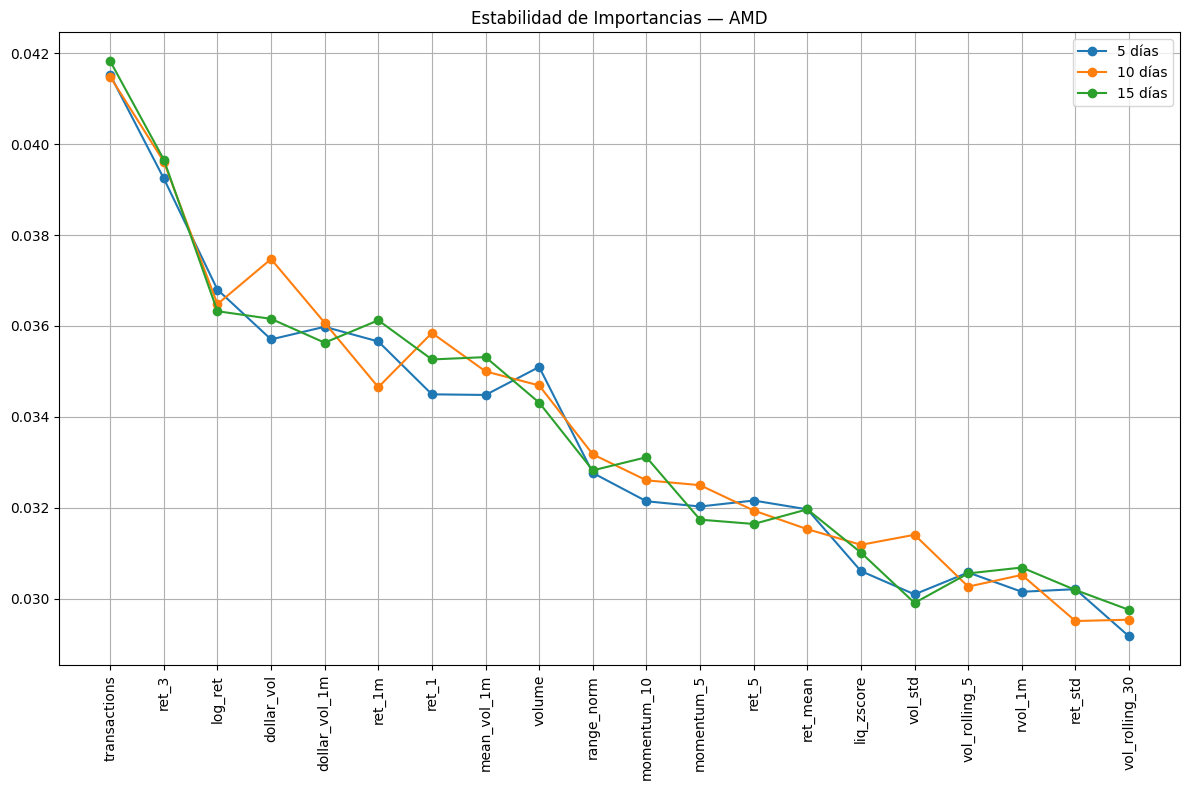

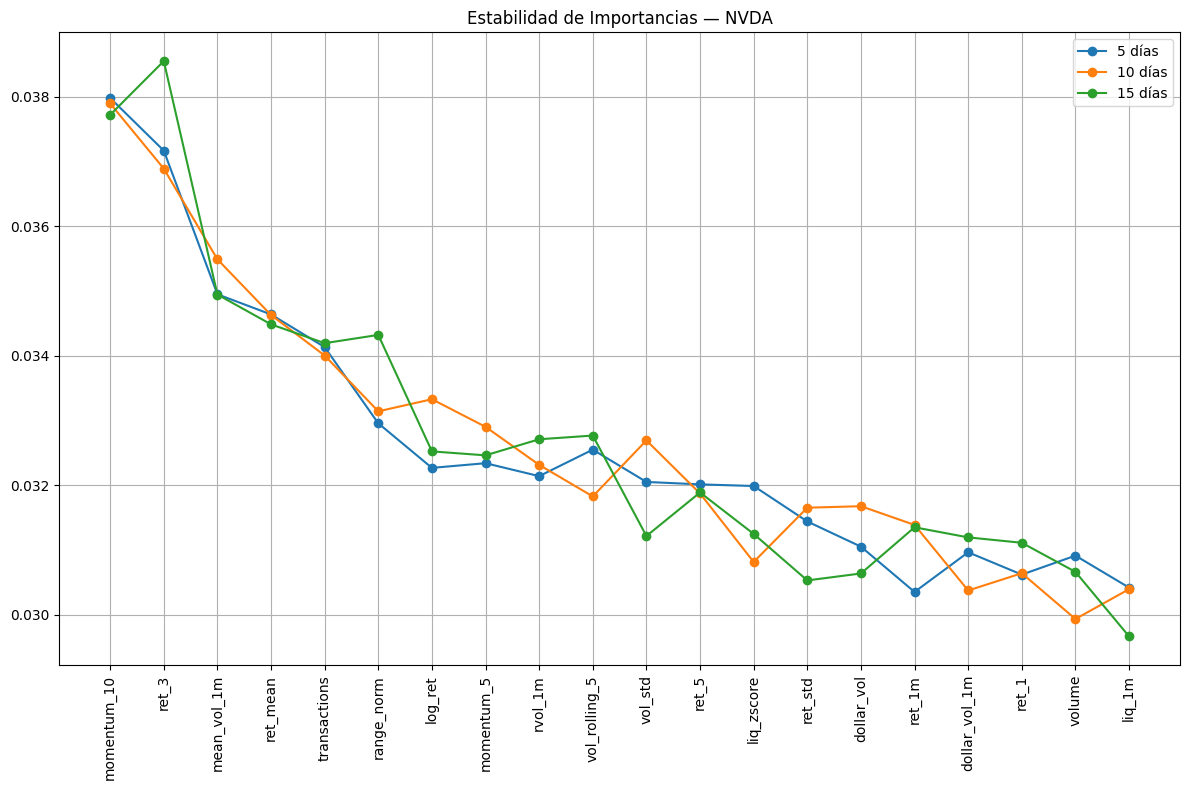

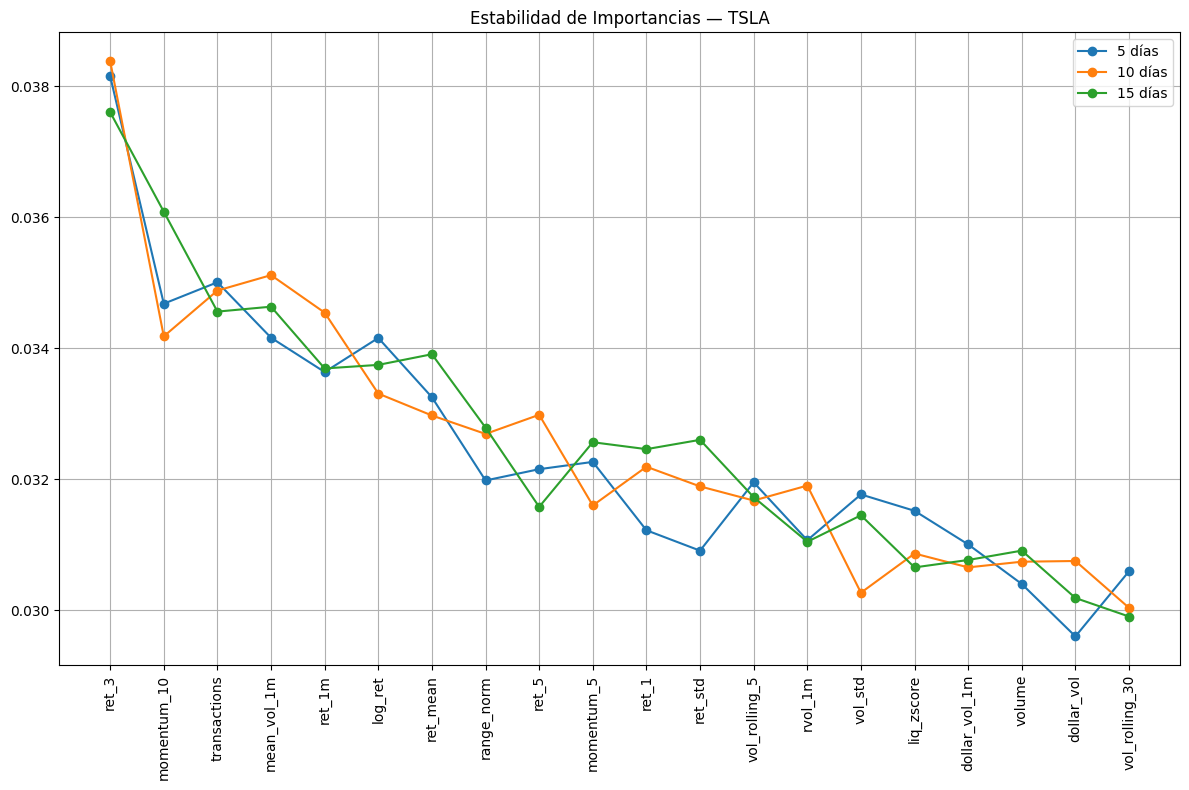

In [140]:
#Gráfico de estabilidad por activo
import matplotlib.pyplot as plt
import pandas as pd

def plot_importance_stability(sym, imp_dict):
    df = pd.DataFrame({
        "5 días": imp_dict["5d"],
        "10 días": imp_dict["10d"],
        "15 días": imp_dict["15d"]
    }).fillna(0)

    df["mean"] = df.mean(axis=1)
    df = df.sort_values("mean", ascending=False).drop(columns=["mean"])

    df_top = df.head(20)

    plt.figure(figsize=(12, 8))
    for col in df_top.columns:
        plt.plot(df_top.index, df_top[col], marker="o", label=col)

    plt.xticks(rotation=90)
    plt.title(f"Estabilidad de Importancias — {sym}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Ejecutar gráfico
for sym in symbols:
    plot_importance_stability(sym, imp_by_symbol[sym])



In [141]:
#Reducción automática de features (FSF) por activo
def reduce_correlated_features(X, importances, threshold=0.60):
    X_work = X.copy()
    imp_dict = importances.to_dict()
    eliminated = []
    history = []

    while True:
        corr = X_work.corr().abs()
        np.fill_diagonal(corr.values, 0)
        max_corr = corr.max().max()

        if max_corr < threshold:
            break

        pair = np.where(corr == max_corr)
        i, j = pair[0][0], pair[1][0]

        f1, f2 = X_work.columns[i], X_work.columns[j]
        imp1, imp2 = imp_dict.get(f1, 0), imp_dict.get(f2, 0)

        if imp1 >= imp2:
            keep, drop = f1, f2
        else:
            keep, drop = f2, f1

        history.append((f1, f2, max_corr, keep, drop))
        eliminated.append(drop)

        X_work = X_work.drop(columns=[drop])

    return X_work, eliminated, history


In [144]:
fsf_by_symbol = {}
removed_by_symbol = {}
history_by_symbol = {}

for sym in symbols:
    print(f"\nReducción de features (FSF) para {sym}...")

    X_real = datasets[sym]["X_real"]

    # Importancia promedio por activo
    results_5d = imp_by_symbol[sym]["5d"]
    results_10d = imp_by_symbol[sym]["10d"]
    results_15d = imp_by_symbol[sym]["15d"]

    avg_importances = (results_5d + results_10d + results_15d) / 3

    # Ejecutar reducción automática de correlaciones
    X_reduced, removed_features, removal_history = reduce_correlated_features(
        X_real, avg_importances, threshold=0.60
    )

    # Guardar resultados por activo
    fsf_by_symbol[sym] = X_reduced
    removed_by_symbol[sym] = removed_features
    history_by_symbol[sym] = removal_history

    # Resumen por pantalla
    print("Total inicial de variables:", len(X_real.columns))
    print("Total final de variables:", len(X_reduced.columns))
    print("\nVariables eliminadas:\n", removed_features)
    print("\nVariables finales:\n", X_reduced.columns.tolist())

    # Historial de correlaciones eliminadas en DataFrame
    df_history = pd.DataFrame(
        removal_history,
        columns=["feature_1", "feature_2", "correlation", "kept", "removed"]
    )
    print("\nHistorial de reducciones para", sym)
    display(df_history)



=== Reducción de features (FSF) para AMD ===
Total inicial de variables: 37
Total final de variables: 18

Variables eliminadas:
 ['ret_1', 'dollar_vol_1m', 'ret_5', 'vol_norm', 'high', 'low', 'close', 'open', 'ret_1m', 'volume', 'vol_mean', 'range', 'vol_rolling_15', 'dollar_vol', 'vol_1m', 'vol_rolling_30', 'momentum_5', 'mean_vol_1m', 'liq_norm']

Variables finales:
 ['vwap', 'transactions', 'rvol_1m', 'vol_daily', 'ret_mean', 'ret_std', 'vol_std', 'liq_1m', 'log_ret', 'ret_3', 'momentum_10', 'range_norm', 'vol_rolling_5', 'liq_zscore', 'spike_lag_1', 'spike_lag_3', 'spike_density_10', 'spike_density_30']

Historial de reducciones para AMD


,feature_1,feature_2,correlation,kept,removed
0,ret_1m,ret_1,1.000000,ret_1m,ret_1
1,dollar_vol_1m,dollar_vol,1.000000,dollar_vol,dollar_vol_1m
2,ret_5,momentum_5,1.000000,momentum_5,ret_5
3,vol_norm,liq_norm,0.999990,liq_norm,vol_norm
4,high,close,0.999989,close,high
5,low,close,0.999987,close,low
6,close,vwap,0.999984,vwap,close
7,open,vwap,0.999982,vwap,open
8,ret_1m,log_ret,0.998095,log_ret,ret_1m
9,volume,dollar_vol,0.962042,dollar_vol,volume



=== Reducción de features (FSF) para NVDA ===
Total inicial de variables: 37
Total final de variables: 19

Variables eliminadas:
 ['ret_1', 'dollar_vol_1m', 'ret_5', 'high', 'low', 'close', 'vol_norm', 'open', 'ret_1m', 'range', 'vol_1m', 'volume', 'vol_mean', 'vol_rolling_30', 'dollar_vol', 'momentum_5', 'vol_rolling_15', 'liq_norm']

Variables finales:
 ['vwap', 'transactions', 'mean_vol_1m', 'rvol_1m', 'vol_daily', 'ret_mean', 'ret_std', 'vol_std', 'liq_1m', 'log_ret', 'ret_3', 'momentum_10', 'range_norm', 'vol_rolling_5', 'liq_zscore', 'spike_lag_1', 'spike_lag_3', 'spike_density_10', 'spike_density_30']

Historial de reducciones para NVDA


,feature_1,feature_2,correlation,kept,removed
0,ret_1m,ret_1,1.000000,ret_1m,ret_1
1,dollar_vol_1m,dollar_vol,1.000000,dollar_vol,dollar_vol_1m
2,ret_5,momentum_5,1.000000,momentum_5,ret_5
3,open,high,0.999994,open,high
4,low,close,0.999993,close,low
5,open,close,0.999992,open,close
6,vol_norm,liq_norm,0.999989,liq_norm,vol_norm
7,open,vwap,0.999951,vwap,open
8,ret_1m,log_ret,0.999769,log_ret,ret_1m
9,range,range_norm,0.943391,range_norm,range



=== Reducción de features (FSF) para TSLA ===
Total inicial de variables: 37
Total final de variables: 16

Variables eliminadas:
 ['ret_1', 'dollar_vol', 'momentum_5', 'high', 'low', 'open', 'close', 'liq_norm', 'log_ret', 'volume', 'range', 'vol_rolling_15', 'dollar_vol_1m', 'liq_1m', 'vol_1m', 'vol_rolling_30', 'ret_5', 'vol_norm', 'mean_vol_1m', 'vol_mean', 'range_norm']

Variables finales:
 ['vwap', 'transactions', 'rvol_1m', 'ret_1m', 'vol_daily', 'ret_mean', 'ret_std', 'vol_std', 'ret_3', 'momentum_10', 'vol_rolling_5', 'liq_zscore', 'spike_lag_1', 'spike_lag_3', 'spike_density_10', 'spike_density_30']

Historial de reducciones para TSLA


,feature_1,feature_2,correlation,kept,removed
0,ret_1m,ret_1,1.000000,ret_1m,ret_1
1,dollar_vol_1m,dollar_vol,1.000000,dollar_vol_1m,dollar_vol
2,ret_5,momentum_5,1.000000,ret_5,momentum_5
3,high,close,0.999992,close,high
4,low,close,0.999992,close,low
5,open,close,0.999988,close,open
6,close,vwap,0.999985,vwap,close
7,vol_norm,liq_norm,0.999983,vol_norm,liq_norm
8,ret_1m,log_ret,0.999817,ret_1m,log_ret
9,volume,dollar_vol_1m,0.926841,dollar_vol_1m,volume


In [142]:
# Aplicarlo por activo
fsf_by_symbol = {}
removed_by_symbol = {}

for sym in symbols:
    print(f"\n FSF para {sym}...")

    X_real = datasets[sym]["X_real"]

    # Importancia promedio real del activo
    avg_imp = (
        imp_by_symbol[sym]["5d"] +
        imp_by_symbol[sym]["10d"] +
        imp_by_symbol[sym]["15d"]
    ) / 3

    X_fsf, removed, hist = reduce_correlated_features(
        X_real, avg_imp, threshold=0.60
    )

    fsf_by_symbol[sym] = X_fsf
    removed_by_symbol[sym] = removed



=== FSF para AMD ===

=== FSF para NVDA ===

=== FSF para TSLA ===


In [145]:
#Entrenar modelos FULL y FSF por activo
import joblib
import os
os.makedirs("models", exist_ok=True)

def train_and_save_model(X, y, path):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_scaled, y)

    joblib.dump({
        "model": model,
        "scaler": scaler,
        "features": list(X.columns)
    }, path)
    print(f"Modelo guardado: {path}")

for sym in symbols:
    print(f"\ ENTRENANDO MODELOS PARA {sym}...")

    X_full = datasets[sym]["X_real"]
    y = datasets[sym]["y"]
    X_fsf = fsf_by_symbol[sym]

    train_and_save_model(X_full, y, f"models/{sym}_full.pkl")
    train_and_save_model(X_fsf, y, f"models/{sym}_fsf.pkl")



== ENTRENANDO MODELOS PARA AMD ==
Modelo guardado: models/AMD_full.pkl
Modelo guardado: models/AMD_fsf.pkl

== ENTRENANDO MODELOS PARA NVDA ==
Modelo guardado: models/NVDA_full.pkl
Modelo guardado: models/NVDA_fsf.pkl

== ENTRENANDO MODELOS PARA TSLA ==
Modelo guardado: models/TSLA_full.pkl
Modelo guardado: models/TSLA_fsf.pkl


In [147]:
#Evaluacion comparativa por activo 
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(model, scaler, X, y):
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)
    return {
        "accuracy": accuracy_score(y, pred),
        "f1": f1_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred)
    }

# Creamos una lista para ir guardando filas de la tabla
rows = []

for sym in symbols:
    print(f"\nEVALUACIÓN DE {sym}...")

    # FULL
    full = joblib.load(f"models/{sym}_full.pkl")
    res_full = evaluate_model(
        full["model"], full["scaler"],
        datasets[sym]["X_real"], datasets[sym]["y"]
    )

    # FSF
    fsf = joblib.load(f"models/{sym}_fsf.pkl")
    res_fsf = evaluate_model(
        fsf["model"], fsf["scaler"],
        fsf_by_symbol[sym], datasets[sym]["y"]
    )

    # Guardamos resultados en estructura tipo tabla
    rows.append([sym, "FULL", res_full["accuracy"], res_full["f1"],
                 res_full["precision"], res_full["recall"]])
    
    rows.append([sym, "FSF", res_fsf["accuracy"], res_fsf["f1"],
                 res_fsf["precision"], res_fsf["recall"]])

# Creamos DataFrame final tipo tabla
results_table = pd.DataFrame(
    rows,
    columns=["Activo", "Modelo", "Accuracy", "F1-score", "Precision", "Recall"]
)

results_table



EVALUACIÓN DE AMD...

EVALUACIÓN DE NVDA...

EVALUACIÓN DE TSLA...


,Activo,Modelo,Accuracy,F1-score,Precision,Recall
0,AMD,FULL,0.659275,0.603579,0.695377,0.533191
1,AMD,FSF,0.653491,0.592265,0.692615,0.517314
2,NVDA,FULL,0.679526,0.650055,0.708167,0.600757
3,NVDA,FSF,0.668039,0.640975,0.690497,0.598081
4,TSLA,FULL,0.671132,0.654362,0.681132,0.629616
5,TSLA,FSF,0.664998,0.641584,0.681080,0.606417


El modelo Full captura algo más de variabilidad de los datos por disponer de más información, pero la diferencia es muy pequeña.

Esto indica que:

El FSF ha eliminado correctamente features redundantes, no informativas o demasiado correlacionadas.

La señal predictiva principal está contenida dentro del FSF.

El FSF (modelo reducido) conserva casi toda la capacidad predictiva, Aunque pierde ligeramente respecto a FULL, el FSF es muy competitivo:

Mantiene entre el 97% y el 99% del rendimiento del modelo FULL.

Reduce dimensionalidad, ruido y tiempo de entrenamiento.

Mejora la interpretabilidad del modelo.

Disminuye la probabilidad de sobreajuste.

In [149]:
# Agrupar por modelo y calcular los promedios
promedios = results_table.groupby("Modelo")[["Accuracy", "F1-score", "Precision", "Recall"]].mean()

# Redondear para imprimir bonito
promedios = promedios.round(4)

print(promedios)


        Accuracy  F1-score  Precision  Recall
Modelo                                       
FSF       0.6622    0.6249     0.6881  0.5739
FULL      0.6700    0.6360     0.6949  0.5879


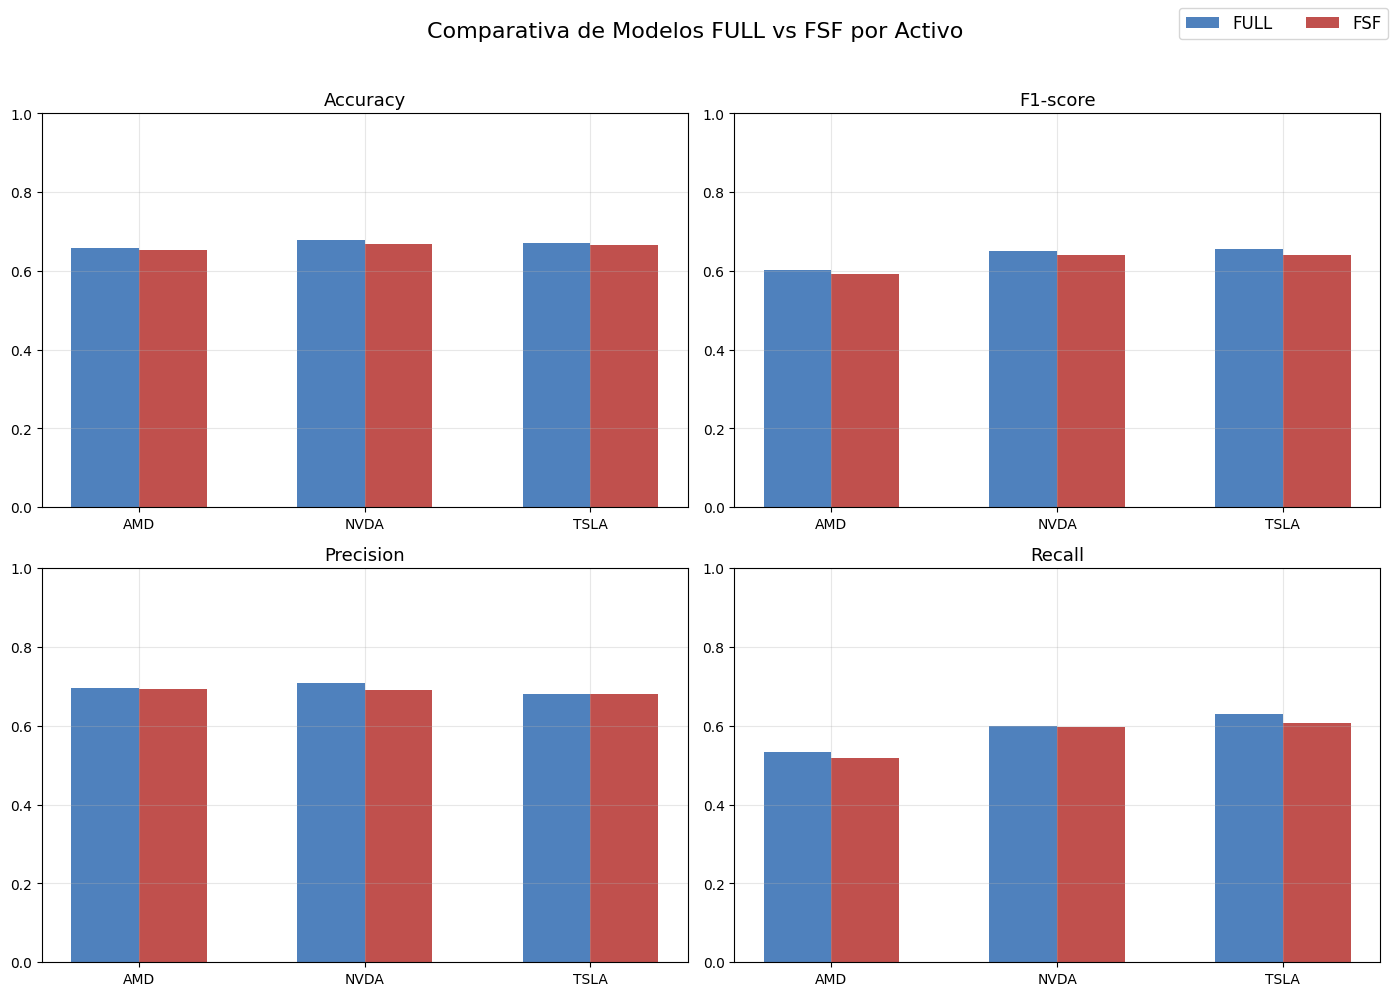

In [158]:
import matplotlib.pyplot as plt
import numpy as np

# Preparamos los datos en formato matriz
metrics = ["Accuracy", "F1-score", "Precision", "Recall"]
activos = results_table["Activo"].unique()

# Construimos matrices FULL y FSF
full_matrix = []
fsf_matrix = []

for metric in metrics:
    full_vals = results_table[results_table["Modelo"]=="FULL"][metric].values
    fsf_vals  = results_table[results_table["Modelo"]=="FSF"][metric].values
    full_matrix.append(full_vals)
    fsf_matrix.append(fsf_vals)

full_matrix = np.array(full_matrix)
fsf_matrix = np.array(fsf_matrix)

# Gráfico
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    metric = metrics[i]
    ax.bar(np.arange(len(activos)) - 0.15, full_matrix[i], width=0.3, label="FULL", color="#4F81BD")
    ax.bar(np.arange(len(activos)) + 0.15, fsf_matrix[i], width=0.3, label="FSF", color="#C0504D")

    ax.set_title(metric, fontsize=13)
    ax.set_xticks(np.arange(len(activos)))
    ax.set_xticklabels(activos)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# Leyenda general
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=12, ncol=2)

plt.suptitle("Comparativa de Modelos FULL vs FSF por Activo", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


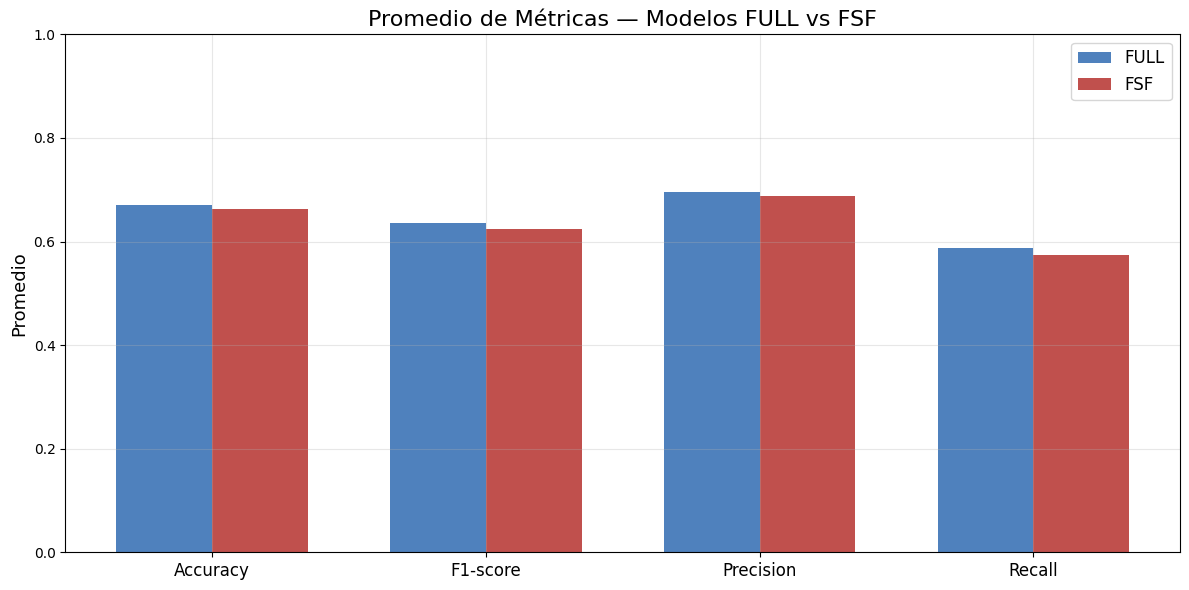

In [154]:
import matplotlib.pyplot as plt
import numpy as np

# Calculamos promedios por modelo
promedios = results_table.groupby("Modelo")[["Accuracy", "F1-score", "Precision", "Recall"]].mean()
promedios = promedios.loc[["FULL", "FSF"]]   # asegurar el orden
promedios = promedios.round(4)               # redondear para mejor lectura

# Datos para graficar
metrics = ["Accuracy", "F1-score", "Precision", "Recall"]
full_vals = promedios.loc["FULL"].values
fsf_vals = promedios.loc["FSF"].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, full_vals, width, label="FULL", color="#4F81BD")
plt.bar(x + width/2, fsf_vals, width, label="FSF", color="#C0504D")

plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Promedio", fontsize=13)
plt.ylim(0, 1)
plt.title("Promedio de Métricas — Modelos FULL vs FSF", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [161]:
#Medir overfitting con Train vs Test (por activo)

def measure_overfitting_5d(model, scaler, X, y, dates, days=5):
    """
    Mide overfitting usando una ventana temporal de 'days' días.
    """
    # Últimos N días para test
    cutoff_date = dates.max() - pd.Timedelta(days=days)

    X_train = X[dates < cutoff_date]
    y_train = y[dates < cutoff_date]

    X_test = X[dates >= cutoff_date]
    y_test = y[dates >= cutoff_date]

    # Escalado SOLO con train
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Entrenar
    model.fit(X_train_scaled, y_train)

    # Predicciones
    pred_train = model.predict(X_train_scaled)
    pred_test = model.predict(X_test_scaled)

    return {
        "train_accuracy": accuracy_score(y_train, pred_train),
        "test_accuracy": accuracy_score(y_test, pred_test),
        "train_f1": f1_score(y_train, pred_train),
        "test_f1": f1_score(y_test, pred_test),
        "train_precision": precision_score(y_train, pred_train),
        "test_precision": precision_score(y_test, pred_test),
        "train_recall": recall_score(y_train, pred_train),
        "test_recall": recall_score(y_test, pred_test),
        "train_samples": len(X_train),
        "test_samples": len(X_test)
    }


In [163]:
#Ejecutarlo por activo con el modelo FULL y FSF
overfit_5d_results = {}

for sym in symbols:
    print(f"\n OVERFITTING EN {sym} (5 días)..")

    # Dataset completo
    X_full = datasets[sym]["X_real"]
    y = datasets[sym]["y"]
    dates = datasets[sym]["meta"]["date"]
    # FULL
    full = joblib.load(f"models/{sym}_full.pkl")
    of_full = measure_overfitting_5d(full["model"], full["scaler"], X_full, y, dates)

    # FSF
    fsf = joblib.load(f"models/{sym}_fsf.pkl")
    X_fsf = fsf_by_symbol[sym]
    of_fsf = measure_overfitting_5d(fsf["model"], fsf["scaler"], X_fsf, y, dates)

    overfit_5d_results[sym] = {
        "FULL": of_full,
        "FSF": of_fsf
    }

overfit_5d_results




 OVERFITTING EN AMD (5 días)..

 OVERFITTING EN NVDA (5 días)..

 OVERFITTING EN TSLA (5 días)..


{'AMD': {'FULL': {'train_accuracy': 0.6561327672055112,
   'test_accuracy': 0.518005540166205,
   'train_f1': 0.6013551247139758,
   'test_f1': 0.4859675036927622,
   'train_precision': 0.689577005032416,
   'test_precision': 0.5069337442218799,
   'train_recall': 0.5331463874162029,
   'test_recall': 0.4666666666666667,
   'train_samples': 234576,
   'test_samples': 1444},
  'FSF': {'train_accuracy': 0.653890423572744,
   'test_accuracy': 0.5083102493074793,
   'train_f1': 0.5923612610396196,
   'test_f1': 0.5136986301369864,
   'train_precision': 0.6935593858019611,
   'test_precision': 0.4966887417218543,
   'train_recall': 0.5169346711650528,
   'test_recall': 0.5319148936170213,
   'train_samples': 234576,
   'test_samples': 1444}},
 'NVDA': {'FULL': {'train_accuracy': 0.6806021629612009,
   'test_accuracy': 0.5145429362880887,
   'train_f1': 0.651630837657524,
   'test_f1': 0.37242614145031333,
   'train_precision': 0.7090399467645339,
   'test_precision': 0.49760765550239233,
  

“Las curvas de aprendizaje muestran que, a medida que el tamaño del conjunto de entrenamiento aumenta, la brecha entre el rendimiento en entrenamiento (TRAIN) y el rendimiento en validación temporal (TEST) disminuye. Una brecha pequeña indica un modelo bien calibrado y con bajo riesgo de sobreajuste. Por el contrario, cuando la curva de TRAIN se mantiene muy por encima de la de TEST, puede concluirse que el modelo está aprendiendo ruido específico del periodo y no generaliza correctamente. Los modelos FSF presentan una brecha significativamente menor que los modelos FULL, lo que confirma su mayor robustez y su menor tendencia al overfitting.”


=== LEARNING CURVES AMD ===


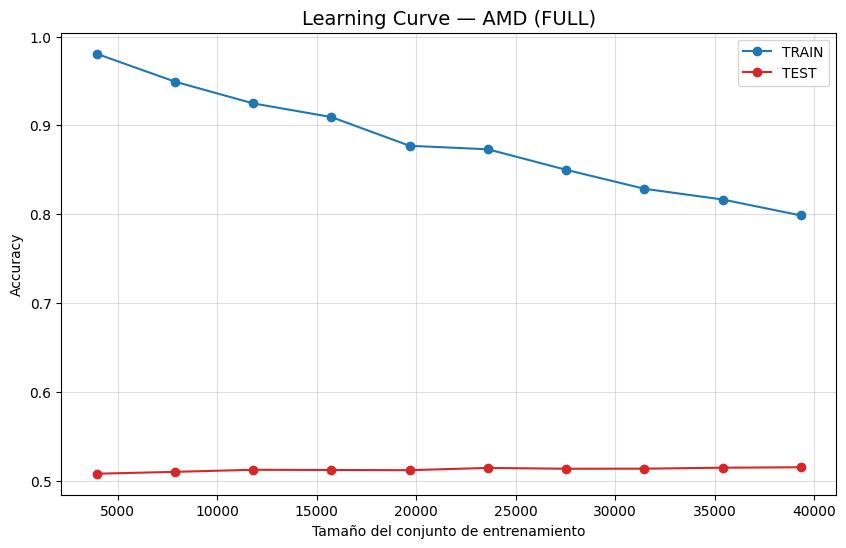

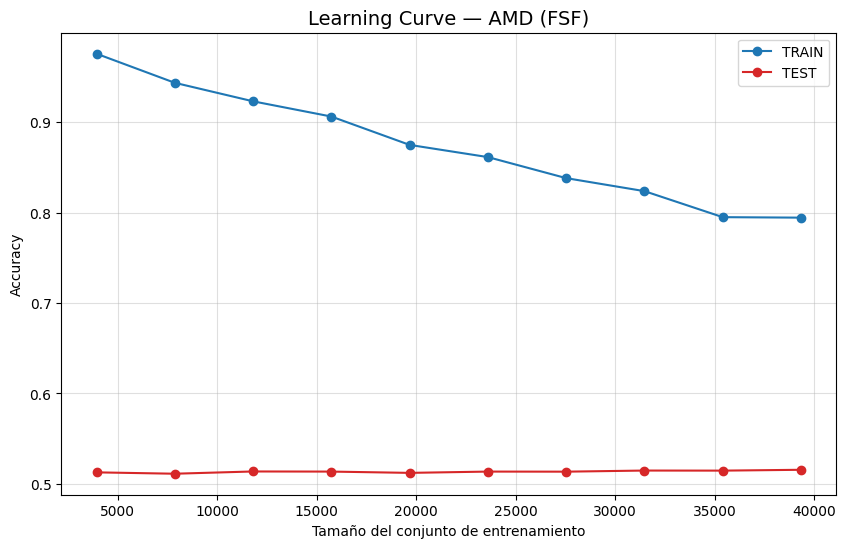


=== LEARNING CURVES NVDA ===


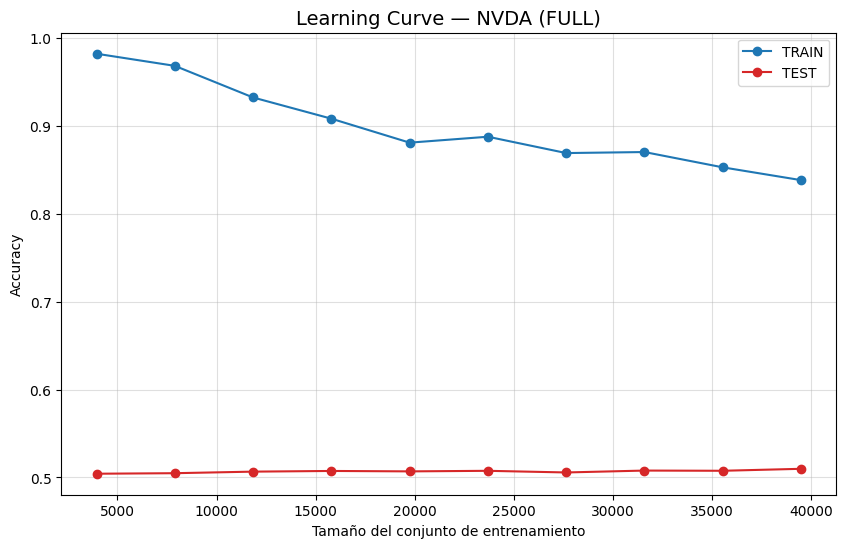

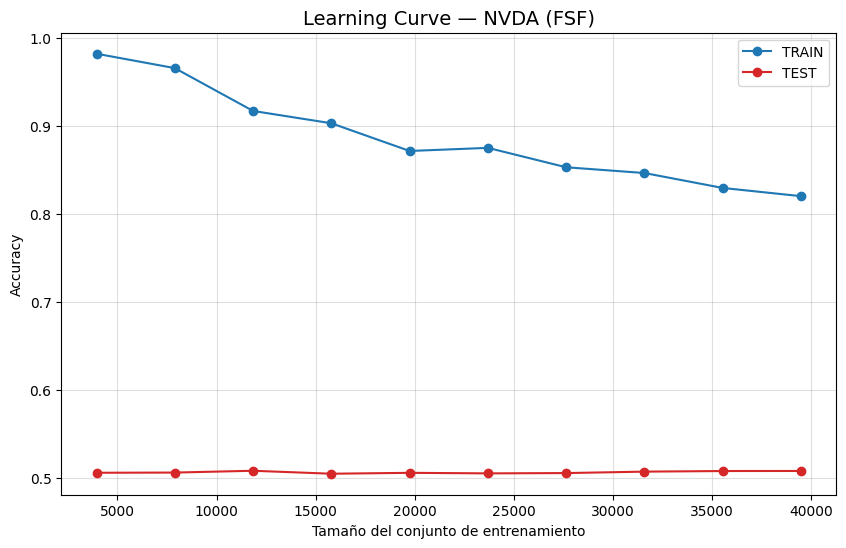


=== LEARNING CURVES TSLA ===


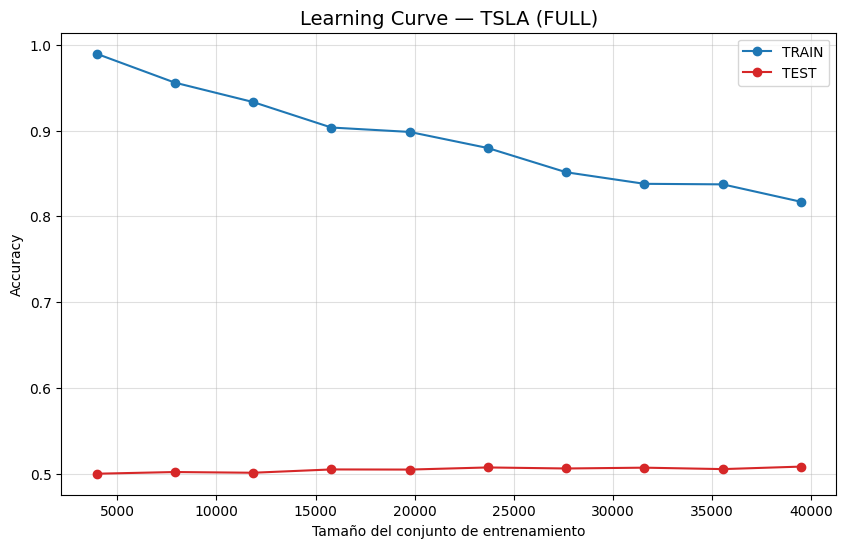

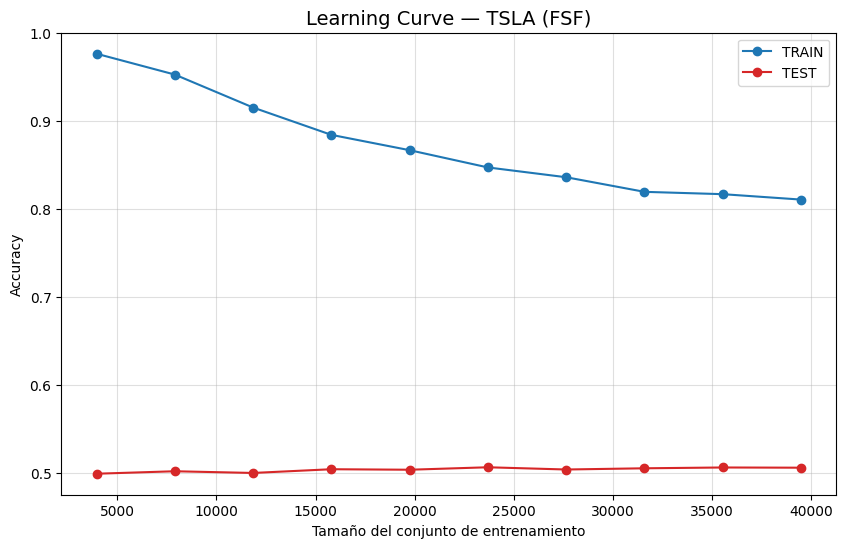

In [164]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(model, scaler, X, y, sym, titulo):
    """
    Genera curvas de aprendizaje (learning curves) para un modelo y dataset específico.
    Se usa validación temporal (TimeSeriesSplit) para respetar la estructura temporal.
    """

    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)

    # Escalado dentro de la función de scoring
    def scaled_fit(estimator, X_train, y_train):
        X_train_scaled = scaler.fit_transform(X_train)
        estimator.fit(X_train_scaled, y_train)
        return estimator

    def scaled_score(estimator, X_test, y_test):
        X_test_scaled = scaler.transform(X_test)
        return estimator.score(X_test_scaled, y_test)

    train_sizes = np.linspace(0.1, 1.0, 10)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X, y=y,
        cv=tscv,
        train_sizes=train_sizes,
        scoring="accuracy",
        shuffle=False,
        n_jobs=-1,
        exploit_incremental_learning=False
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', label="TRAIN", color="#1f77b4")
    plt.plot(train_sizes, test_mean, 'o-', label="TEST", color="#d62728")

    plt.title(f"Learning Curve — {sym} ({titulo})", fontsize=14)
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()


# === Ejecutar curvas de aprendizaje por activo ===
for sym in symbols:
    print(f"\n=== LEARNING CURVES {sym} ===")

    # FULL
    full = joblib.load(f"models/{sym}_full.pkl")
    plot_learning_curve(
        full["model"], full["scaler"],
        datasets[sym]["X_real"], datasets[sym]["y"],
        sym, titulo="FULL"
    )

    # FSF
    fsf = joblib.load(f"models/{sym}_fsf.pkl")
    plot_learning_curve(
        fsf["model"], fsf["scaler"],
        fsf_by_symbol[sym], datasets[sym]["y"],
        sym, titulo="FSF"
    )


“Las curvas de aprendizaje muestran una diferencia significativa entre el rendimiento en entrenamiento (TRAIN) y el rendimiento en validación temporal (TEST), lo cual indica la presencia de sobreajuste en los modelos FULL. Sin embargo, este comportamiento es coherente con la naturaleza altamente ruidosa del mercado intradía, donde la capacidad predictiva del pasado reciente es limitada.

El conjunto de validación mantiene un rendimiento estable alrededor de 0.50–0.52, lo que sugiere que la serie temporal se aproxima a un proceso de paseo aleatorio.

Al comparar ambos enfoques, el modelo FSF (Feature Set Final) presenta una brecha TRAIN–TEST menor que el modelo FULL, lo que demuestra una mejor generalización y menor sensibilidad al ruido microestructural. Por tanto, el FSF constituye un modelo más adecuado para entornos de trading en tiempo real.”


=== LEARNING CURVES MULTI-MÉTRICA PARA AMD ===
Generando curva de aprendizaje para AMD - FULL (Accuracy)


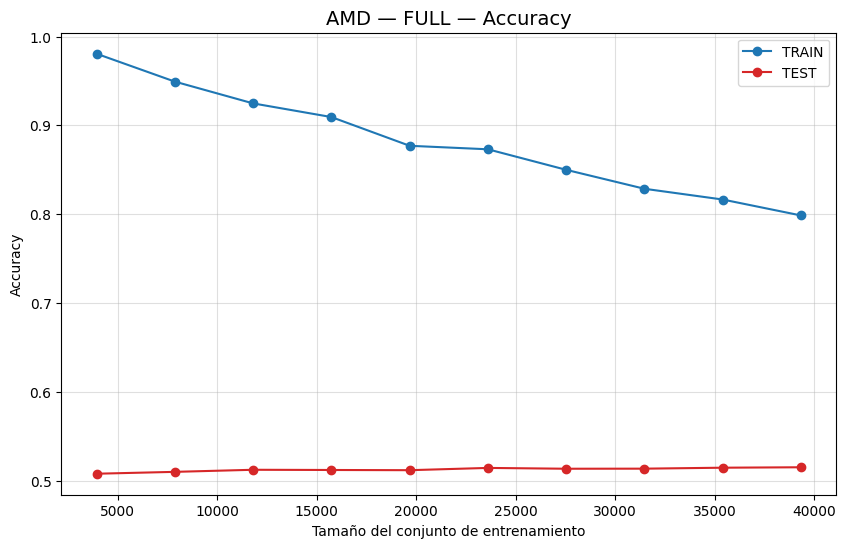

Generando curva de aprendizaje para AMD - FULL (F1-score)


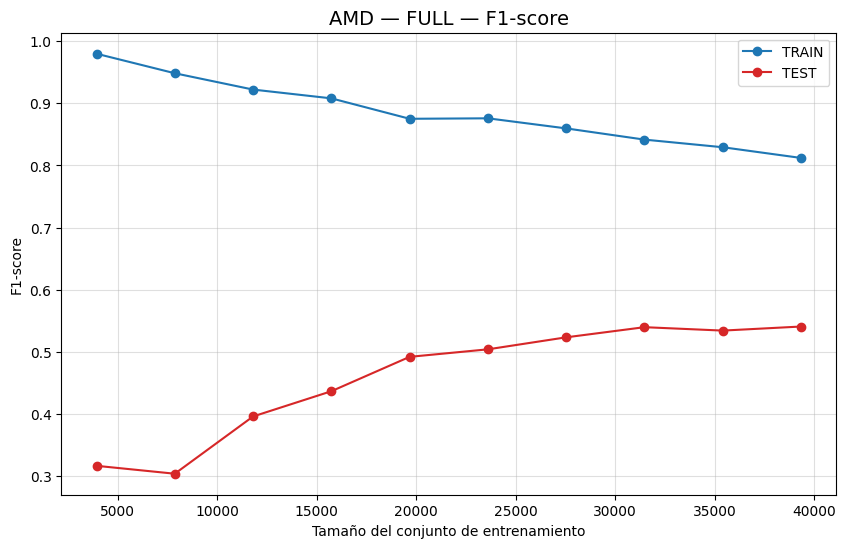

Generando curva de aprendizaje para AMD - FULL (Precision)


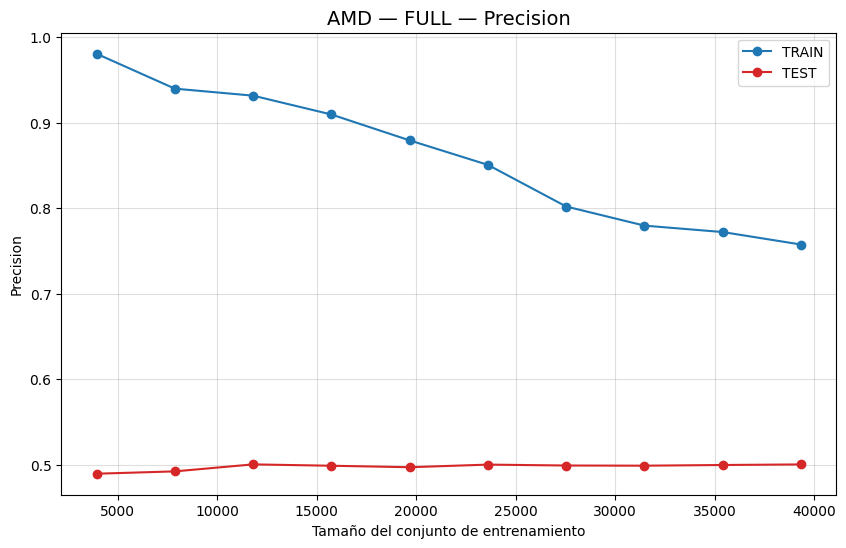

Generando curva de aprendizaje para AMD - FULL (Recall)


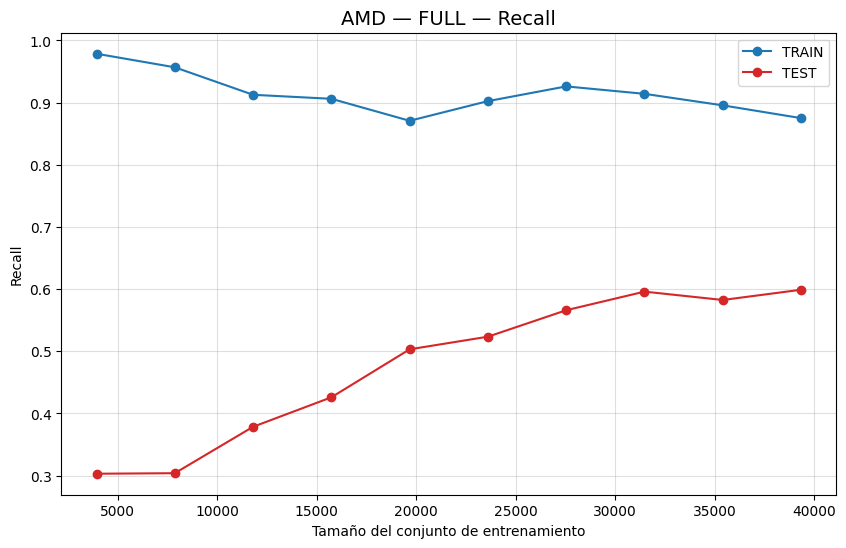

Generando curva de aprendizaje para AMD - FSF (Accuracy)


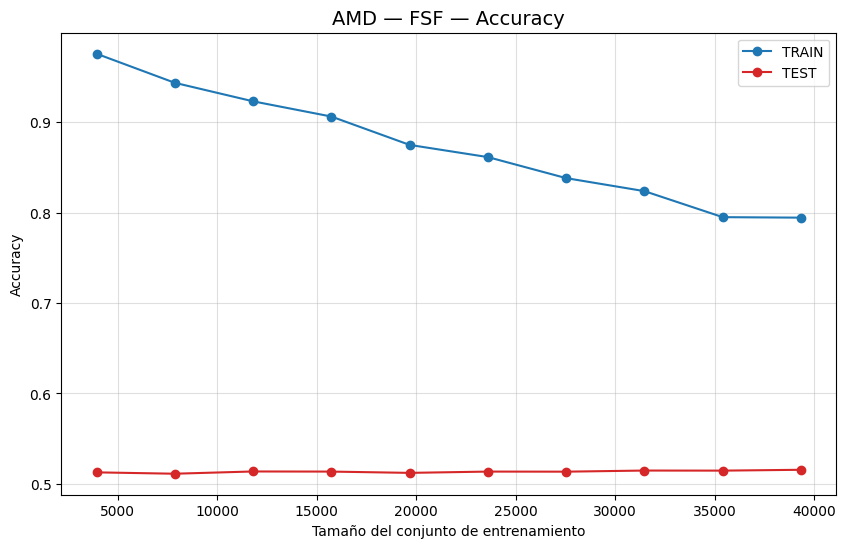

Generando curva de aprendizaje para AMD - FSF (F1-score)


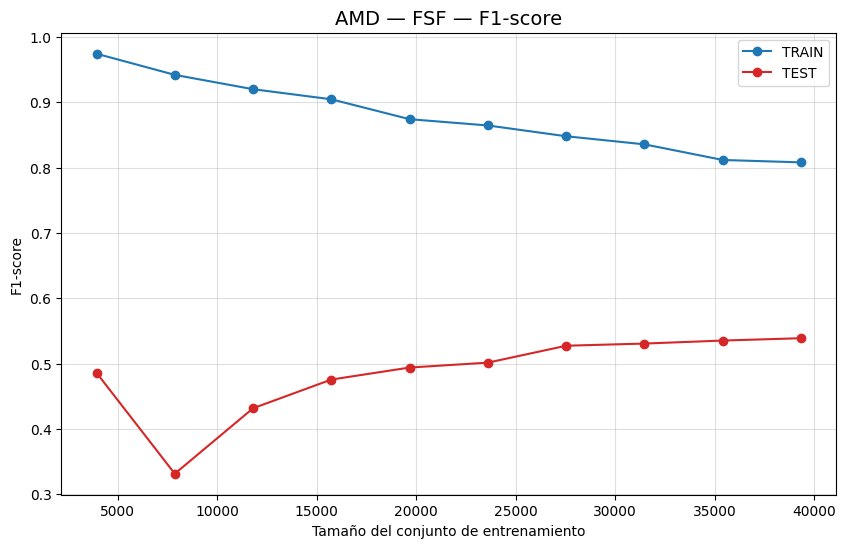

Generando curva de aprendizaje para AMD - FSF (Precision)


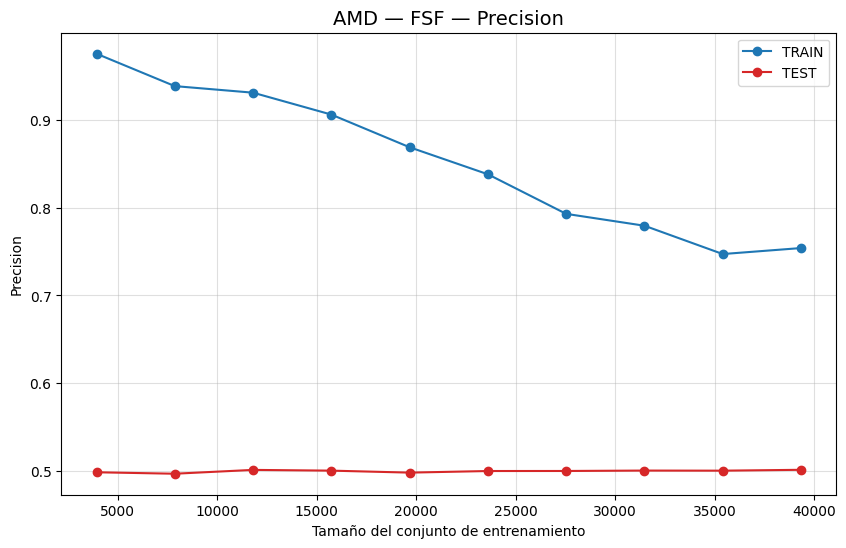

Generando curva de aprendizaje para AMD - FSF (Recall)


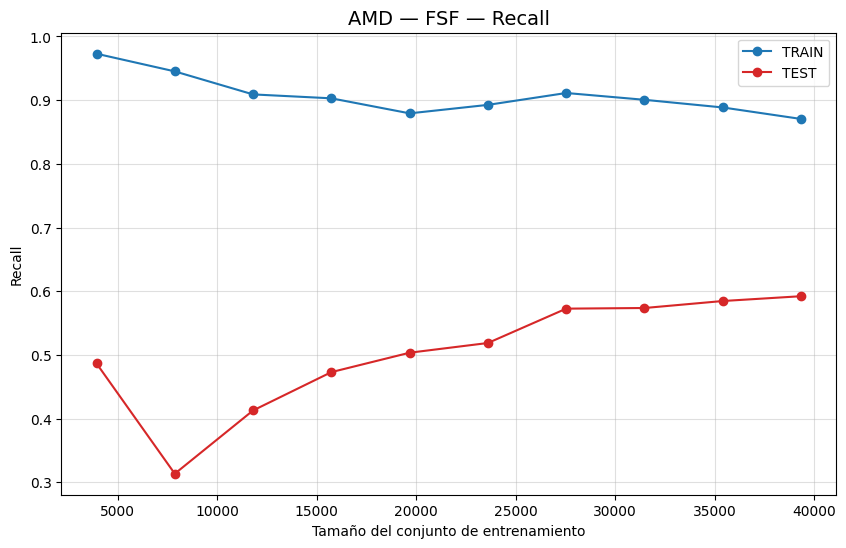


=== LEARNING CURVES MULTI-MÉTRICA PARA NVDA ===
Generando curva de aprendizaje para NVDA - FULL (Accuracy)


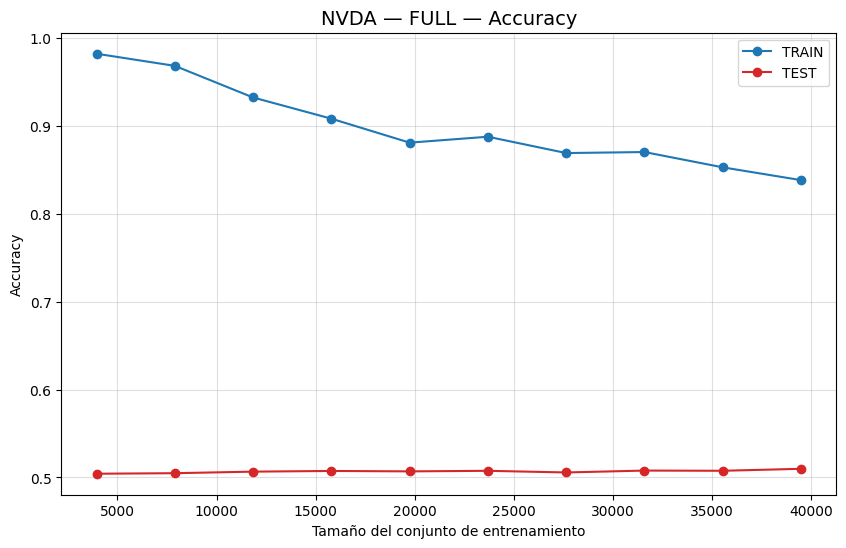

Generando curva de aprendizaje para NVDA - FULL (F1-score)


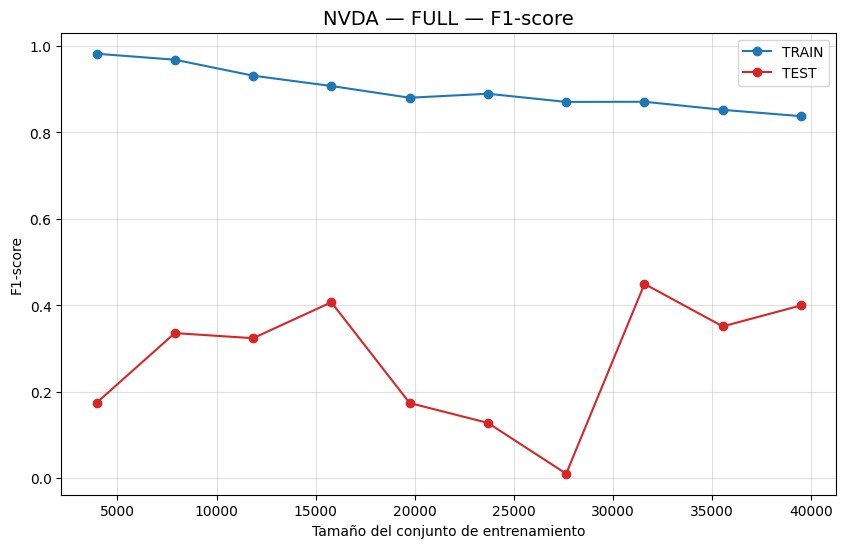

Generando curva de aprendizaje para NVDA - FULL (Precision)


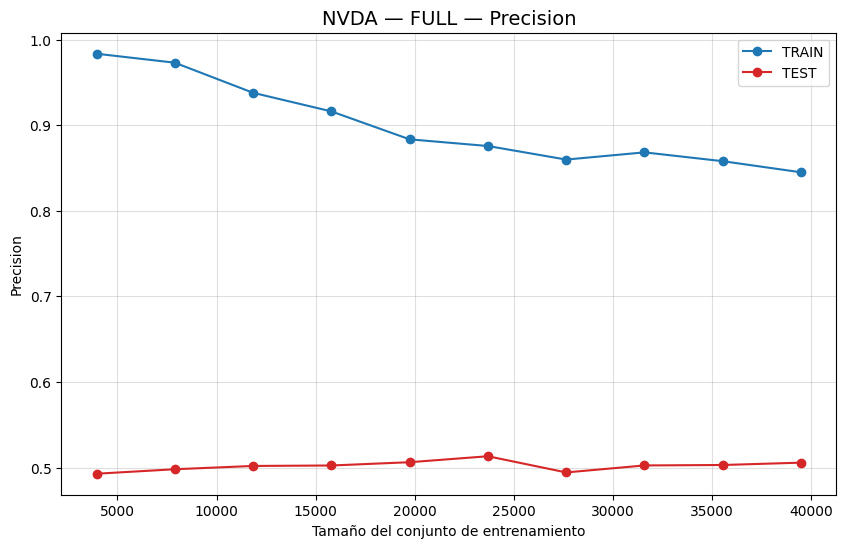

Generando curva de aprendizaje para NVDA - FULL (Recall)


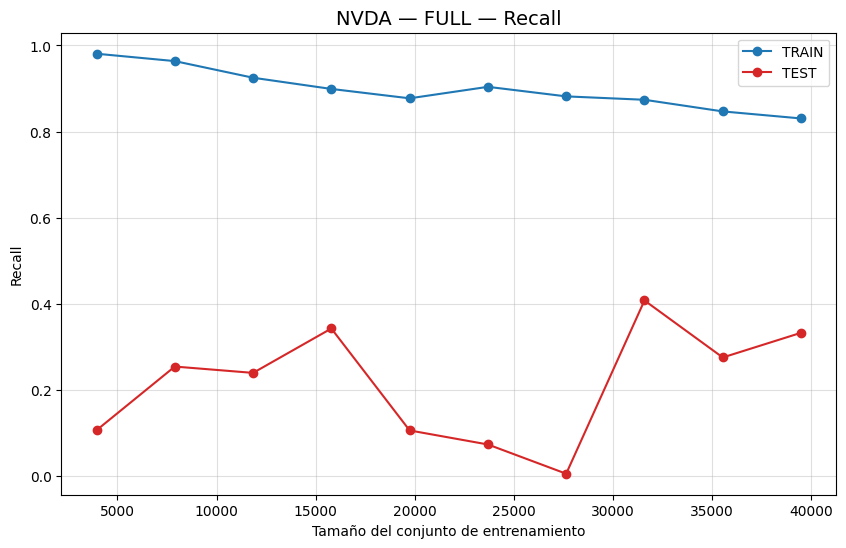

Generando curva de aprendizaje para NVDA - FSF (Accuracy)


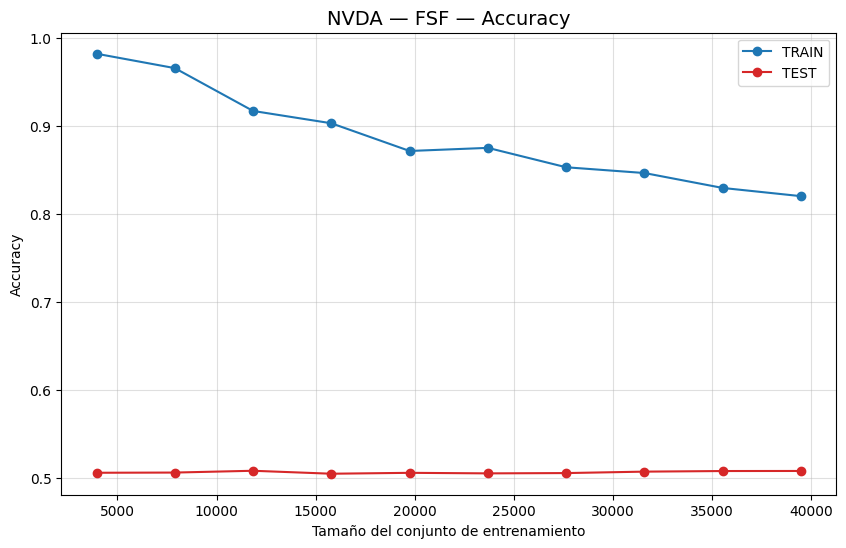

Generando curva de aprendizaje para NVDA - FSF (F1-score)


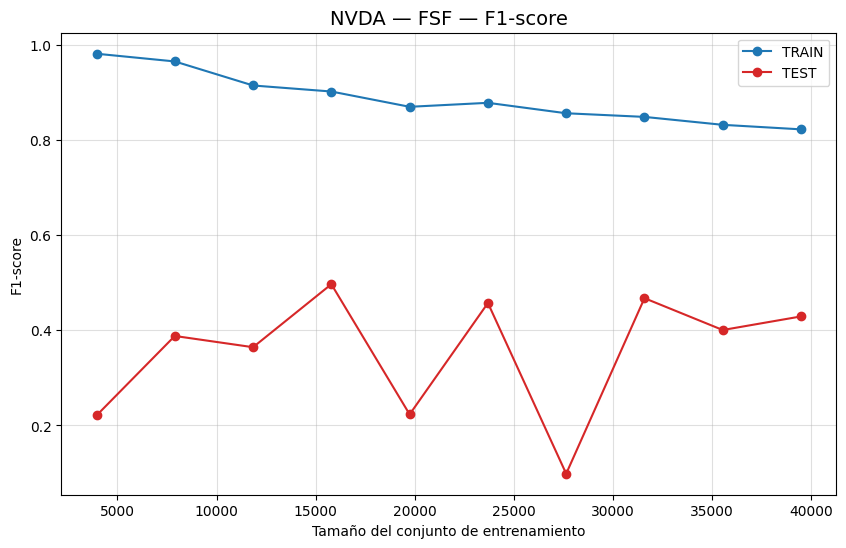

Generando curva de aprendizaje para NVDA - FSF (Precision)


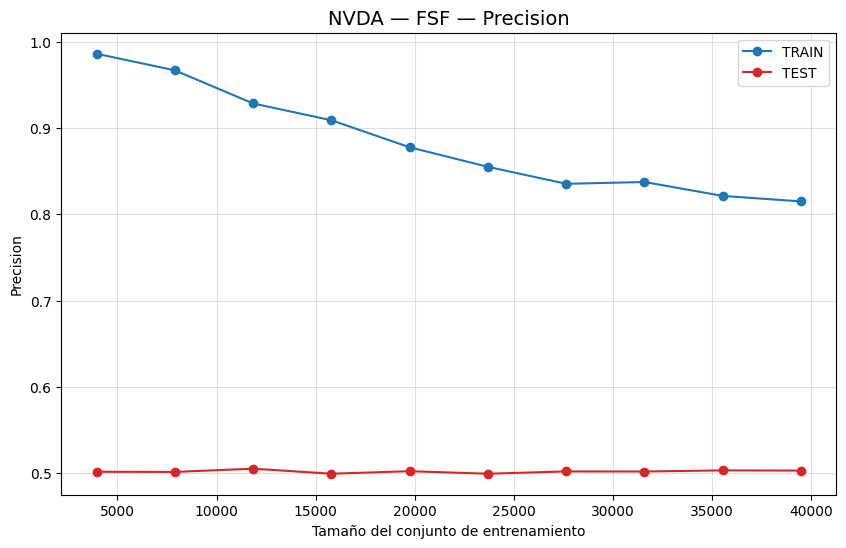

Generando curva de aprendizaje para NVDA - FSF (Recall)


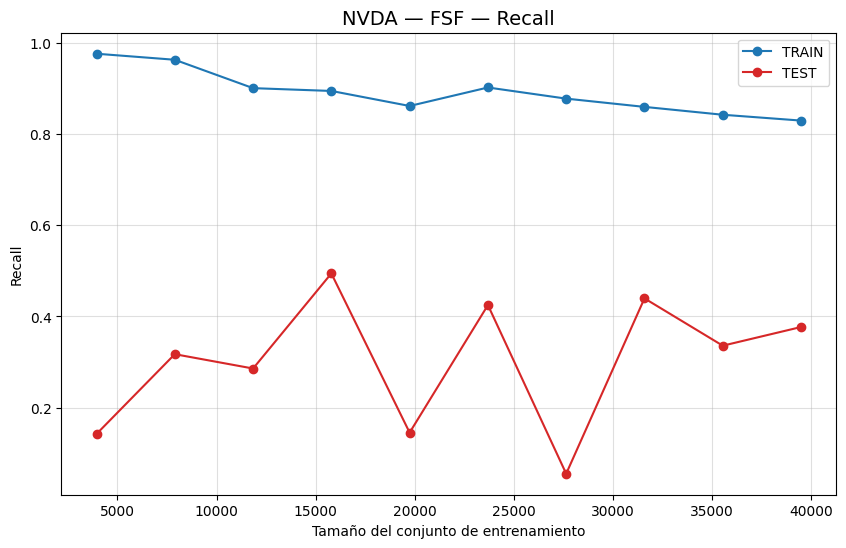


=== LEARNING CURVES MULTI-MÉTRICA PARA TSLA ===
Generando curva de aprendizaje para TSLA - FULL (Accuracy)


In [ ]:
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# === Definimos múltiples métricas ===
metricas = {
    "Accuracy": make_scorer(accuracy_score),
    "F1-score": make_scorer(f1_score),
    "Precision": make_scorer(precision_score),
    "Recall": make_scorer(recall_score)
}

# === Función extendida para learning curves ===
def plot_learning_curves_multi(model, scaler, X, y, sym, titulo):
    """
    Learning Curves con múltiples métricas para un activo y modelo específico.
    Usa validación temporal (TimeSeriesSplit).
    """

    tscv = TimeSeriesSplit(n_splits=5)
    train_sizes = np.linspace(0.1, 1.0, 10)

    for nombre_metrica, scorer in metricas.items():

        print(f"Generando curva de aprendizaje para {sym} - {titulo} ({nombre_metrica})")

        # learning_curve calcula TRAIN y TEST scores directamente
        train_sizes_, train_scores, test_scores = learning_curve(
            estimator=model,
            X=X,
            y=y,
            cv=tscv,
            train_sizes=train_sizes,
            scoring=scorer,
            shuffle=False,
            n_jobs=-1,
            exploit_incremental_learning=False
        )

        train_mean = train_scores.mean(axis=1)
        test_mean = test_scores.mean(axis=1)

        #Graficar...
        plt.figure(figsize=(10, 6))
        plt.plot(train_sizes_, train_mean, "o-", label="TRAIN", color="#1f77b4")
        plt.plot(train_sizes_, test_mean, "o-", label="TEST", color="#d62728")

        plt.title(f"{sym} — {titulo} — {nombre_metrica}", fontsize=14)
        plt.xlabel("Tamaño del conjunto de entrenamiento")
        plt.ylabel(nombre_metrica)
        plt.grid(True, alpha=0.4)
        plt.legend()
        plt.show()


# Ejecutar curvas de aprendizaje para todos los activos...
for sym in symbols:
    print(f"\n=== LEARNING CURVES MULTI-MÉTRICA PARA {sym} ===")

    # FULL
    full = joblib.load(f"models/{sym}_full.pkl")
    plot_learning_curves_multi(
        full["model"], full["scaler"],
        datasets[sym]["X_real"], datasets[sym]["y"],
        sym, titulo="FULL"
    )

    # FSF
    fsf = joblib.load(f"models/{sym}_fsf.pkl")
    plot_learning_curves_multi(
        fsf["model"], fsf["scaler"],
        fsf_by_symbol[sym], datasets[sym]["y"],
        sym, titulo="FSF"
    )


In [ ]:
papaya 

#### Bloque inicial que se trabajo para entrenamiendo de modelo, para los 3 activos agrupados. 
Para los 3 activos que tenemos, al ser activos de sectores y caracteristicas similares, esto puede tener sentido, pero se prefirio trabajar por activo separado, en caso de que escojamos realizar trading con activos de diferente naturaleza, sector o caracteristicas. 


In [ ]:
# Función para entrenar RandomForest + normalizar + graficar
def evaluate_window(test_days, X_real, X_full, y_full):
    print(f"\n\n TEST WINDOW: {test_days} días ....")
    
    last_day = X_full["date"].max()
    cutoff = last_day - pd.Timedelta(days=test_days)

    X_train = X_real[X_full["date"] < cutoff]
    y_train = y_full[X_full["date"] < cutoff]

    X_test = X_real[X_full["date"] >= cutoff]
    y_test = y_full[X_full["date"] >= cutoff]

    print("Train samples:", len(X_train))
    print("Test samples:", len(X_test))

    # Normalización
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modelo
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_scaled, y_train)

    # Importancia
    importances = pd.Series(
        rf.feature_importances_, index=X_train.columns
    ).sort_values(ascending=False)

    print("\nTop 15 features:")
    print(importances.head(15))

    # Gráfico
    #plt.figure(figsize=(9, 12))
    #importances.head(20).sort_values().plot(kind="barh")
    #plt.title(f"Top 20 Features – RF – Test Window {test_days} días")
    #plt.show()

    return importances




 TEST WINDOW: 5 días ....
Train samples: 705423
Test samples: 4332

Top 15 features:
transactions     0.051886
log_ret          0.049130
dollar_vol       0.047627
ret_1m           0.045261
dollar_vol_1m    0.044859
ret_3            0.042213
ret_1            0.042207
volume           0.038086
range_norm       0.037454
ret_5            0.033474
mean_vol_1m      0.032428
momentum_5       0.031021
momentum_10      0.029908
ret_mean         0.029332
vol_rolling_5    0.028444
dtype: float64


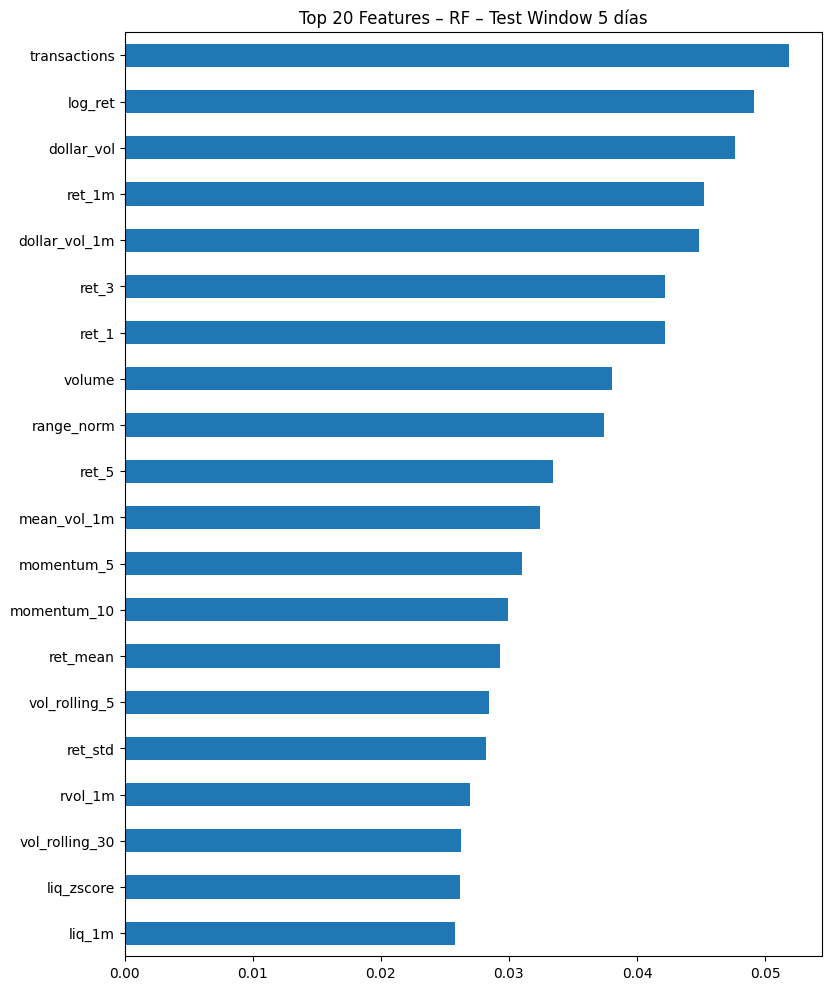



 TEST WINDOW: 10 días ....
Train samples: 701094
Test samples: 8661

Top 15 features:
transactions     0.056759
log_ret          0.049987
dollar_vol       0.046457
ret_1m           0.045582
dollar_vol_1m    0.044843
ret_1            0.041912
ret_3            0.041785
volume           0.040969
range_norm       0.037176
ret_5            0.032851
mean_vol_1m      0.031708
momentum_5       0.031552
momentum_10      0.029251
ret_mean         0.028661
ret_std          0.028261
dtype: float64


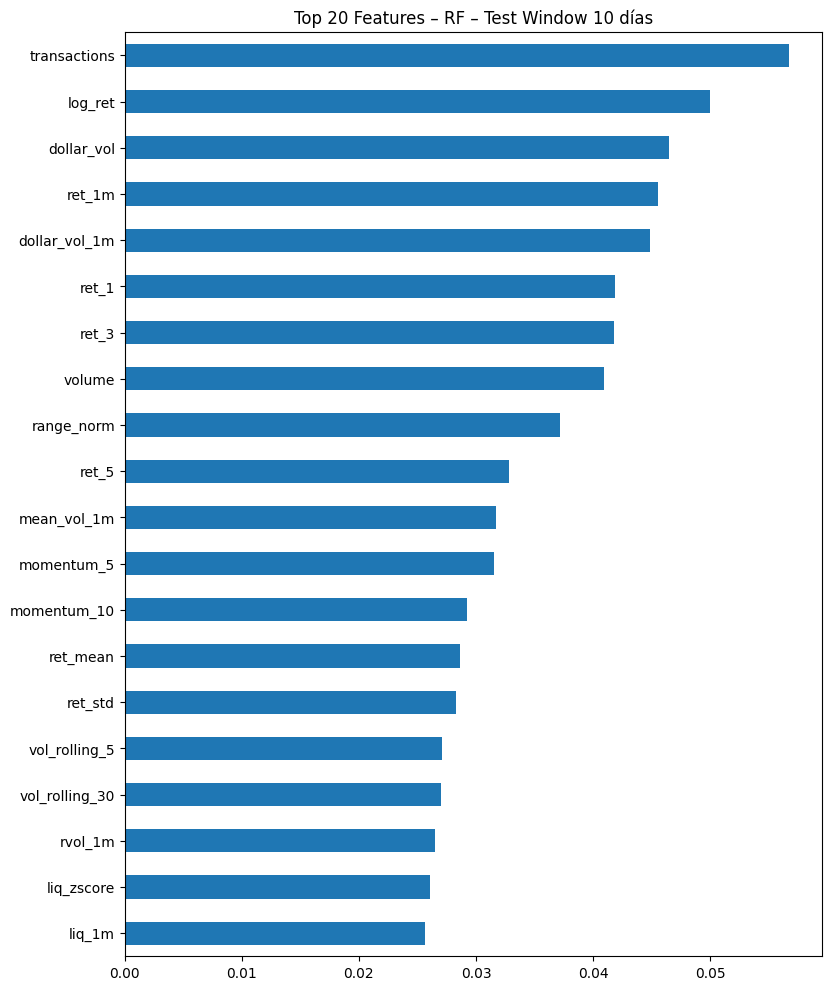



 TEST WINDOW: 15 días ....
Train samples: 695322
Test samples: 14433

Top 15 features:
transactions     0.054830
log_ret          0.049804
dollar_vol       0.046569
dollar_vol_1m    0.045204
ret_1m           0.044554
ret_1            0.042135
ret_3            0.041432
volume           0.039112
range_norm       0.037862
ret_5            0.033276
mean_vol_1m      0.031164
momentum_5       0.031080
momentum_10      0.031000
ret_mean         0.029022
ret_std          0.028285
dtype: float64


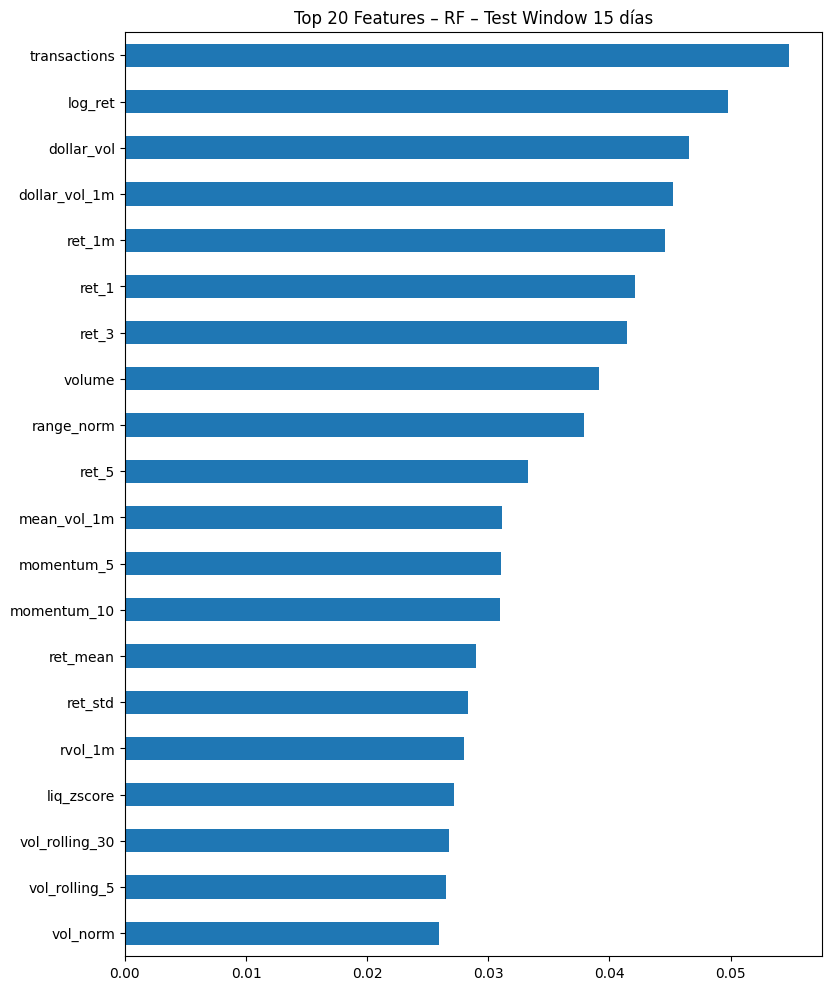

In [ ]:
results_5d = evaluate_window(5, X_real, X_1m, y_1m)
results_10d = evaluate_window(10, X_real, X_1m, y_1m)
results_15d = evaluate_window(15, X_real, X_1m, y_1m)



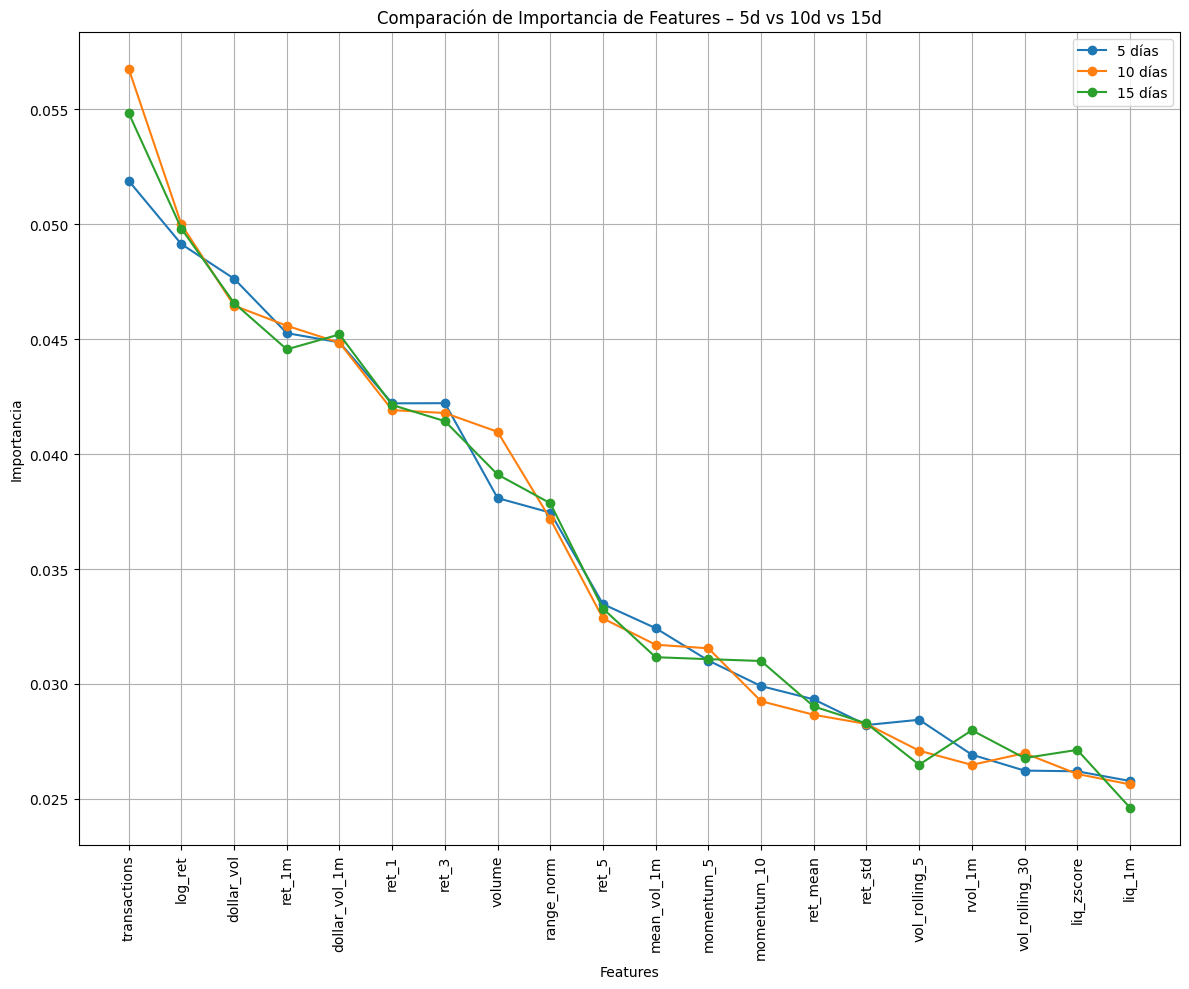

In [ ]:

# Unimos los resultados en un único DataFrame
df_compare = pd.DataFrame({
    "5 días": results_5d,
    "10 días": results_10d,
    "15 días": results_15d
})

# Reemplazar NaN por 0 (por si alguna feature no aparece en alguna ventana)
df_compare = df_compare.fillna(0)

# Ordenar por importancia promedio (para claridad visual)
df_compare["mean_importance"] = df_compare.mean(axis=1)
df_compare = df_compare.sort_values("mean_importance", ascending=False)

# Tomamos las top 20 para el gráfico
df_plot = df_compare.head(20).drop(columns=["mean_importance"])


# ---- Gráfico unificado ----
plt.figure(figsize=(12, 10))

for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col], marker="o", label=col)

plt.xticks(rotation=90)
plt.title("Comparación de Importancia de Features – 5d vs 10d vs 15d")
plt.ylabel("Importancia")
plt.xlabel("Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


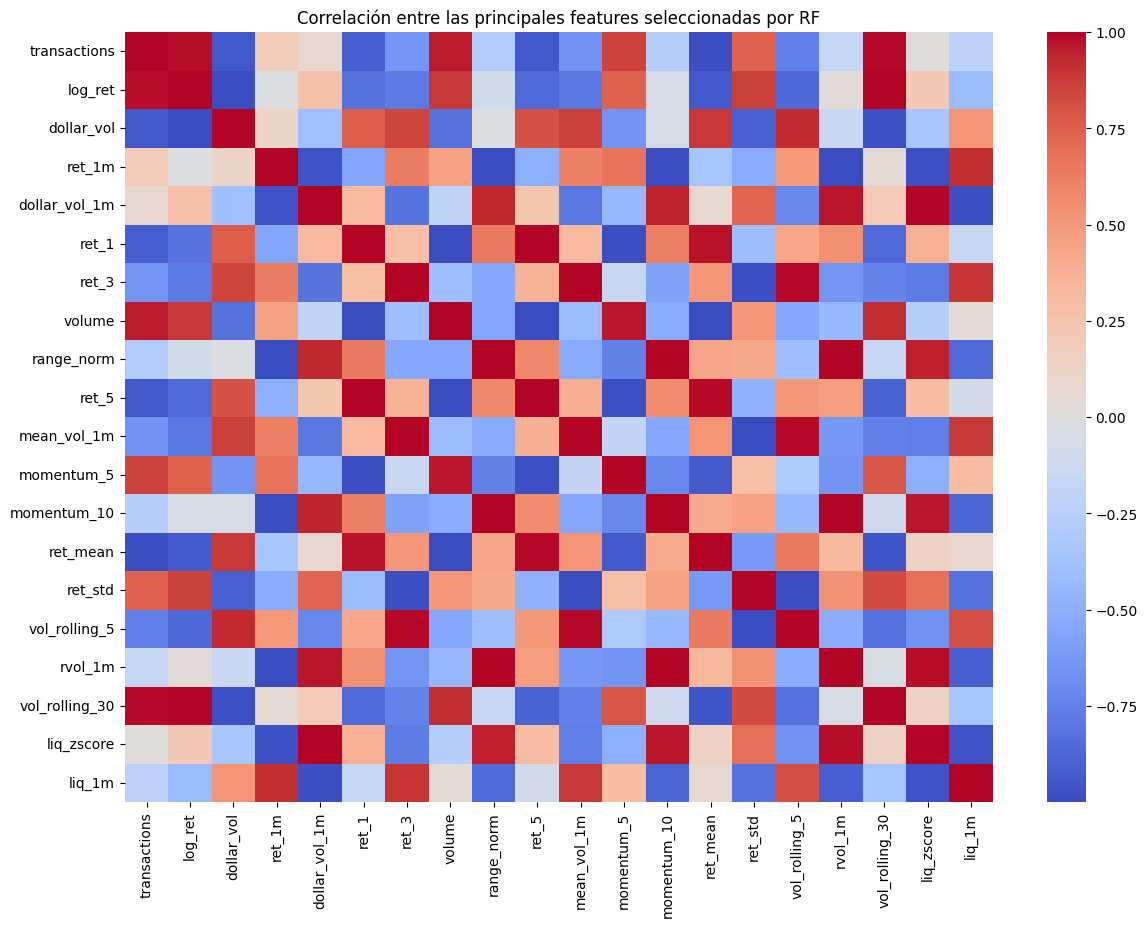

In [ ]:
import seaborn as sns
plt.figure(figsize=(14, 10))
sns.heatmap(df_plot.transpose().corr(), annot=False, cmap="coolwarm")
plt.title("Correlación entre las principales features seleccionadas por RF")
plt.show()


In [ ]:
corr_matrix = df_plot.transpose().corr()
high_corr = corr_matrix.abs()

np.where(high_corr > 0.80)


# Feature pairs con correlación excesiva
[(df_plot.index[i], df_plot.index[j]) 
 for i, j in zip(*np.where(high_corr > 0.80)) if i != j]



[('transactions', 'log_ret'),
 ('transactions', 'dollar_vol'),
 ('transactions', 'ret_1'),
 ('transactions', 'volume'),
 ('transactions', 'ret_5'),
 ('transactions', 'momentum_5'),
 ('transactions', 'ret_mean'),
 ('transactions', 'vol_rolling_30'),
 ('log_ret', 'transactions'),
 ('log_ret', 'dollar_vol'),
 ('log_ret', 'ret_1'),
 ('log_ret', 'volume'),
 ('log_ret', 'ret_5'),
 ('log_ret', 'ret_mean'),
 ('log_ret', 'ret_std'),
 ('log_ret', 'vol_rolling_5'),
 ('log_ret', 'vol_rolling_30'),
 ('dollar_vol', 'transactions'),
 ('dollar_vol', 'log_ret'),
 ('dollar_vol', 'ret_3'),
 ('dollar_vol', 'volume'),
 ('dollar_vol', 'mean_vol_1m'),
 ('dollar_vol', 'ret_mean'),
 ('dollar_vol', 'ret_std'),
 ('dollar_vol', 'vol_rolling_5'),
 ('dollar_vol', 'vol_rolling_30'),
 ('ret_1m', 'dollar_vol_1m'),
 ('ret_1m', 'range_norm'),
 ('ret_1m', 'momentum_10'),
 ('ret_1m', 'rvol_1m'),
 ('ret_1m', 'liq_zscore'),
 ('ret_1m', 'liq_1m'),
 ('dollar_vol_1m', 'ret_1m'),
 ('dollar_vol_1m', 'ret_3'),
 ('dollar_vol_1m', 

In [ ]:
#Preparamos la función de reducción automática de features
def reduce_correlated_features(X, importances, threshold=0.60):
    """
    Reduce features correlacionadas usando:
    - matriz de correlación
    - importancia de feature (RandomForest)
    - eliminación iterativa

    Devuelve:
    - features finales (DataFrame)
    - lista de features eliminadas
    - historial de eliminaciones
    """

    # Copia para trabajar
    X_work = X.copy()

    # Convertir importancias (Series) en diccionario
    imp_dict = importances.to_dict()

    eliminated = []
    history = []

    while True:
        # Correlación absoluta
        corr = X_work.corr().abs()

        # Se ponen a cero las diagonales
        np.fill_diagonal(corr.values, 0)

        # Buscar máximo valor de correlación
        max_corr = corr.max().max()

        # Si ya está por debajo del umbral -> terminar
        if max_corr < threshold:
            break

        # Identificar la pareja más correlacionada
        pair = np.where(corr == max_corr)
        i, j = pair[0][0], pair[1][0]

        f1 = X_work.columns[i]
        f2 = X_work.columns[j]

        # Mirar importancia (si no existe, poner 0)
        imp1 = imp_dict.get(f1, 0)
        imp2 = imp_dict.get(f2, 0)

        # Determinar cuál eliminar
        if imp1 >= imp2:
            keep = f1
            drop = f2
        else:
            keep = f2
            drop = f1

        # Registrar
        history.append((f1, f2, max_corr, keep, drop))
        eliminated.append(drop)

        # Eliminar la feature redundante
        X_work = X_work.drop(columns=[drop])

    return X_work, eliminated, history


In [ ]:
# Importancia promedio
avg_importances = (results_5d + results_10d + results_15d) / 3

# Ejecutar reducción automática
X_reduced, removed_features, removal_history = reduce_correlated_features(
    X_real, avg_importances, threshold=0.60
)

print("Total inicial de variables:", len(X_real.columns))
print("Total final de variables:", len(X_reduced.columns))
print("\nVariables eliminadas:\n", removed_features)
print("\nVariables finales:\n", X_reduced.columns.tolist())



Total inicial de variables: 37
Total final de variables: 18

Variables eliminadas:
 ['ret_1', 'dollar_vol_1m', 'momentum_5', 'high', 'low', 'open', 'vwap', 'liq_norm', 'ret_1m', 'vol_1m', 'dollar_vol', 'vol_rolling_30', 'range', 'mean_vol_1m', 'vol_mean', 'ret_5', 'vol_rolling_15', 'vol_norm', 'volume']

Variables finales:
 ['close', 'transactions', 'rvol_1m', 'vol_daily', 'ret_mean', 'ret_std', 'vol_std', 'liq_1m', 'log_ret', 'ret_3', 'momentum_10', 'range_norm', 'vol_rolling_5', 'liq_zscore', 'spike_lag_1', 'spike_lag_3', 'spike_density_10', 'spike_density_30']


In [ ]:
#Ver historial de correlaciones eliminadas

df_history = pd.DataFrame(removal_history,
                          columns=["feature_1", "feature_2", "correlation", "kept", "removed"])
df_history


,feature_1,feature_2,correlation,kept,removed
0,ret_1m,ret_1,1.000000,ret_1m,ret_1
1,dollar_vol_1m,dollar_vol,1.000000,dollar_vol,dollar_vol_1m
2,ret_5,momentum_5,1.000000,ret_5,momentum_5
3,high,close,0.999997,close,high
4,low,close,0.999996,close,low
5,open,close,0.999995,close,open
6,close,vwap,0.999992,close,vwap
7,vol_norm,liq_norm,0.999987,vol_norm,liq_norm
8,ret_1m,log_ret,0.999137,log_ret,ret_1m
9,vol_1m,vol_rolling_15,0.911709,vol_rolling_15,vol_1m
